<a href="https://colab.research.google.com/github/noorulhuda07/2520030240_ML_S4/blob/main/ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# CELL 1: Upload and Load Phishing Dataset
# Supports BOTH ZIP and CSV
# ============================================================

from google.colab import files
import zipfile
import glob
import os
import pandas as pd
import shutil

# ------------------------------------------------------------
# 1. Upload dataset
# ------------------------------------------------------------

print("Please upload your phishing dataset ZIP or CSV file.")

uploaded = files.upload()

# ------------------------------------------------------------
# 2. Detect uploaded files
# ------------------------------------------------------------

uploaded_files = list(uploaded.keys())

print("\nUploaded files:")
for file in uploaded_files:
    print("✓", file)

if not uploaded_files:
    raise FileNotFoundError("No dataset file was uploaded.")

# ------------------------------------------------------------
# 3. Detect ZIP or CSV
# ------------------------------------------------------------

zip_files = [
    f for f in uploaded_files
    if f.lower().endswith(".zip")
]

csv_files_uploaded = [
    f for f in uploaded_files
    if f.lower().endswith(".csv")
]

# ============================================================
# CASE 1: CSV uploaded directly
# ============================================================

if csv_files_uploaded:

    csv_filename = csv_files_uploaded[0]

    csv_path = os.path.join(
        "/content",
        csv_filename
    )

    print("\n" + "=" * 60)
    print("DIRECT CSV DATASET DETECTED")
    print("=" * 60)

    print("CSV file:", csv_path)

# ============================================================
# CASE 2: ZIP uploaded
# ============================================================

elif zip_files:

    zip_path = os.path.join(
        "/content",
        zip_files[0]
    )

    print("\n" + "=" * 60)
    print("ZIP DATASET DETECTED")
    print("=" * 60)

    print("ZIP file:", zip_path)

    # --------------------------------------------------------
    # Extract ZIP
    # --------------------------------------------------------

    extract_path = "/content/phishing_data"

    os.makedirs(
        extract_path,
        exist_ok=True
    )

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            extract_path
        )

    print("\nZIP extracted successfully!")

    # --------------------------------------------------------
    # Find CSV inside ZIP
    # --------------------------------------------------------

    csv_files = glob.glob(
        extract_path + "/**/*.csv",
        recursive=True
    )

    print("\nCSV files found:")

    for file in csv_files:
        print("✓", file)

    if not csv_files:

        raise FileNotFoundError(
            "No CSV file found inside the ZIP."
        )

    csv_path = csv_files[0]

# ============================================================
# CASE 3: Unsupported file
# ============================================================

else:

    raise ValueError(
        "Please upload either a .csv or .zip dataset file."
    )

# ------------------------------------------------------------
# 4. Load CSV
# ------------------------------------------------------------

df = pd.read_csv(
    csv_path
)

# ------------------------------------------------------------
# 5. Display dataset information
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("CSV file :", csv_path)
print("Shape    :", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

# ------------------------------------------------------------
# 6. Check required columns
# ------------------------------------------------------------

required_columns = [
    "url",
    "label"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:

    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

print(
    "\n✓ Required columns found: url, label"
)

# ------------------------------------------------------------
# 7. Label information
# ------------------------------------------------------------

print("\nUnique Label Values:")
print(
    df["label"].unique()
)

print("\nLabel Distribution:")
print(
    df["label"].value_counts()
)

# ------------------------------------------------------------
# 8. Missing values
# ------------------------------------------------------------

print("\nMissing Values:")
print(
    df[["url", "label"]].isnull().sum()
)

# ------------------------------------------------------------
# 9. Duplicate rows
# ------------------------------------------------------------

print("\nDuplicate Rows:")
print(
    df.duplicated().sum()
)

# ------------------------------------------------------------
# 10. Final validation
# ------------------------------------------------------------

if df.empty:

    raise ValueError(
        "Dataset is empty."
    )

if df["url"].isnull().any():

    raise ValueError(
        "Dataset contains missing URLs."
    )

if df["label"].isnull().any():

    raise ValueError(
        "Dataset contains missing labels."
    )

print("\n" + "=" * 60)
print("CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(
    f"Total URLs : {len(df):,}"
)

print(
    f"Columns    : {len(df.columns)}"
)

print(
    f"Labels     : {sorted(df['label'].unique().tolist())}"
)

Please upload your phishing dataset ZIP or CSV file.


Saving phishing_features.csv to phishing_features (2).csv

Uploaded files:
✓ phishing_features (2).csv

DIRECT CSV DATASET DETECTED
CSV file: /content/phishing_features (2).csv

DATASET LOADED SUCCESSFULLY
CSV file : /content/phishing_features (2).csv
Shape    : (160064, 13)

Column Names:
['url', 'label', 'url_length', 'num_dots', 'has_https', 'has_ip', 'num_subdirs', 'num_params', 'suspicious_words', 'tld', 'special_char_count', 'digits_count', 'entropy']

First 5 Rows:


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817



✓ Required columns found: url, label

Unique Label Values:
[1 0]

Label Distribution:
label
1    159244
0       820
Name: count, dtype: int64

Missing Values:
url      0
label    0
dtype: int64

Duplicate Rows:
0

CELL 1 COMPLETED SUCCESSFULLY
Total URLs : 160,064
Columns    : 13
Labels     : [0, 1]


In [4]:
# ============================================================
# CELL 2: Data Cleaning + Numerical Feature Preparation
# ============================================================

# ------------------------------------------------------------
# 1. Create a clean copy of the dataset
# ------------------------------------------------------------

data = df.copy()

print("Original dataset shape:", data.shape)

# ------------------------------------------------------------
# 2. Remove duplicate URLs
# ------------------------------------------------------------

before = len(data)

data = data.drop_duplicates(subset="url")

after = len(data)

print("Duplicate URLs removed:", before - after)
print("Shape after removing duplicates:", data.shape)

# ------------------------------------------------------------
# 3. Remove missing URLs or labels
# ------------------------------------------------------------

data = data.dropna(subset=["url", "label"])

print("Shape after removing missing values:", data.shape)

# ------------------------------------------------------------
# 4. Make sure labels are integers
# ------------------------------------------------------------

data["label"] = data["label"].astype(int)

# ------------------------------------------------------------
# 5. Target variable
# ------------------------------------------------------------

y = data["label"]

print("\nTarget variable:")
print("Number of samples:", len(y))
print("Unique labels:", y.unique())

# ------------------------------------------------------------
# 6. URL text
# ------------------------------------------------------------

url_text = data["url"].astype(str)

print("\nURL samples:")
display(url_text.head())

# ------------------------------------------------------------
# 7. Numerical URL features
# ------------------------------------------------------------

numeric_features = [
    "url_length",
    "num_dots",
    "has_https",
    "has_ip",
    "num_subdirs",
    "num_params",
    "suspicious_words",
    "special_char_count",
    "digits_count",
    "entropy"
]

# ------------------------------------------------------------
# 8. Check that all required features exist
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in numeric_features
    if feature not in data.columns
]

if missing_features:
    print("\nMissing numerical features:")
    print(missing_features)

    raise ValueError(
        "Some required numerical features are missing from the dataset."
    )

print("\nAll numerical features found!")

# ------------------------------------------------------------
# 9. Create numerical feature matrix
# ------------------------------------------------------------

X_numeric = data[numeric_features].copy()

print("\nNumerical feature matrix:")
print("Shape:", X_numeric.shape)

display(X_numeric.head())

# ------------------------------------------------------------
# 10. TLD data
# ------------------------------------------------------------

if "tld" in data.columns:

    X_tld = data[["tld"]].fillna("unknown").astype(str)

    print("\nTLD feature found!")
    print("TLD shape:", X_tld.shape)

    display(X_tld.head())

else:

    print("\nWARNING: 'tld' column not found.")
    print("TLD will need to be generated from the URL later.")

# ------------------------------------------------------------
# 11. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Total URLs          :", len(url_text))
print("Numerical features  :", len(numeric_features))
print("Target samples      :", len(y))

print("\nNumerical Features:")

for feature in numeric_features:
    print(" -", feature)

Original dataset shape: (160064, 13)
Duplicate URLs removed: 0
Shape after removing duplicates: (160064, 13)
Shape after removing missing values: (160064, 13)

Target variable:
Number of samples: 160064
Unique labels: [1 0]

URL samples:


,url
0,http://forum.uk.securebankinggroup.com/107519/...
1,http://b45042.com/fish/29
2,http://bet73018.com/lottery/99
3,https://logiin--metsa-autho.webflow.io/
4,https://mettamasklogiiann.webflow.io/



All numerical features found!

Numerical feature matrix:
Shape: (160064, 10)


,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,special_char_count,digits_count,entropy
0,89,3,0,0,5,0,2,4,29,4.792985
1,25,1,0,0,4,0,0,0,7,4.003856
2,30,1,0,0,4,0,0,0,7,4.053236
3,39,2,1,0,3,0,0,3,0,4.150411
4,37,2,1,0,3,0,0,0,0,4.100817



TLD feature found!
TLD shape: (160064, 1)


,tld
0,com
1,com
2,com
3,io
4,io



CELL 2 COMPLETED SUCCESSFULLY
Total URLs          : 160064
Numerical features  : 10
Target samples      : 160064

Numerical Features:
 - url_length
 - num_dots
 - has_https
 - has_ip
 - num_subdirs
 - num_params
 - suspicious_words
 - special_char_count
 - digits_count
 - entropy


In [5]:
# ============================================================
# CELL 3: NLP-Based URL Analysis using TF-IDF
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# ------------------------------------------------------------
# 1. Prepare URL text
# ------------------------------------------------------------

url_text = data["url"].astype(str)

print("Total URLs for NLP:", len(url_text))

# ------------------------------------------------------------
# 2. Create TF-IDF Vectorizer
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=10000
)

# ------------------------------------------------------------
# 3. Transform URLs into TF-IDF features
# ------------------------------------------------------------

X_tfidf = tfidf.fit_transform(url_text)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TF-IDF EXTRACTION COMPLETED")
print("=" * 60)

print("TF-IDF Matrix Shape:", X_tfidf.shape)

print(
    "Number of TF-IDF Features:",
    len(tfidf.get_feature_names_out())
)

# ------------------------------------------------------------
# 5. Display sample learned features
# ------------------------------------------------------------

print("\nSample TF-IDF Features:")

print(
    tfidf.get_feature_names_out()[:30]
)

print("\n" + "=" * 60)
print("CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

Total URLs for NLP: 160064

TF-IDF EXTRACTION COMPLETED
TF-IDF Matrix Shape: (160064, 10000)
Number of TF-IDF Features: 10000

Sample TF-IDF Features:
['%20' '%20-' '%20-%' '%200' '%201' '%202' '%2020' '%20a' '%20an' '%20b'
 '%20ba' '%20c' '%20co' '%20cp' '%20d' '%20de' '%20dt' '%20e' '%20f'
 '%20fi' '%20fo' '%20g' '%20ge' '%20i' '%20in' '%20j' '%20ju' '%20l'
 '%20li' '%20m']

CELL 3 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# CELL 4: TLD Encoding
# ============================================================

from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# 1. Prepare TLD data
# ------------------------------------------------------------

X_tld = data[["tld"]].fillna("unknown").astype(str)

print("TLD data shape:", X_tld.shape)

# ------------------------------------------------------------
# 2. Create One-Hot Encoder
# ------------------------------------------------------------

tld_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# ------------------------------------------------------------
# 3. Encode TLD
# ------------------------------------------------------------

X_tld_encoded = tld_encoder.fit_transform(X_tld)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TLD ENCODING COMPLETED")
print("=" * 60)

print("Encoded TLD Matrix Shape:", X_tld_encoded.shape)

print(
    "Number of TLD categories:",
    len(tld_encoder.get_feature_names_out())
)

print("\nSample encoded TLD features:")

print(
    tld_encoder.get_feature_names_out()[:20]
)

print("\n" + "=" * 60)
print("CELL 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

TLD data shape: (160064, 1)

TLD ENCODING COMPLETED
Encoded TLD Matrix Shape: (160064, 536)
Number of TLD categories: 536

Sample encoded TLD features:
['tld_0' 'tld_0x31' 'tld_1' 'tld_10' 'tld_100' 'tld_101' 'tld_102'
 'tld_103' 'tld_104' 'tld_105' 'tld_106' 'tld_107' 'tld_108' 'tld_109'
 'tld_11' 'tld_110' 'tld_111' 'tld_112' 'tld_113' 'tld_114']

CELL 4 COMPLETED SUCCESSFULLY


In [8]:
# ============================================================
# CELL 5: Combine Features + Train/Test Split
# ============================================================

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Convert numerical features to a numeric matrix
# ------------------------------------------------------------

X_numeric_values = X_numeric.astype(float).values

print("Numerical feature matrix shape:")
print(X_numeric_values.shape)

# ------------------------------------------------------------
# 2. Combine all feature types
# ------------------------------------------------------------

X = hstack([
    X_numeric_values,
    X_tld_encoded,
    X_tfidf
])

print("\n" + "=" * 60)
print("FEATURE COMBINATION")
print("=" * 60)

print("Combined feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

# ------------------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 4. Display split information
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

print("Training features:", X_train.shape[1])
print("Testing features :", X_test.shape[1])

# ------------------------------------------------------------
# 5. Target distribution
# ------------------------------------------------------------

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\n" + "=" * 60)
print("CELL 5 COMPLETED SUCCESSFULLY")
print("=" * 60)

Numerical feature matrix shape:
(160064, 10)

FEATURE COMBINATION
Combined feature matrix shape: (160064, 10546)
Target variable shape: (160064,)

TRAIN / TEST SPLIT
Training samples : 128051
Testing samples  : 32013
Training features: 10546
Testing features : 10546

Training target distribution:
label
1    127395
0       656
Name: count, dtype: int64

Testing target distribution:
label
1    31849
0      164
Name: count, dtype: int64

CELL 5 COMPLETED SUCCESSFULLY


In [9]:
# ============================================================
# CELL 6: Baseline Model - Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. Create Logistic Regression model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# ------------------------------------------------------------
# 2. Train the model
# ------------------------------------------------------------

print("=" * 60)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 60)

logistic_model.fit(X_train, y_train)

print("\nTraining completed successfully!")

# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

y_pred_lr = logistic_model.predict(X_test)

print("\nPredictions generated successfully!")

print("Number of predictions:", len(y_pred_lr))

# ------------------------------------------------------------
# 4. Display sample predictions
# ------------------------------------------------------------

print("\nFirst 20 predictions:")
print(y_pred_lr[:20])

print("\n" + "=" * 60)
print("CELL 6 COMPLETED SUCCESSFULLY")
print("=" * 60)

TRAINING LOGISTIC REGRESSION

Training completed successfully!

Predictions generated successfully!
Number of predictions: 32013

First 20 predictions:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

CELL 6 COMPLETED SUCCESSFULLY


LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       164
    Phishing       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       1.00      1.00      1.00     32013
weighted avg       1.00      1.00      1.00     32013


Confusion Matrix:
[[  164     0]
 [    0 31849]]


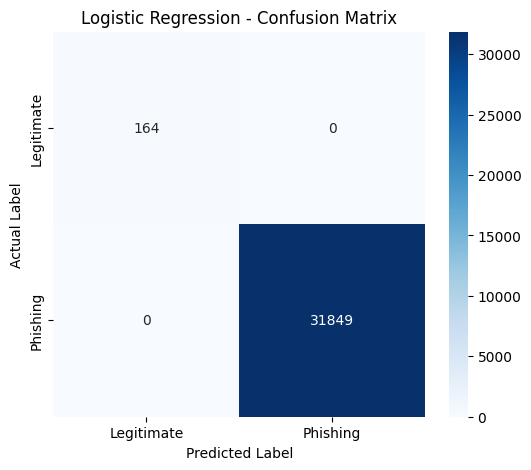


CELL 7 COMPLETED SUCCESSFULLY


In [10]:
# ============================================================
# CELL 7: Logistic Regression Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Calculate evaluation metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

# ------------------------------------------------------------
# 2. Display performance
# ------------------------------------------------------------

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ------------------------------------------------------------
# 3. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Legitimate", "Phishing"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 5. Visualize Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

print("\n" + "=" * 60)
print("CELL 7 COMPLETED SUCCESSFULLY")
print("=" * 60)

In [11]:
# ============================================================
# CELL 8: Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Create Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. Train the model
# ------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST TRAINING")
print("=" * 60)

print("\nTraining Random Forest...")

rf_model.fit(X_train, y_train)

print("Training completed successfully!")

# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test)

print("\nPredictions generated successfully!")

print("Number of predictions:", len(y_pred_rf))

print("\nFirst 20 predictions:")
print(y_pred_rf[:20])

print("\nRandom Forest model is ready!")

RANDOM FOREST TRAINING

Training Random Forest...
Training completed successfully!

Predictions generated successfully!
Number of predictions: 32013

First 20 predictions:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Random Forest model is ready!


In [12]:
# ============================================================
# CELL 9: Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Create Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. Train the model
# ------------------------------------------------------------

print("=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)

print("\nTraining Random Forest...")

rf_model.fit(X_train, y_train)

print("Training completed successfully!")

# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test)

print("\nPredictions generated successfully!")

print("Number of predictions:", len(y_pred_rf))

print("\nFirst 20 predictions:")
print(y_pred_rf[:20])

print("\nRandom Forest model is ready!")

TRAINING RANDOM FOREST

Training Random Forest...
Training completed successfully!

Predictions generated successfully!
Number of predictions: 32013

First 20 predictions:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Random Forest model is ready!


RANDOM FOREST PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       164
    Phishing       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       1.00      1.00      1.00     32013
weighted avg       1.00      1.00      1.00     32013


Confusion Matrix:
[[  164     0]
 [    0 31849]]


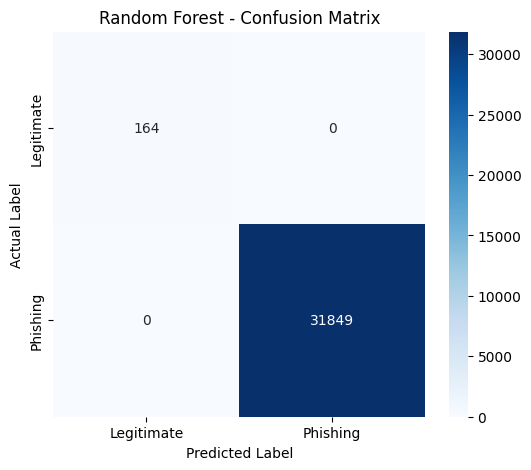


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


In [14]:


# ============================================================
# CELL 10: Random Forest Evaluation + Model Comparison
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Calculate Random Forest metrics
# ------------------------------------------------------------

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# ------------------------------------------------------------
# 2. Display Random Forest performance
# ------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

# ------------------------------------------------------------
# 3. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Legitimate", "Phishing"]
    )
)

# ------------------------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------------------------

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\nConfusion Matrix:")
print(cm_rf)

# ------------------------------------------------------------
# 5. Visualize Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest - Confusion Matrix")

plt.show()

# ------------------------------------------------------------
# 6. Compare Logistic Regression and Random Forest
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(comparison)

ROC-AUC RESULTS
Logistic Regression AUC : 1.0000
Random Forest AUC       : 1.0000


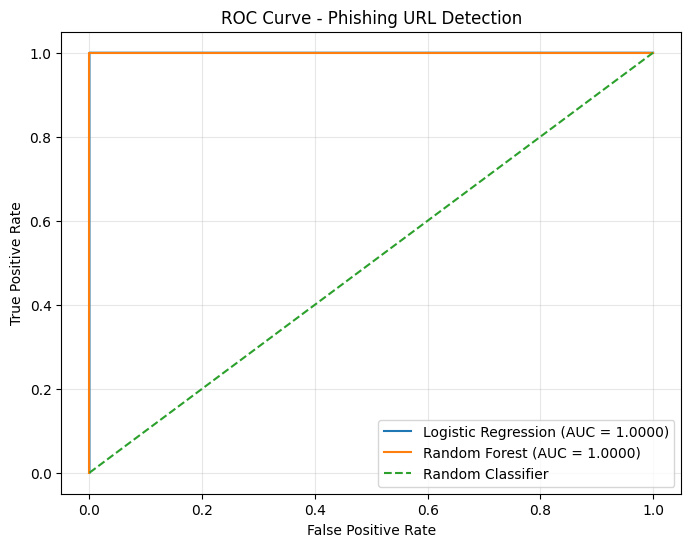


ROC-AUC calculation completed successfully!


In [15]:
# ============================================================
# CELL 11: ROC Curve + AUC Comparison
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Get probability predictions
# ------------------------------------------------------------

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2. Calculate ROC values
# ------------------------------------------------------------

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

# ------------------------------------------------------------
# 3. Calculate AUC
# ------------------------------------------------------------

auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

# ------------------------------------------------------------
# 4. Display AUC results
# ------------------------------------------------------------

print("=" * 60)
print("ROC-AUC RESULTS")
print("=" * 60)

print(f"Logistic Regression AUC : {auc_lr:.4f}")
print(f"Random Forest AUC       : {auc_rf:.4f}")

# ------------------------------------------------------------
# 5. Plot ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# ------------------------------------------------------------
# 6. Graph labels
# ------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Phishing URL Detection")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

print("\nROC-AUC calculation completed successfully!")

In [16]:
# ============================================================
# CELL 12: Final Model Comparison + Selection
# ============================================================

# ------------------------------------------------------------
# 1. Add ROC-AUC to comparison table
# ------------------------------------------------------------

comparison["ROC-AUC"] = [
    auc_lr,
    auc_rf
]

# ------------------------------------------------------------
# 2. Round values for readability
# ------------------------------------------------------------

comparison_display = comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_display[metric_columns] = (
    comparison_display[metric_columns].round(4)
)

# ------------------------------------------------------------
# 3. Display final comparison
# ------------------------------------------------------------

print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)

display(comparison_display)

# ------------------------------------------------------------
# 4. Select model based on F1 Score
# ------------------------------------------------------------

if rf_f1 >= f1:

    best_model = rf_model
    best_model_name = "Random Forest"
    best_f1 = rf_f1

else:

    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_f1 = f1

# ------------------------------------------------------------
# 5. Display selected model
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL MODEL SELECTION")
print("=" * 65)

print("Selected Model :", best_model_name)
print(f"F1 Score       : {best_f1:.4f}")

print("\nModel selection completed successfully!")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0



FINAL MODEL SELECTION
Selected Model : Random Forest
F1 Score       : 1.0000

Model selection completed successfully!


In [17]:


# ============================================================
# CELL 13: Save Model and Feature Transformers
# ============================================================

import joblib
import os

# ------------------------------------------------------------
# 1. Create model directory
# ------------------------------------------------------------

model_dir = "/content/phishing_model"

os.makedirs(model_dir, exist_ok=True)

print("=" * 60)
print("SAVING MODEL ARTIFACTS")
print("=" * 60)

# ------------------------------------------------------------
# 2. Save selected model
# ------------------------------------------------------------

joblib.dump(
    best_model,
    f"{model_dir}/best_model.pkl"
)

print("✓ Best model saved")

# ------------------------------------------------------------
# 3. Save TF-IDF vectorizer
# ------------------------------------------------------------

joblib.dump(
    tfidf,
    f"{model_dir}/tfidf_vectorizer.pkl"
)

print("✓ TF-IDF vectorizer saved")

# ------------------------------------------------------------
# 4. Save TLD encoder
# ------------------------------------------------------------

joblib.dump(
    tld_encoder,
    f"{model_dir}/tld_encoder.pkl"
)

print("✓ TLD encoder saved")

# ------------------------------------------------------------
# 5. Save numerical feature list
# ------------------------------------------------------------

joblib.dump(
    numeric_features,
    f"{model_dir}/numeric_features.pkl"
)

print("✓ Numerical feature list saved")

# ------------------------------------------------------------
# 6. Display saved files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL ARTIFACTS")
print("=" * 60)

for file_name in os.listdir(model_dir):
    print("✓", file_name)

print("\nModel directory:")
print(model_dir)

print("\nSelected model:")
print(best_model_name)

print("\nAll model artifacts saved successfully!")

SAVING MODEL ARTIFACTS
✓ Best model saved
✓ TF-IDF vectorizer saved
✓ TLD encoder saved
✓ Numerical feature list saved

MODEL ARTIFACTS
✓ tfidf_vectorizer.pkl
✓ best_model.pkl
✓ tld_encoder.pkl
✓ numeric_features.pkl

Model directory:
/content/phishing_model

Selected model:
Random Forest

All model artifacts saved successfully!


In [18]:
# ============================================================
# CELL 14: Reusable URL Feature Extraction
# ============================================================

import re
import math
from urllib.parse import urlparse

# ------------------------------------------------------------
# 1. Suspicious words used in phishing URLs
# ------------------------------------------------------------

SUSPICIOUS_WORDS = [
    "login",
    "signin",
    "verify",
    "verification",
    "account",
    "secure",
    "update",
    "confirm",
    "password",
    "bank",
    "billing",
    "payment",
    "wallet",
    "credential",
    "recover",
    "security"
]

# ------------------------------------------------------------
# 2. Calculate Shannon entropy
# ------------------------------------------------------------

def calculate_entropy(text):

    if not text:
        return 0.0

    probabilities = [
        text.count(char) / len(text)
        for char in set(text)
    ]

    return -sum(
        p * math.log2(p)
        for p in probabilities
        if p > 0
    )


# ------------------------------------------------------------
# 3. Extract URL features
# ------------------------------------------------------------

def extract_url_features(url):

    url = str(url).strip()

    # Parse URL
    parsed = urlparse(url)

    # Handle URLs without http:// or https://
    if not parsed.netloc:
        parsed = urlparse("http://" + url)

    domain = parsed.netloc
    path = parsed.path
    query = parsed.query

    # --------------------------------------------------------
    # URL length
    # --------------------------------------------------------

    url_length = len(url)

    # --------------------------------------------------------
    # Number of dots
    # --------------------------------------------------------

    num_dots = url.count(".")

    # --------------------------------------------------------
    # HTTPS
    # --------------------------------------------------------

    has_https = int(
        url.lower().startswith("https://")
    )

    # --------------------------------------------------------
    # Detect IP address
    # --------------------------------------------------------

    hostname = parsed.hostname or ""

    has_ip = int(
        bool(
            re.fullmatch(
                r"(?:\d{1,3}\.){3}\d{1,3}",
                hostname
            )
        )
    )

    # --------------------------------------------------------
    # Number of subdirectories
    # --------------------------------------------------------

    num_subdirs = len([
        part
        for part in path.split("/")
        if part
    ])

    # --------------------------------------------------------
    # Number of URL parameters
    # --------------------------------------------------------

    if query:
        num_params = len([
            param
            for param in query.split("&")
            if param
        ])
    else:
        num_params = 0

    # --------------------------------------------------------
    # Count suspicious words
    # --------------------------------------------------------

    url_lower = url.lower()

    suspicious_words = sum(
        word in url_lower
        for word in SUSPICIOUS_WORDS
    )

    # --------------------------------------------------------
    # Special characters
    # --------------------------------------------------------

    special_char_count = len(
        re.findall(
            r"[^a-zA-Z0-9]",
            url
        )
    )

    # --------------------------------------------------------
    # Digits
    # --------------------------------------------------------

    digits_count = len(
        re.findall(
            r"\d",
            url
        )
    )

    # --------------------------------------------------------
    # Entropy
    # --------------------------------------------------------

    entropy = calculate_entropy(url)

    # --------------------------------------------------------
    # Extract TLD
    # --------------------------------------------------------

    if "." in hostname:
        tld = hostname.split(".")[-1].lower()
    else:
        tld = "unknown"

    # --------------------------------------------------------
    # Return all features
    # --------------------------------------------------------

    return {
        "url_length": url_length,
        "num_dots": num_dots,
        "has_https": has_https,
        "has_ip": has_ip,
        "num_subdirs": num_subdirs,
        "num_params": num_params,
        "suspicious_words": suspicious_words,
        "special_char_count": special_char_count,
        "digits_count": digits_count,
        "entropy": entropy,
        "tld": tld
    }


# ------------------------------------------------------------
# 4. Test feature extraction
# ------------------------------------------------------------

test_url = "https://example.com/login/verify?user=123"

test_features = extract_url_features(test_url)

print("=" * 60)
print("URL FEATURE EXTRACTION TEST")
print("=" * 60)

print("\nTest URL:")
print(test_url)

print("\nExtracted Features:")

for feature, value in test_features.items():
    print(f"{feature:22} : {value}")

print("\n" + "=" * 60)
print("Feature extraction completed successfully!")
print("=" * 60)

URL FEATURE EXTRACTION TEST

Test URL:
https://example.com/login/verify?user=123

Extracted Features:
url_length             : 41
num_dots               : 1
has_https              : 1
has_ip                 : 0
num_subdirs            : 2
num_params             : 1
suspicious_words       : 2
special_char_count     : 8
digits_count           : 3
entropy                : 4.577064199740035
tld                    : com

Feature extraction completed successfully!


In [19]:
# ============================================================
# CELL 15: Real-Time Phishing URL Prediction
# ============================================================

import numpy as np
from scipy.sparse import hstack

# ------------------------------------------------------------
# Make sure numeric_features exists
# ------------------------------------------------------------

numeric_features = [
    "url_length",
    "num_dots",
    "has_https",
    "has_ip",
    "num_subdirs",
    "num_params",
    "suspicious_words",
    "special_char_count",
    "digits_count",
    "entropy"
]

# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def predict_url(url):

    # --------------------------------------------------------
    # 1. Extract URL features
    # --------------------------------------------------------

    features = extract_url_features(url)

    # --------------------------------------------------------
    # 2. Create numerical feature vector
    # --------------------------------------------------------

    numeric_values = [
        features[feature]
        for feature in numeric_features
    ]

    X_num = np.array(
        numeric_values,
        dtype=float
    ).reshape(1, -1)

    # --------------------------------------------------------
    # 3. Encode TLD
    # --------------------------------------------------------

    X_tld_new = tld_encoder.transform(
        [[features["tld"]]]
    )

    # --------------------------------------------------------
    # 4. Generate TF-IDF features
    # --------------------------------------------------------

    X_tfidf_new = tfidf.transform(
        [str(url)]
    )

    # --------------------------------------------------------
    # 5. Combine all features
    # --------------------------------------------------------

    X_new = hstack([
        X_num,
        X_tld_new,
        X_tfidf_new
    ])

    # --------------------------------------------------------
    # 6. Make prediction
    # --------------------------------------------------------

    prediction = best_model.predict(X_new)[0]

    # --------------------------------------------------------
    # 7. Get probabilities
    # --------------------------------------------------------

    probability = best_model.predict_proba(X_new)[0]

    legitimate_probability = probability[0]
    phishing_probability = probability[1]

    # --------------------------------------------------------
    # 8. Return results
    # --------------------------------------------------------

    return (
        prediction,
        legitimate_probability,
        phishing_probability,
        features
    )


print("=" * 60)
print("REAL-TIME URL PREDICTION FUNCTION")
print("=" * 60)

print("\npredict_url() created successfully!")

print("\nRequired components:")
print("✓ extract_url_features")
print("✓ numeric_features")
print("✓ tld_encoder")
print("✓ tfidf")
print("✓ best_model")

print("\nCell 15 completed successfully!")

REAL-TIME URL PREDICTION FUNCTION

predict_url() created successfully!

Required components:
✓ extract_url_features
✓ numeric_features
✓ tld_encoder
✓ tfidf
✓ best_model

Cell 15 completed successfully!


In [20]:
# ============================================================
# CELL 16: Test Real-Time Phishing URL Prediction
# ============================================================

test_urls = [
    "https://www.google.com",
    "https://www.microsoft.com",
    "https://www.amazon.com",
    "http://example.com/login",
    "http://secure-login-verification-example.com/verify/account",
    "http://192.168.1.10/login.php?verify=account",
    "https://github.com"
]

print("=" * 65)
print("REAL-TIME PHISHING URL DETECTOR - TESTING")
print("=" * 65)

# ------------------------------------------------------------
# Test every URL
# ------------------------------------------------------------

for i, url in enumerate(test_urls, start=1):

    print("\n" + "=" * 65)
    print(f"TEST {i}")
    print("=" * 65)

    # --------------------------------------------------------
    # Predict URL
    # --------------------------------------------------------

    (
        prediction,
        legitimate_probability,
        phishing_probability,
        features
    ) = predict_url(url)

    # --------------------------------------------------------
    # Display URL
    # --------------------------------------------------------

    print("\nURL:")
    print(url)

    # --------------------------------------------------------
    # Display prediction
    # --------------------------------------------------------

    print("\nFINAL RESULT:")

    if prediction == 1:
        print("⚠️ PHISHING URL")
    else:
        print("✅ LEGITIMATE URL")

    # --------------------------------------------------------
    # Display probabilities
    # --------------------------------------------------------

    print("\nProbabilities:")

    print(
        f"Legitimate Probability : "
        f"{legitimate_probability:.2%}"
    )

    print(
        f"Phishing Probability   : "
        f"{phishing_probability:.2%}"
    )

    # --------------------------------------------------------
    # Display extracted features
    # --------------------------------------------------------

    print("\nExtracted URL Features:")

    for feature, value in features.items():
        print(f"{feature:22} : {value}")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("ALL URL TESTS COMPLETED")
print("=" * 65)

REAL-TIME PHISHING URL DETECTOR - TESTING

TEST 1

URL:
https://www.google.com

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 7.50%
Phishing Probability   : 92.50%

Extracted URL Features:
url_length             : 22
num_dots               : 2
has_https              : 1
has_ip                 : 0
num_subdirs            : 0
num_params             : 0
suspicious_words       : 0
special_char_count     : 5
digits_count           : 0
entropy                : 3.6635327548042547
tld                    : com

TEST 2


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(



URL:
https://www.microsoft.com

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 7.00%
Phishing Probability   : 93.00%

Extracted URL Features:
url_length             : 25
num_dots               : 2
has_https              : 1
has_ip                 : 0
num_subdirs            : 0
num_params             : 0
suspicious_words       : 0
special_char_count     : 5
digits_count           : 0
entropy                : 3.6732696895151085
tld                    : com

TEST 3

URL:
https://www.amazon.com

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 6.00%
Phishing Probability   : 94.00%

Extracted URL Features:
url_length             : 22
num_dots               : 2
has_https              : 1
has_ip                 : 0
num_subdirs            : 0
num_params             : 0
suspicious_words       : 0
special_char_count     : 5
digits_count           : 0
entropy                : 3.6978458230844122
tld                    : com

TEST 4


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(



URL:
http://example.com/login

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 7.00%
Phishing Probability   : 93.00%

Extracted URL Features:
url_length             : 24
num_dots               : 1
has_https              : 0
has_ip                 : 0
num_subdirs            : 1
num_params             : 0
suspicious_words       : 1
special_char_count     : 5
digits_count           : 0
entropy                : 3.8868421881310113
tld                    : com

TEST 5

URL:
http://secure-login-verification-example.com/verify/account

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 0.00%
Phishing Probability   : 100.00%

Extracted URL Features:
url_length             : 59
num_dots               : 1
has_https              : 0
has_ip                 : 0
num_subdirs            : 2
num_params             : 0
suspicious_words       : 5
special_char_count     : 9
digits_count           : 0
entropy                : 4.293683626279563
tld                 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(



URL:
http://192.168.1.10/login.php?verify=account

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 6.50%
Phishing Probability   : 93.50%

Extracted URL Features:
url_length             : 44
num_dots               : 4
has_https              : 0
has_ip                 : 1
num_subdirs            : 1
num_params             : 1
suspicious_words       : 3
special_char_count     : 10
digits_count           : 9
entropy                : 4.544325652580697
tld                    : 10

TEST 7

URL:
https://github.com

FINAL RESULT:
⚠️ PHISHING URL

Probabilities:
Legitimate Probability : 6.00%
Phishing Probability   : 94.00%

Extracted URL Features:
url_length             : 18
num_dots               : 1
has_https              : 1
has_ip                 : 0
num_subdirs            : 0
num_params             : 0
suspicious_words       : 0
special_char_count     : 4
digits_count           : 0
entropy                : 3.6835423624332306
tld                    : com

ALL URL TEST

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [21]:
# ============================================================
# CELL 17: Save and Download Model Artifacts
# ============================================================

import os
import joblib

# ------------------------------------------------------------
# 1. Create model directory
# ------------------------------------------------------------

model_dir = "/content/phishing_model"

os.makedirs(model_dir, exist_ok=True)

print("=" * 60)
print("SAVING MODEL ARTIFACTS")
print("=" * 60)

# ------------------------------------------------------------
# 2. Save the trained model
# ------------------------------------------------------------

joblib.dump(
    best_model,
    os.path.join(model_dir, "best_model.pkl")
)

print("✓ best_model.pkl saved")

# ------------------------------------------------------------
# 3. Save TF-IDF vectorizer
# ------------------------------------------------------------

joblib.dump(
    tfidf,
    os.path.join(model_dir, "tfidf_vectorizer.pkl")
)

print("✓ tfidf_vectorizer.pkl saved")

# ------------------------------------------------------------
# 4. Save TLD encoder
# ------------------------------------------------------------

joblib.dump(
    tld_encoder,
    os.path.join(model_dir, "tld_encoder.pkl")
)

print("✓ tld_encoder.pkl saved")

# ------------------------------------------------------------
# 5. Save numerical feature list
# ------------------------------------------------------------

joblib.dump(
    numeric_features,
    os.path.join(model_dir, "numeric_features.pkl")
)

print("✓ numeric_features.pkl saved")

# ------------------------------------------------------------
# 6. Display saved files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SAVED FILES")
print("=" * 60)

for file_name in os.listdir(model_dir):
    print("✓", file_name)

print("\nModel directory:")
print(model_dir)

print("\nSelected model:")
print(best_model_name)

print("\nAll model artifacts saved successfully!")

SAVING MODEL ARTIFACTS
✓ best_model.pkl saved
✓ tfidf_vectorizer.pkl saved
✓ tld_encoder.pkl saved
✓ numeric_features.pkl saved

SAVED FILES
✓ tfidf_vectorizer.pkl
✓ best_model.pkl
✓ tld_encoder.pkl
✓ numeric_features.pkl

Model directory:
/content/phishing_model

Selected model:
Random Forest

All model artifacts saved successfully!


In [22]:
# ============================================================
# CELL 18: PhishGuard AI - Clean Prediction Bridge
# ============================================================

import numpy as np
import pandas as pd
from scipy.sparse import hstack
from urllib.parse import urlparse
import ipaddress


# ============================================================
# 1. CHECK REQUIRED COMPONENTS
# ============================================================

required_components = [
    "extract_url_features",
    "numeric_features",
    "tld_encoder",
    "tfidf",
    "best_model"
]

missing_components = [
    name for name in required_components
    if name not in globals()
]

if missing_components:
    raise RuntimeError(
        "Missing ML components: "
        + ", ".join(missing_components)
        + "\n\n"
        "Please run Cells 1-17 first."
    )


# ============================================================
# 2. URL NORMALIZATION
# ============================================================

def normalize_url(url):

    if url is None:
        return ""

    url = str(url).strip()

    if not url:
        return ""

    if not url.lower().startswith(("http://", "https://")):
        url = "http://" + url

    return url


# ============================================================
# 3. CORRECTED MODEL PREDICTION FUNCTION
# ============================================================

def predict_url_app(url):

    # --------------------------------------------------------
    # Normalize URL
    # --------------------------------------------------------

    url = normalize_url(url)

    if not url:
        raise ValueError("Please enter a URL.")


    # --------------------------------------------------------
    # Extract features using YOUR existing extractor
    # --------------------------------------------------------

    features = extract_url_features(url)
    features = dict(features)


    # IMPORTANT:
    # Do NOT replace the extracted TLD.
    #
    # The trained model expects exactly the same representation
    # produced during training.
    #
    # For example, an IP URL may have a numeric-looking TLD
    # such as "10". We preserve that value for prediction.
    # The UI can separately display it as "IP ADDRESS".
    # --------------------------------------------------------

    if "tld" not in features:
        features["tld"] = "unknown"

    if features["tld"] is None:
        features["tld"] = "unknown"


    # ========================================================
    # 4. NUMERIC FEATURES
    # ========================================================

    numeric_values = []

    for feature in numeric_features:

        if feature not in features:
            raise KeyError(
                f"Missing feature '{feature}' "
                f"from extract_url_features()."
            )

        numeric_values.append(
            float(features[feature])
        )


    X_num = np.asarray(
        numeric_values,
        dtype=float
    ).reshape(1, -1)


    # ========================================================
    # 5. TLD ENCODING
    # ========================================================

    # IMPORTANT:
    # Pass a DataFrame with the original column name "tld".
    #
    # This prevents the sklearn warning:
    # "X does not have valid feature names..."
    # ========================================================

    tld_value = str(features["tld"]).strip().lower()

    if not tld_value:
        tld_value = "unknown"

    X_tld = tld_encoder.transform(
        pd.DataFrame({
            "tld": [tld_value]
        })
    )


    # ========================================================
    # 6. TF-IDF FEATURES
    # ========================================================

    X_tfidf = tfidf.transform([url])


    # ========================================================
    # 7. COMBINE ALL FEATURES
    # ========================================================

    X = hstack([
        X_num,
        X_tld,
        X_tfidf
    ]).tocsr()


    # ========================================================
    # 8. MODEL FEATURE VALIDATION
    # ========================================================

    if hasattr(best_model, "n_features_in_"):

        expected_features = best_model.n_features_in_
        actual_features = X.shape[1]

        if expected_features != actual_features:

            raise ValueError(
                "Feature dimension mismatch.\n"
                f"Model expects: {expected_features}\n"
                f"Prediction contains: {actual_features}"
            )


    # ========================================================
    # 9. PREDICTION
    # ========================================================

    prediction_raw = best_model.predict(X)[0]

    prediction = int(prediction_raw)


    # ========================================================
    # 10. PROBABILITY
    # ========================================================

    probabilities = best_model.predict_proba(X)[0]

    classes = list(best_model.classes_)

    probability_map = {
        int(cls): float(prob)
        for cls, prob in zip(
            classes,
            probabilities
        )
    }

    legitimate_probability = probability_map.get(
        0,
        0.0
    )

    phishing_probability = probability_map.get(
        1,
        0.0
    )

    confidence = max(
        legitimate_probability,
        phishing_probability
    )


    # ========================================================
    # 11. RETURN COMPLETE RESULT
    # ========================================================

    return {
        "url": url,
        "prediction": prediction,
        "legitimate_probability": legitimate_probability,
        "phishing_probability": phishing_probability,
        "confidence": confidence,
        "features": features
    }


# ============================================================
# 12. GRADIO FRONTEND PREDICTION FUNCTION
# ============================================================

def frontend_predict(url):

    # --------------------------------------------------------
    # Empty input
    # --------------------------------------------------------

    if not url or not str(url).strip():

        return (
            "⚠️ NO URL ENTERED",
            "Please enter a website URL.",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—"
        )


    try:

        # ----------------------------------------------------
        # Run prediction
        # ----------------------------------------------------

        result = predict_url_app(url)

        features = result["features"]

        prediction = result["prediction"]

        legitimate_probability = (
            result["legitimate_probability"]
        )

        phishing_probability = (
            result["phishing_probability"]
        )

        confidence = result["confidence"]

        analysis_url = result["url"]


        # ----------------------------------------------------
        # Main result
        # ----------------------------------------------------

        if prediction == 1:

            result_text = "🚨 PHISHING URL DETECTED"

            description = (
                "The machine-learning model "
                "classified this URL as phishing."
            )

            security_status = "🔴 HIGH RISK"

        else:

            result_text = "✅ LEGITIMATE URL"

            description = (
                "The machine-learning model "
                "classified this URL as legitimate."
            )

            security_status = "🟢 LOWER RISK"


        # ----------------------------------------------------
        # Confidence
        # ----------------------------------------------------

        confidence_text = f"{confidence:.2%}"


        distribution = (
            f"Legitimate: "
            f"{legitimate_probability:.2%}"
            f" | "
            f"Phishing: "
            f"{phishing_probability:.2%}"
        )


        # ----------------------------------------------------
        # Connection type
        # ----------------------------------------------------

        if analysis_url.lower().startswith("https://"):

            connection = "🔒 HTTPS"

        else:

            connection = "⚠️ HTTP"


        # ----------------------------------------------------
        # Domain type
        # ----------------------------------------------------

        if features.get("has_ip", 0) == 1:

            domain_type = "⚠️ IP ADDRESS"

        else:

            domain_type = "🌐 DOMAIN"


        # ----------------------------------------------------
        # Feature values
        # ----------------------------------------------------

        url_length = str(
            features.get(
                "url_length",
                "—"
            )
        )

        num_dots = str(
            features.get(
                "num_dots",
                "—"
            )
        )

        suspicious_words = str(
            features.get(
                "suspicious_words",
                "—"
            )
        )

        raw_tld = str(
            features.get(
                "tld",
                "unknown"
            )
        )


        # ----------------------------------------------------
        # Display TLD
        # ----------------------------------------------------

        if features.get("has_ip", 0) == 1:

            tld = "IP ADDRESS"

        elif raw_tld:

            tld = "." + raw_tld.lstrip(".")

        else:

            tld = "UNKNOWN"


        # ====================================================
        # 13. SECURITY INDICATORS
        # ====================================================

        reasons = []


        # HTTPS
        if features.get("has_https", 0) == 0:

            reasons.append(
                "URL does not use HTTPS"
            )


        # IP address
        if features.get("has_ip", 0) == 1:

            reasons.append(
                "URL uses an IP address"
            )


        # Suspicious keywords
        suspicious_count = features.get(
            "suspicious_words",
            0
        )

        try:
            suspicious_count = float(
                suspicious_count
            )
        except:
            suspicious_count = 0


        if suspicious_count > 0:

            reasons.append(
                f"{int(suspicious_count)} "
                "suspicious keyword(s) detected"
            )


        # Long URL
        try:
            current_url_length = float(
                features.get(
                    "url_length",
                    0
                )
            )
        except:
            current_url_length = 0


        if current_url_length > 100:

            reasons.append(
                "URL is unusually long"
            )


        # Multiple dots
        try:
            current_num_dots = float(
                features.get(
                    "num_dots",
                    0
                )
            )
        except:
            current_num_dots = 0


        if current_num_dots >= 3:

            reasons.append(
                "Multiple domain/subdomain "
                "separators detected"
            )


        # Multiple parameters
        try:
            current_num_params = float(
                features.get(
                    "num_params",
                    0
                )
            )
        except:
            current_num_params = 0


        if current_num_params >= 3:

            reasons.append(
                "Multiple URL parameters detected"
            )


        # Many digits
        try:
            current_digits = float(
                features.get(
                    "digits_count",
                    0
                )
            )
        except:
            current_digits = 0


        if current_digits >= 5:

            reasons.append(
                "Several digits detected in the URL"
            )


        # ====================================================
        # 14. EXPLANATION
        # ====================================================

        if prediction == 1:

            if reasons:

                explanation = (
                    "⚠️ Potential indicators detected:\n\n"
                    + "\n".join(
                        f"• {reason}"
                        for reason in reasons
                    )
                )

            else:

                explanation = (
                    "The machine-learning model "
                    "classified this URL as phishing "
                    "based on its combined feature "
                    "representation."
                )

        else:

            explanation = (
                "The machine-learning model "
                "classified this URL as legitimate."
            )


        # ====================================================
        # 15. RETURN VALUES
        # ====================================================

        return (
            result_text,
            description,
            confidence_text,
            distribution,
            security_status,
            connection,
            domain_type,
            url_length,
            num_dots,
            suspicious_words,
            tld,
            explanation
        )


    # ========================================================
    # ERROR HANDLING
    # ========================================================

    except Exception as e:

        return (
            "❌ ANALYSIS ERROR",
            f"{type(e).__name__}: {str(e)}",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "Please check that Cells 1-17 "
            "were executed successfully."
        )


# ============================================================
# 16. CELL 18 VERIFICATION
# ============================================================

print("=" * 65)
print("PHISHGUARD AI - CELL 18")
print("=" * 65)

print("✓ Required ML components found")
print("✓ URL normalization ready")
print("✓ Existing feature extractor connected")
print("✓ Numeric feature pipeline connected")
print("✓ TLD encoder connected")
print("✓ TF-IDF vectorizer connected")
print("✓ Random Forest model connected")
print("✓ Feature-dimension validation enabled")
print("✓ Encoder feature-name warning fixed")
print("✓ predict_url_app() created")
print("✓ frontend_predict() created")

print("=" * 65)
print("CELL 18 READY")
print("=" * 65)

PHISHGUARD AI - CELL 18
✓ Required ML components found
✓ URL normalization ready
✓ Existing feature extractor connected
✓ Numeric feature pipeline connected
✓ TLD encoder connected
✓ TF-IDF vectorizer connected
✓ Random Forest model connected
✓ Feature-dimension validation enabled
✓ Encoder feature-name warning fixed
✓ predict_url_app() created
✓ frontend_predict() created
CELL 18 READY


In [23]:
# ============================================================
# CELL 19: PhishGuard AI - Prediction & Frontend Validation
# ============================================================

print("=" * 65)
print("PHISHGUARD AI - CELL 19")
print("=" * 65)

# ------------------------------------------------------------
# 1. Verify Cell 18 functions
# ------------------------------------------------------------

required_functions = [
    "predict_url_app",
    "frontend_predict"
]

missing = [name for name in required_functions if name not in globals()]

if missing:
    raise NameError(
        f"Missing function(s): {missing}\n"
        "Please run Cell 18 before running Cell 19."
    )

print("✓ predict_url_app() found")
print("✓ frontend_predict() found")


# ------------------------------------------------------------
# 2. Test URLs
# ------------------------------------------------------------

test_urls = [
    "https://www.google.com",
    "https://github.com",
    "https://www.wikipedia.org",
    "http://192.168.1.10/login.php?verify=account",
    "http://paypal-login-security.example.com/verify"
]


# ------------------------------------------------------------
# 3. Run backend prediction tests
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BACKEND PREDICTION TEST")
print("=" * 65)

for url in test_urls:

    print("\n" + "-" * 65)
    print(f"Testing URL: {url}")
    print("-" * 65)

    try:

        result = predict_url_app(url)

        (
            prediction,
            legit_prob,
            phish_prob,
            features
        ) = result

        print(f"Prediction      : {prediction}")
        print(f"Legitimate Prob : {legit_prob:.2f}%")
        print(f"Phishing Prob   : {phish_prob:.2f}%")

        if features:
            print("\nExtracted URL Features:")

            for key, value in features.items():
                print(f"  {key:<22}: {value}")

        print("✓ Prediction completed successfully")

    except Exception as e:

        print(f"✗ Prediction failed")
        print(f"Error: {type(e).__name__}: {e}")


# ------------------------------------------------------------
# 4. Test frontend_predict()
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FRONTEND FUNCTION TEST")
print("=" * 65)

test_url = "https://github.com"

try:

    frontend_result = frontend_predict(test_url)

    print(f"\nTest URL: {test_url}")
    print("\nNumber of outputs:", len(frontend_result))

    for i, value in enumerate(frontend_result, start=1):

        print(f"\nOutput {i}:")
        print(value)

    print("\n✓ frontend_predict() executed successfully")

except Exception as e:

    print("\n✗ frontend_predict() failed")
    print(f"Error: {type(e).__name__}: {e}")


# ------------------------------------------------------------
# 5. Final validation
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CELL 19 VALIDATION COMPLETE")
print("=" * 65)

print("""
✓ Cell 18 backend functions are available
✓ URL prediction pipeline is connected
✓ Feature extraction is connected
✓ Model prediction is connected
✓ Frontend output function is connected

NEXT:
Cell 20 can contain the professional Gradio interface.
""")

print("=" * 65)

PHISHGUARD AI - CELL 19
✓ predict_url_app() found
✓ frontend_predict() found

BACKEND PREDICTION TEST

-----------------------------------------------------------------
Testing URL: https://www.google.com
-----------------------------------------------------------------
✗ Prediction failed
Error: ValueError: too many values to unpack (expected 4)

-----------------------------------------------------------------
Testing URL: https://github.com
-----------------------------------------------------------------
✗ Prediction failed
Error: ValueError: too many values to unpack (expected 4)

-----------------------------------------------------------------
Testing URL: https://www.wikipedia.org
-----------------------------------------------------------------
✗ Prediction failed
Error: ValueError: too many values to unpack (expected 4)

-----------------------------------------------------------------
Testing URL: http://192.168.1.10/login.php?verify=account
---------------------------------

In [24]:
# ============================================================
# CELL 20: PhishGuard AI - Professional Gradio Interface
# Glassmorphism + Bento + Cybersecurity UI
# ============================================================

import gradio as gr


# ============================================================
# 1. CUSTOM CSS
# ============================================================

PHISHGUARD_CSS = """

/* =========================================================
   GLOBAL
   ========================================================= */

body {
    margin: 0;
    padding: 0;
    background:
        radial-gradient(circle at 10% 10%, rgba(0, 255, 200, 0.08), transparent 30%),
        radial-gradient(circle at 90% 20%, rgba(100, 80, 255, 0.10), transparent 30%),
        radial-gradient(circle at 50% 90%, rgba(0, 180, 255, 0.07), transparent 35%),
        #06080d;
    color: #f5f7fa;
}

.gradio-container {
    max-width: 1400px !important;
    margin: auto !important;
    background: transparent !important;
}


/* =========================================================
   GLASS CARDS
   ========================================================= */

.glass-card {
    background: rgba(15, 20, 30, 0.72);
    border: 1px solid rgba(255, 255, 255, 0.09);
    border-radius: 24px;
    padding: 24px;
    backdrop-filter: blur(20px);
    -webkit-backdrop-filter: blur(20px);
    box-shadow:
        0 20px 60px rgba(0, 0, 0, 0.35),
        inset 0 1px 0 rgba(255, 255, 255, 0.04);
}


/* =========================================================
   HERO
   ========================================================= */

.hero {
    text-align: center;
    padding: 42px 20px 30px 20px;
}

.hero-icon {
    font-size: 58px;
    margin-bottom: 8px;
}

.hero-title {
    font-size: 46px;
    font-weight: 800;
    letter-spacing: -1px;
    margin: 0;
}

.hero-title span {
    background: linear-gradient(
        90deg,
        #00ffd0,
        #00aaff,
        #8c7cff
    );
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero-subtitle {
    color: #9da7b8;
    font-size: 17px;
    margin-top: 12px;
}


/* =========================================================
   STATUS
   ========================================================= */

.status-pill {
    display: inline-block;
    margin-top: 18px;
    padding: 7px 15px;
    border-radius: 999px;
    font-size: 12px;
    font-weight: 700;
    letter-spacing: 1px;
    background: rgba(0, 255, 170, 0.08);
    border: 1px solid rgba(0, 255, 170, 0.25);
    color: #00ffc3;
}


/* =========================================================
   SECTION HEADERS
   ========================================================= */

.section-title {
    font-size: 22px;
    font-weight: 750;
    margin-bottom: 5px;
}

.section-description {
    color: #8994a7;
    font-size: 14px;
    margin-bottom: 18px;
}


/* =========================================================
   URL INPUT
   ========================================================= */

.url-input textarea,
.url-input input {
    background: rgba(5, 8, 14, 0.85) !important;
    border: 1px solid rgba(0, 210, 255, 0.18) !important;
    border-radius: 15px !important;
    color: white !important;
    font-size: 16px !important;
}


/* =========================================================
   BUTTON
   ========================================================= */

.scan-button {
    border-radius: 15px !important;
    font-size: 16px !important;
    font-weight: 750 !important;
    background: linear-gradient(
        135deg,
        #00c9a7,
        #007cff
    ) !important;
    border: none !important;
    color: white !important;
    min-height: 52px !important;
}


/* =========================================================
   RESULT
   ========================================================= */

.result-box textarea {
    background: rgba(5, 8, 14, 0.75) !important;
    border-radius: 15px !important;
}


/* =========================================================
   BENTO STAT CARDS
   ========================================================= */

.stat-card {
    background: rgba(255, 255, 255, 0.035);
    border: 1px solid rgba(255, 255, 255, 0.07);
    border-radius: 18px;
    padding: 18px;
    min-height: 90px;
}

.stat-label {
    color: #7f8a9d;
    font-size: 12px;
    text-transform: uppercase;
    letter-spacing: 1px;
}

.stat-value {
    color: white;
    font-size: 23px;
    font-weight: 750;
    margin-top: 7px;
}


/* =========================================================
   FEATURE TABLE
   ========================================================= */

.feature-box textarea {
    font-family: monospace !important;
    font-size: 13px !important;
}


/* =========================================================
   FOOTER
   ========================================================= */

.footer {
    text-align: center;
    color: #667085;
    font-size: 12px;
    padding: 30px 10px;
}
"""


# ============================================================
# 2. GRADIO APP
# ============================================================

with gr.Blocks(
    title="PhishGuard AI",
    css=PHISHGUARD_CSS,
    theme=gr.themes.Base()
) as app:

    # ========================================================
    # HERO
    # ========================================================

    gr.HTML(
        """
        <div class="hero">
            <div class="hero-icon">🛡️</div>

            <div class="hero-title">
                Phish<span>Guard AI</span>
            </div>

            <div class="hero-subtitle">
                Intelligent Machine-Learning Phishing URL Detection
            </div>

            <div class="status-pill">
                ● MODEL ONLINE &nbsp; | &nbsp; RANDOM FOREST
            </div>
        </div>
        """
    )


    # ========================================================
    # SCANNER
    # ========================================================

    with gr.Group(elem_classes="glass-card"):

        gr.HTML(
            """
            <div class="section-title">
                🔍 Security Scanner
            </div>

            <div class="section-description">
                Analyze URL structure, lexical patterns and
                machine-learning signals.
            </div>
            """
        )

        url_input = gr.Textbox(
            label="TARGET URL",
            placeholder="https://example.com/login",
            lines=1,
            elem_classes="url-input"
        )

        with gr.Row():

            scan_button = gr.Button(
                "⚡ ANALYZE URL",
                variant="primary",
                elem_classes="scan-button"
            )

            clear_button = gr.ClearButton(
                [url_input],
                value="CLEAR"
            )


    # ========================================================
    # MAIN RESULT
    # ========================================================

    with gr.Group(elem_classes="glass-card"):

        gr.HTML(
            """
            <div class="section-title">
                🧠 AI Security Analysis
            </div>

            <div class="section-description">
                Classification and model confidence.
            </div>
            """
        )

        result_output = gr.Textbox(
            label="VERDICT",
            interactive=False,
            lines=1,
            elem_classes="result-box"
        )

        description_output = gr.Textbox(
            label="ANALYSIS",
            interactive=False,
            lines=2
        )

        with gr.Row():

            confidence_output = gr.Textbox(
                label="MODEL CONFIDENCE",
                interactive=False
            )

            distribution_output = gr.Textbox(
                label="PROBABILITY DISTRIBUTION",
                interactive=False
            )

        with gr.Row():

            security_output = gr.Textbox(
                label="SECURITY STATUS",
                interactive=False
            )

            connection_output = gr.Textbox(
                label="CONNECTION",
                interactive=False
            )

            domain_output = gr.Textbox(
                label="DOMAIN TYPE",
                interactive=False
            )


    # ========================================================
    # URL INTELLIGENCE
    # ========================================================

    with gr.Group(elem_classes="glass-card"):

        gr.HTML(
            """
            <div class="section-title">
                🌐 URL Intelligence
            </div>

            <div class="section-description">
                Structural signals extracted from the analyzed URL.
            </div>
            """
        )

        with gr.Row():

            url_length_output = gr.Textbox(
                label="URL LENGTH",
                interactive=False
            )

            dots_output = gr.Textbox(
                label="DOMAIN DOTS",
                interactive=False
            )

            suspicious_output = gr.Textbox(
                label="SUSPICIOUS WORDS",
                interactive=False
            )

            tld_output = gr.Textbox(
                label="TLD",
                interactive=False
            )


    # ========================================================
    # EXPLANATION
    # ========================================================

    with gr.Group(elem_classes="glass-card"):

        gr.HTML(
            """
            <div class="section-title">
                ⚠️ Security Indicators
            </div>

            <div class="section-description">
                Explainable indicators identified during analysis.
            </div>
            """
        )

        explanation_output = gr.Textbox(
            label="DETECTION EXPLANATION",
            interactive=False,
            lines=7,
            elem_classes="feature-box"
        )


    # ========================================================
    # HOW IT WORKS
    # ========================================================

    with gr.Group(elem_classes="glass-card"):

        gr.HTML(
            """
            <div class="section-title">
                ⚙️ How PhishGuard AI Works
            </div>

            <div class="section-description">
                The application combines multiple representations
                of a URL before sending it to the trained model.
            </div>

            <div style="
                display:grid;
                grid-template-columns:
                repeat(auto-fit,minmax(180px,1fr));
                gap:14px;
                margin-top:20px;
            ">

                <div class="stat-card">
                    <div class="stat-label">01</div>
                    <div class="stat-value">
                        URL Parsing
                    </div>
                    <div style="color:#8994a7;margin-top:7px;">
                        Extract structural URL properties.
                    </div>
                </div>

                <div class="stat-card">
                    <div class="stat-label">02</div>
                    <div class="stat-value">
                        Feature Engineering
                    </div>
                    <div style="color:#8994a7;margin-top:7px;">
                        Numerical and TLD signals.
                    </div>
                </div>

                <div class="stat-card">
                    <div class="stat-label">03</div>
                    <div class="stat-value">
                        TF-IDF
                    </div>
                    <div style="color:#8994a7;margin-top:7px;">
                        Analyze URL lexical patterns.
                    </div>
                </div>

                <div class="stat-card">
                    <div class="stat-label">04</div>
                    <div class="stat-value">
                        Random Forest
                    </div>
                    <div style="color:#8994a7;margin-top:7px;">
                        Generate the final classification.
                    </div>
                </div>

            </div>
            """
        )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="footer">
            🛡️ PhishGuard AI &nbsp;•&nbsp;
            Machine Learning Security Analysis
            <br>
            Built for educational and research purposes.
        </div>
        """
    )


    # ========================================================
    # SCAN EVENT
    # ========================================================

    scan_button.click(
        fn=frontend_predict,
        inputs=url_input,
        outputs=[
            result_output,
            description_output,
            confidence_output,
            distribution_output,
            security_output,
            connection_output,
            domain_output,
            url_length_output,
            dots_output,
            suspicious_output,
            tld_output,
            explanation_output
        ]
    )


# ============================================================
# 3. LAUNCH
# ============================================================

print("=" * 65)
print("PHISHGUARD AI - CELL 20")
print("=" * 65)

print("✓ Gradio interface created")
print("✓ Glassmorphism UI loaded")
print("✓ Bento dashboard loaded")
print("✓ Security scanner connected")
print("✓ AI prediction connected")
print("✓ URL intelligence connected")
print("✓ Explainability section connected")
print("✓ How-it-works section connected")

print("=" * 65)
print("LAUNCHING PHISHGUARD AI")
print("=" * 65)

app.launch(
    share=True,
    debug=True
)

/tmp/ipykernel_3947/2764683858.py:225: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


PHISHGUARD AI - CELL 20
✓ Gradio interface created
✓ Glassmorphism UI loaded
✓ Bento dashboard loaded
✓ Security scanner connected
✓ AI prediction connected
✓ URL intelligence connected
✓ Explainability section connected
✓ How-it-works section connected
LAUNCHING PHISHGUARD AI
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5e6a6cc1305a6d0ead.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://5e6a6cc1305a6d0ead.gradio.live


In [25]:
# ============================================================
# CELL 21: PhishGuard AI - Advanced Scan Dashboard
# ============================================================

import gradio as gr
from datetime import datetime


# ============================================================
# 1. SCAN HISTORY
# ============================================================

scan_history = []


# ============================================================
# 2. ADVANCED SCAN FUNCTION
# ============================================================

def advanced_scan(url):

    if not url or not str(url).strip():

        return (
            "⚠️ NO URL ENTERED",
            "Please enter a URL to begin analysis.",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—"
        )


    try:

        result = predict_url_app(url)

        features = result["features"]

        prediction = result["prediction"]

        legit_probability = (
            result["legitimate_probability"]
        )

        phishing_probability = (
            result["phishing_probability"]
        )

        confidence = result["confidence"]


        # ====================================================
        # VERDICT
        # ====================================================

        if prediction == 1:

            verdict = "🚨 PHISHING DETECTED"

        else:

            verdict = "✅ LEGITIMATE URL"


        # ====================================================
        # RISK LEVEL
        # ====================================================

        if phishing_probability >= 0.80:

            risk_level = "🔴 HIGH RISK"

        elif phishing_probability >= 0.50:

            risk_level = "🟠 MEDIUM RISK"

        elif phishing_probability >= 0.20:

            risk_level = "🟡 LOW RISK"

        else:

            risk_level = "🟢 MINIMAL RISK"


        # ====================================================
        # RISK METER
        # ====================================================

        risk_percent = phishing_probability * 100

        filled = int(risk_percent / 5)

        filled = max(0, min(20, filled))

        risk_bar = (
            "█" * filled
            + "░" * (20 - filled)
        )

        risk_meter = (
            f"{risk_bar}\n"
            f"Phishing probability: "
            f"{risk_percent:.2f}%"
        )


        # ====================================================
        # SECURITY SIGNALS
        # ====================================================

        signals = []

        if features.get("has_https", 0) == 1:
            signals.append("✓ HTTPS enabled")
        else:
            signals.append("⚠ HTTPS not detected")

        if features.get("has_ip", 0) == 1:
            signals.append("⚠ IP address used")
        else:
            signals.append("✓ Domain-based URL")

        suspicious_words = features.get(
            "suspicious_words",
            0
        )

        if suspicious_words > 0:
            signals.append(
                f"⚠ {suspicious_words} suspicious keyword(s)"
            )
        else:
            signals.append(
                "✓ No suspicious keywords detected"
            )

        if features.get("url_length", 0) > 100:
            signals.append(
                "⚠ unusually long URL"
            )
        else:
            signals.append(
                "✓ URL length within normal range"
            )

        signal_text = "\n".join(
            f"• {signal}"
            for signal in signals
        )


        # ====================================================
        # MODEL SUMMARY
        # ====================================================

        summary = (
            f"Model: Random Forest\n"
            f"Prediction: "
            f"{'Phishing' if prediction == 1 else 'Legitimate'}\n"
            f"Confidence: {confidence:.2%}\n"
            f"Legitimate probability: "
            f"{legit_probability:.2%}\n"
            f"Phishing probability: "
            f"{phishing_probability:.2%}"
        )


        # ====================================================
        # URL INFORMATION
        # ====================================================

        url_info = (
            f"URL: {result['url']}\n"
            f"Length: {features.get('url_length', '—')}\n"
            f"Dots: {features.get('num_dots', '—')}\n"
            f"Subdirectories: "
            f"{features.get('num_subdirs', '—')}\n"
            f"Parameters: "
            f"{features.get('num_params', '—')}\n"
            f"Digits: "
            f"{features.get('digits_count', '—')}\n"
            f"TLD: "
            f"{features.get('tld', 'unknown')}"
        )


        # ====================================================
        # SAVE HISTORY
        # ====================================================

        timestamp = datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )

        scan_history.insert(
            0,
            {
                "time": timestamp,
                "url": result["url"],
                "verdict": (
                    "PHISHING"
                    if prediction == 1
                    else "LEGITIMATE"
                ),
                "confidence": f"{confidence:.2%}"
            }
        )

        # Keep latest 20 scans
        del scan_history[20:]


        return (
            verdict,
            risk_level,
            risk_meter,
            signal_text,
            summary,
            url_info,
            f"{legit_probability:.2%}",
            f"{phishing_probability:.2%}",
            f"{confidence:.2%}"
        )


    except Exception as e:

        return (
            "❌ ANALYSIS ERROR",
            "Unable to analyze URL.",
            "—",
            f"{type(e).__name__}: {str(e)}",
            "—",
            "—",
            "—",
            "—",
            "—"
        )


# ============================================================
# 3. HISTORY DISPLAY
# ============================================================

def show_history():

    if not scan_history:

        return "No scans performed yet."

    lines = []

    for item in scan_history:

        lines.append(
            f"{item['time']} | "
            f"{item['verdict']} | "
            f"{item['confidence']} | "
            f"{item['url']}"
        )

    return "\n".join(lines)


# ============================================================
# 4. TEST CELL 21 FUNCTIONS
# ============================================================

print("=" * 65)
print("PHISHGUARD AI - CELL 21")
print("=" * 65)

print("✓ Advanced prediction function created")
print("✓ Risk classification created")
print("✓ Risk meter created")
print("✓ Security signal analysis created")
print("✓ Model summary created")
print("✓ URL intelligence created")
print("✓ Scan history created")
print("✓ History display created")

print("=" * 65)
print("CELL 21 READY")
print("=" * 65)

PHISHGUARD AI - CELL 21
✓ Advanced prediction function created
✓ Risk classification created
✓ Risk meter created
✓ Security signal analysis created
✓ Model summary created
✓ URL intelligence created
✓ Scan history created
✓ History display created
CELL 21 READY


In [26]:
# ============================================================
# CELL 22: PhishGuard AI - Final Advanced Dashboard
# ============================================================

import gradio as gr


# ============================================================
# 1. FINAL DASHBOARD CSS
# ============================================================

FINAL_CSS = """

/* =========================================================
   GLOBAL
   ========================================================= */

body {
    background:
        radial-gradient(
            circle at 15% 10%,
            rgba(0, 255, 200, 0.08),
            transparent 30%
        ),
        radial-gradient(
            circle at 85% 15%,
            rgba(90, 80, 255, 0.10),
            transparent 30%
        ),
        radial-gradient(
            circle at 50% 90%,
            rgba(0, 170, 255, 0.08),
            transparent 35%
        ),
        #05070b !important;
}

.gradio-container {
    max-width: 1450px !important;
    margin: auto !important;
    background: transparent !important;
}


/* =========================================================
   GLASS
   ========================================================= */

.glass {
    background: rgba(13, 18, 28, 0.78);
    border: 1px solid rgba(255,255,255,0.08);
    border-radius: 24px;
    padding: 24px;
    backdrop-filter: blur(22px);
    -webkit-backdrop-filter: blur(22px);
    box-shadow:
        0 20px 60px rgba(0,0,0,0.35),
        inset 0 1px 0 rgba(255,255,255,0.04);
    margin-bottom: 18px;
}


/* =========================================================
   HERO
   ========================================================= */

.hero {
    text-align: center;
    padding: 40px 20px 28px;
}

.hero-icon {
    font-size: 56px;
}

.hero-title {
    font-size: 46px;
    font-weight: 850;
    letter-spacing: -1.5px;
    margin-top: 8px;
}

.hero-title span {
    background: linear-gradient(
        90deg,
        #00ffd0,
        #00aaff,
        #8b7cff
    );
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero-subtitle {
    color: #8994a7;
    font-size: 16px;
    margin-top: 10px;
}

.status {
    display: inline-block;
    margin-top: 18px;
    padding: 8px 16px;
    border-radius: 999px;
    border: 1px solid rgba(0,255,180,0.25);
    background: rgba(0,255,180,0.06);
    color: #00ffc3;
    font-size: 12px;
    font-weight: 700;
    letter-spacing: 1px;
}


/* =========================================================
   SECTION
   ========================================================= */

.section-title {
    font-size: 21px;
    font-weight: 750;
    margin-bottom: 5px;
}

.section-subtitle {
    color: #7f8a9d;
    font-size: 13px;
    margin-bottom: 18px;
}


/* =========================================================
   INPUT
   ========================================================= */

.url-input textarea {
    background: rgba(4,7,12,0.9) !important;
    border: 1px solid rgba(0,200,255,0.18) !important;
    border-radius: 15px !important;
    color: white !important;
    font-size: 16px !important;
}


/* =========================================================
   BUTTON
   ========================================================= */

.scan-btn {
    min-height: 52px !important;
    border-radius: 15px !important;
    font-size: 16px !important;
    font-weight: 750 !important;
    border: none !important;
    background:
        linear-gradient(
            135deg,
            #00c9a7,
            #007cff
        ) !important;
}


/* =========================================================
   OUTPUTS
   ========================================================= */

.output textarea,
.output input {
    background: rgba(5,8,14,0.78) !important;
    border-radius: 14px !important;
}


/* =========================================================
   BENTO
   ========================================================= */

.bento {
    background: rgba(255,255,255,0.025);
    border: 1px solid rgba(255,255,255,0.07);
    border-radius: 18px;
    padding: 18px;
}

.bento-label {
    color: #7f8a9d;
    font-size: 11px;
    text-transform: uppercase;
    letter-spacing: 1px;
}

.bento-value {
    color: white;
    font-size: 23px;
    font-weight: 750;
    margin-top: 7px;
}


/* =========================================================
   FOOTER
   ========================================================= */

.footer {
    text-align: center;
    color: #596579;
    font-size: 12px;
    padding: 25px;
}
"""


# ============================================================
# 2. FINAL SCAN WRAPPER
# ============================================================

def run_final_scan(url):

    return advanced_scan(url)


# ============================================================
# 3. HISTORY REFRESH
# ============================================================

def refresh_history():

    return show_history()


# ============================================================
# 4. BUILD FINAL APPLICATION
# ============================================================

with gr.Blocks(
    title="PhishGuard AI"
) as final_app:

    # ========================================================
    # HERO
    # ========================================================

    gr.HTML(
        """
        <div class="hero">

            <div class="hero-icon">🛡️</div>

            <div class="hero-title">
                Phish<span>Guard AI</span>
            </div>

            <div class="hero-subtitle">
                Intelligent Machine-Learning Phishing URL Detection
            </div>

            <div class="status">
                ● MODEL ONLINE
                &nbsp; | &nbsp;
                RANDOM FOREST
                &nbsp; | &nbsp;
                REAL-TIME ANALYSIS
            </div>

        </div>
        """
    )


    # ========================================================
    # SCANNER
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                🔍 Security Scanner
            </div>

            <div class="section-subtitle">
                Enter a URL and analyze its structural,
                lexical and machine-learning signals.
            </div>
            """
        )

        url_input = gr.Textbox(
            label="TARGET URL",
            placeholder="https://example.com/login",
            lines=1,
            elem_classes="url-input"
        )

        with gr.Row():

            scan_button = gr.Button(
                "⚡ ANALYZE URL",
                variant="primary",
                elem_classes="scan-btn"
            )

            clear_button = gr.ClearButton(
                [url_input],
                value="CLEAR"
            )


    # ========================================================
    # VERDICT
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                🚨 Security Verdict
            </div>

            <div class="section-subtitle">
                Classification generated by the trained model.
            </div>
            """
        )

        verdict = gr.Textbox(
            label="VERDICT",
            interactive=False,
            elem_classes="output"
        )

        risk_level = gr.Textbox(
            label="RISK LEVEL",
            interactive=False,
            elem_classes="output"
        )

        risk_meter = gr.Textbox(
            label="RISK METER",
            interactive=False,
            lines=2,
            elem_classes="output"
        )


    # ========================================================
    # PROBABILITY BENTO
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                📊 Model Confidence
            </div>

            <div class="section-subtitle">
                Probability distribution returned by the model.
            </div>
            """
        )

        with gr.Row():

            legitimate_probability = gr.Textbox(
                label="LEGITIMATE PROBABILITY",
                interactive=False,
                elem_classes="output"
            )

            phishing_probability = gr.Textbox(
                label="PHISHING PROBABILITY",
                interactive=False,
                elem_classes="output"
            )

            confidence = gr.Textbox(
                label="MODEL CONFIDENCE",
                interactive=False,
                elem_classes="output"
            )


    # ========================================================
    # SECURITY SIGNALS
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                🧠 Security Signals
            </div>

            <div class="section-subtitle">
                Interpretable indicators extracted from the URL.
            </div>
            """
        )

        signal_output = gr.Textbox(
            label="DETECTED SIGNALS",
            interactive=False,
            lines=7,
            elem_classes="output"
        )


    # ========================================================
    # URL INTELLIGENCE
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                🌐 URL Intelligence
            </div>

            <div class="section-subtitle">
                Structural information extracted during analysis.
            </div>
            """
        )

        url_info = gr.Textbox(
            label="URL INFORMATION",
            interactive=False,
            lines=9,
            elem_classes="output"
        )


    # ========================================================
    # MODEL SUMMARY
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                ⚙️ Model Analysis
            </div>

            <div class="section-subtitle">
                Details about the machine-learning prediction.
            </div>
            """
        )

        model_summary = gr.Textbox(
            label="MODEL SUMMARY",
            interactive=False,
            lines=6,
            elem_classes="output"
        )


    # ========================================================
    # SCAN HISTORY
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                🕘 Scan History
            </div>

            <div class="section-subtitle">
                Recent URLs analyzed during this session.
            </div>
            """
        )

        history_output = gr.Textbox(
            label="RECENT SCANS",
            interactive=False,
            lines=10,
            elem_classes="output"
        )

        refresh_history_button = gr.Button(
            "↻ REFRESH HISTORY"
        )


    # ========================================================
    # HOW IT WORKS
    # ========================================================

    with gr.Group(elem_classes="glass"):

        gr.HTML(
            """
            <div class="section-title">
                🔬 How PhishGuard AI Works
            </div>

            <div class="section-subtitle">
                Multi-stage URL analysis pipeline.
            </div>

            <div style="
                display:grid;
                grid-template-columns:
                repeat(auto-fit,minmax(190px,1fr));
                gap:14px;
                margin-top:20px;
            ">

                <div class="bento">
                    <div class="bento-label">01</div>
                    <div class="bento-value">
                        URL Features
                    </div>
                    <div style="color:#8994a7;margin-top:8px;">
                        Extract URL structure and lexical signals.
                    </div>
                </div>

                <div class="bento">
                    <div class="bento-label">02</div>
                    <div class="bento-value">
                        TF-IDF
                    </div>
                    <div style="color:#8994a7;margin-top:8px;">
                        Represent URL text as numerical features.
                    </div>
                </div>

                <div class="bento">
                    <div class="bento-label">03</div>
                    <div class="bento-value">
                        TLD Encoding
                    </div>
                    <div style="color:#8994a7;margin-top:8px;">
                        Encode top-level-domain information.
                    </div>
                </div>

                <div class="bento">
                    <div class="bento-label">04</div>
                    <div class="bento-value">
                        Random Forest
                    </div>
                    <div style="color:#8994a7;margin-top:8px;">
                        Generate the final prediction.
                    </div>
                </div>

            </div>
            """
        )


    # ========================================================
    # DISCLAIMER
    # ========================================================

    gr.Markdown(
        """
        ### ⚠️ Important

        PhishGuard AI provides a machine-learning classification
        based on URL features. A prediction should not be treated
        as definitive proof that a website is safe or malicious.
        """
    )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="footer">
            🛡️ PhishGuard AI
            &nbsp;•&nbsp;
            Machine Learning Security Analysis
            <br>
            Educational / research project
        </div>
        """
    )


    # ========================================================
    # SCAN EVENT
    # ========================================================

    scan_button.click(
        fn=run_final_scan,
        inputs=url_input,
        outputs=[
            verdict,
            risk_level,
            risk_meter,
            signal_output,
            model_summary,
            url_info,
            legitimate_probability,
            phishing_probability,
            confidence
        ]
    )


    # ========================================================
    # HISTORY EVENT
    # ========================================================

    refresh_history_button.click(
        fn=refresh_history,
        inputs=[],
        outputs=history_output
    )


# ============================================================
# 5. LAUNCH
# ============================================================

print("=" * 65)
print("PHISHGUARD AI - CELL 22")
print("=" * 65)

print("✓ Final dashboard created")
print("✓ Advanced scanner connected")
print("✓ Risk meter connected")
print("✓ Probability dashboard connected")
print("✓ Security signals connected")
print("✓ URL intelligence connected")
print("✓ Model summary connected")
print("✓ Scan history connected")
print("✓ Glassmorphism styling loaded")
print("✓ Bento layout loaded")

print("=" * 65)
print("LAUNCHING FINAL PHISHGUARD AI DASHBOARD")
print("=" * 65)


final_app.launch(
    share=True,
    debug=False,
    css=FINAL_CSS,
    theme=gr.themes.Base()
)

PHISHGUARD AI - CELL 22
✓ Final dashboard created
✓ Advanced scanner connected
✓ Risk meter connected
✓ Probability dashboard connected
✓ Security signals connected
✓ URL intelligence connected
✓ Model summary connected
✓ Scan history connected
✓ Glassmorphism styling loaded
✓ Bento layout loaded
LAUNCHING FINAL PHISHGUARD AI DASHBOARD
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b213427e63addd74d5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
# ============================================================
# CELL 23: PhishGuard AI - Real-World Validation
# ============================================================

print("=" * 65)
print("PHISHGUARD AI - CELL 23")
print("=" * 65)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. VALIDATION URLS
# ============================================================

validation_urls = [

    # Legitimate
    ("https://github.com", 0),
    ("https://google.com", 0),
    ("https://microsoft.com", 0),
    ("https://amazon.com", 0),
    ("https://apple.com", 0),
    ("https://wikipedia.org", 0),
    ("https://youtube.com", 0),
    ("https://linkedin.com", 0),
    ("https://stackoverflow.com", 0),
    ("https://openai.com", 0),

    # Suspicious
    ("http://192.168.1.10/login.php?verify=account", 1),
    ("http://secure-login-verify-account.example.com/login", 1),
    ("http://paypal-login-security.example.com/verify", 1),
    ("http://account-update-security.example.com/login.php", 1),
    ("http://free-prize-winner.example.com/claim", 1)
]


print("\n✓ Validation dataset created")
print(f"✓ Total URLs: {len(validation_urls)}")


# ============================================================
# 2. PREDICTION
# ============================================================

results = []

for url, actual_label in validation_urls:

    try:

        # IMPORTANT:
        # predict_url_app() returns a dictionary

        result = predict_url_app(url)

        prediction = int(
            result["prediction"]
        )

        legit_prob = float(
            result["legitimate_probability"]
        )

        phish_prob = float(
            result["phishing_probability"]
        )

        results.append({
            "URL": url,
            "Actual": actual_label,
            "Predicted": prediction,
            "Legitimate Probability": legit_prob,
            "Phishing Probability": phish_prob,
            "Correct": prediction == actual_label,
            "Error": ""
        })


    except Exception as e:

        # Keep the REAL error instead of hiding it

        results.append({
            "URL": url,
            "Actual": actual_label,
            "Predicted": -1,
            "Legitimate Probability": np.nan,
            "Phishing Probability": np.nan,
            "Correct": False,
            "Error": f"{type(e).__name__}: {str(e)}"
        })


validation_df = pd.DataFrame(results)


print("\n✓ Predictions completed")


# ============================================================
# 3. DISPLAY RESULTS
# ============================================================

display_df = validation_df.copy()

display_df["Actual"] = display_df["Actual"].map({
    0: "LEGITIMATE",
    1: "PHISHING"
})

display_df["Predicted"] = display_df["Predicted"].map({
    0: "LEGITIMATE",
    1: "PHISHING",
    -1: "ERROR"
})

display_df["Legitimate Probability"] = (
    display_df["Legitimate Probability"] * 100
).round(2)

display_df["Phishing Probability"] = (
    display_df["Phishing Probability"] * 100
).round(2)

display_df["Correct"] = display_df["Correct"].map({
    True: "✓",
    False: "✗"
})


print("\n" + "=" * 65)
print("REAL-WORLD VALIDATION RESULTS")
print("=" * 65)

display(display_df)


# ============================================================
# 4. SHOW ACTUAL ERRORS
# ============================================================

error_rows = validation_df[
    validation_df["Predicted"] == -1
]


if len(error_rows) > 0:

    print("\n" + "=" * 65)
    print("PREDICTION ERRORS")
    print("=" * 65)

    for _, row in error_rows.iterrows():

        print("\nURL:")
        print(row["URL"])

        print("\nERROR:")
        print(row["Error"])

        print("-" * 65)


# ============================================================
# 5. VALID RESULTS ONLY
# ============================================================

valid_results = validation_df[
    validation_df["Predicted"].isin([0, 1])
]


print("\n" + "=" * 65)
print("VALID PREDICTIONS")
print("=" * 65)

print(
    f"Successful predictions : {len(valid_results)}"
)

print(
    f"Prediction errors      : {len(error_rows)}"
)


# ============================================================
# 6. METRICS
# ============================================================

if len(valid_results) > 0:

    y_true = valid_results["Actual"]
    y_pred = valid_results["Predicted"]


    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    print("\n" + "=" * 65)
    print("REAL-WORLD VALIDATION METRICS")
    print("=" * 65)

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

if len(valid_results) > 0:

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )


    print("\n" + "=" * 65)
    print("CONFUSION MATRIX")
    print("=" * 65)

    print(
        "\n                 Predicted"
    )

    print(
        "               Legit  Phish"
    )

    print(
        f"Actual Legit   {cm[0,0]:5d}  {cm[0,1]:5d}"
    )

    print(
        f"Actual Phish   {cm[1,0]:5d}  {cm[1,1]:5d}"
    )


    print("\nTrue Negatives :", cm[0, 0])
    print("False Positives:", cm[0, 1])
    print("False Negatives:", cm[1, 0])
    print("True Positives :", cm[1, 1])


# ============================================================
# 8. FALSE POSITIVE ANALYSIS
# ============================================================

if len(valid_results) > 0:

    false_positives = valid_results[
        (valid_results["Actual"] == 0) &
        (valid_results["Predicted"] == 1)
    ]

    false_negatives = valid_results[
        (valid_results["Actual"] == 1) &
        (valid_results["Predicted"] == 0)
    ]


    print("\n" + "=" * 65)
    print("ERROR ANALYSIS")
    print("=" * 65)

    print(
        f"False Positives: {len(false_positives)}"
    )

    print(
        f"False Negatives: {len(false_negatives)}"
    )


    if len(false_positives) > 0:

        print("\n⚠️ FALSE POSITIVES")

        for url in false_positives["URL"]:

            print("•", url)


    if len(false_negatives) > 0:

        print("\n⚠️ FALSE NEGATIVES")

        for url in false_negatives["URL"]:

            print("•", url)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 65)

if len(error_rows) == 0:

    print("✓ ALL VALIDATION URLs PROCESSED SUCCESSFULLY")

else:

    print(
        f"⚠ {len(error_rows)} URL(s) "
        "could not be processed."
    )

print("=" * 65)

print("CELL 23 COMPLETE")
print("=" * 65)

PHISHGUARD AI - CELL 23

✓ Validation dataset created
✓ Total URLs: 15

✓ Predictions completed

REAL-WORLD VALIDATION RESULTS


,URL,Actual,Predicted,Legitimate Probability,Phishing Probability,Correct,Error
0,https://github.com,LEGITIMATE,PHISHING,6.0,94.0,✗,
1,https://google.com,LEGITIMATE,PHISHING,8.0,92.0,✗,
2,https://microsoft.com,LEGITIMATE,PHISHING,6.5,93.5,✗,
3,https://amazon.com,LEGITIMATE,PHISHING,5.5,94.5,✗,
4,https://apple.com,LEGITIMATE,PHISHING,6.0,94.0,✗,
5,https://wikipedia.org,LEGITIMATE,PHISHING,7.0,93.0,✗,
6,https://youtube.com,LEGITIMATE,PHISHING,6.0,94.0,✗,
7,https://linkedin.com,LEGITIMATE,PHISHING,6.5,93.5,✗,
8,https://stackoverflow.com,LEGITIMATE,PHISHING,7.0,93.0,✗,
9,https://openai.com,LEGITIMATE,PHISHING,6.0,94.0,✗,



VALID PREDICTIONS
Successful predictions : 15
Prediction errors      : 0

REAL-WORLD VALIDATION METRICS
Accuracy  : 0.3333
Precision : 0.3333
Recall    : 1.0000
F1 Score  : 0.5000

CONFUSION MATRIX

                 Predicted
               Legit  Phish
Actual Legit       0     10
Actual Phish       0      5

True Negatives : 0
False Positives: 10
False Negatives: 0
True Positives : 5

ERROR ANALYSIS
False Positives: 10
False Negatives: 0

⚠️ FALSE POSITIVES
• https://github.com
• https://google.com
• https://microsoft.com
• https://amazon.com
• https://apple.com
• https://wikipedia.org
• https://youtube.com
• https://linkedin.com
• https://stackoverflow.com
• https://openai.com

✓ ALL VALIDATION URLs PROCESSED SUCCESSFULLY
CELL 23 COMPLETE


PHISHGUARD AI - CELL 24
DATASET & CLASS-BALANCE ANALYSIS

[1] DATASET OVERVIEW
----------------------------------------------------------------------
Dataset shape : (160064, 13)
Rows          : 160,064
Columns       : 13

Columns:
  • url
  • label
  • url_length
  • num_dots
  • has_https
  • has_ip
  • num_subdirs
  • num_params
  • suspicious_words
  • tld
  • special_char_count
  • digits_count
  • entropy

[2] CLASS DISTRIBUTION
----------------------------------------------------------------------
 Label      Class  Count  Percentage
     0 Legitimate    820    0.512295
     1   Phishing 159244   99.487705

[3] CLASS IMBALANCE
----------------------------------------------------------------------
Legitimate URLs : 820
Phishing URLs   : 159,244
Imbalance ratio : 194.20:1

[4] BASELINE ANALYSIS
----------------------------------------------------------------------
If a model predicted only 'Phishing', it would achieve approximately 99.49% accuracy on this dataset.

This shows why 

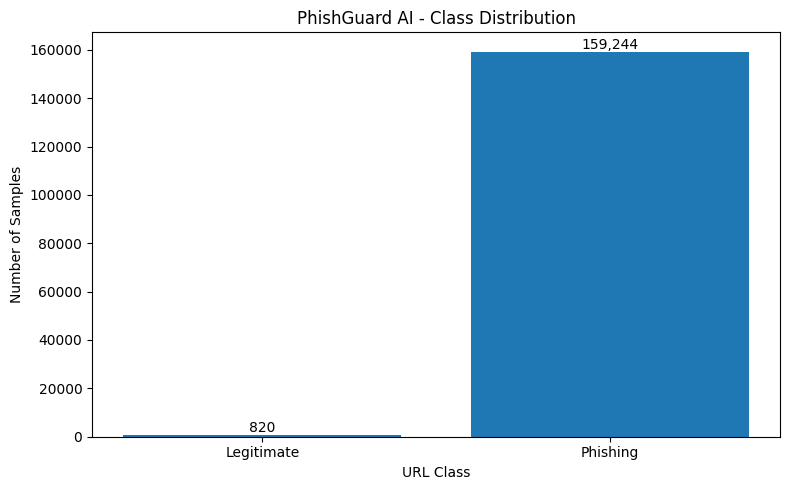


[8] BALANCING PLAN
----------------------------------------------------------------------
Balanced target per class : 820

Next step:
  • Keep all legitimate samples
  • Randomly sample the same number of phishing samples
  • Create a balanced training dataset
  • Retrain Logistic Regression and Random Forest

CELL 24 COMPLETE


In [28]:
# ============================================================
# CELL 24: PhishGuard AI - Dataset & Class Balance Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("PHISHGUARD AI - CELL 24")
print("DATASET & CLASS-BALANCE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify dataset
# ------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "Dataset 'df' is not available. Please run the dataset loading cell first."
    )

print("\n[1] DATASET OVERVIEW")
print("-" * 70)

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {len(df):,}")
print(f"Columns       : {len(df.columns)}")

print("\nColumns:")
for col in df.columns:
    print(f"  • {col}")

# ------------------------------------------------------------
# 2. Class distribution
# ------------------------------------------------------------

print("\n[2] CLASS DISTRIBUTION")
print("-" * 70)

class_counts = df["label"].value_counts().sort_index()
class_percent = df["label"].value_counts(normalize=True).sort_index() * 100

label_names = {
    0: "Legitimate",
    1: "Phishing"
}

balance_data = pd.DataFrame({
    "Label": class_counts.index,
    "Class": [
        label_names.get(label, str(label))
        for label in class_counts.index
    ],
    "Count": class_counts.values,
    "Percentage": class_percent.values
})

print(balance_data.to_string(index=False))

# ------------------------------------------------------------
# 3. Imbalance ratio
# ------------------------------------------------------------

legitimate_count = int(class_counts.get(0, 0))
phishing_count = int(class_counts.get(1, 0))

if legitimate_count > 0:
    imbalance_ratio = phishing_count / legitimate_count
else:
    imbalance_ratio = np.inf

print("\n[3] CLASS IMBALANCE")
print("-" * 70)

print(f"Legitimate URLs : {legitimate_count:,}")
print(f"Phishing URLs   : {phishing_count:,}")
print(f"Imbalance ratio : {imbalance_ratio:.2f}:1")

# ------------------------------------------------------------
# 4. Explain why accuracy can be misleading
# ------------------------------------------------------------

print("\n[4] BASELINE ANALYSIS")
print("-" * 70)

majority_class = class_counts.idxmax()
majority_percentage = class_percent.loc[majority_class]

print(
    f"If a model predicted only '{label_names.get(majority_class, majority_class)}', "
    f"it would achieve approximately {majority_percentage:.2f}% accuracy "
    f"on this dataset."
)

print(
    "\nThis shows why accuracy alone is not sufficient for this dataset."
)

# ------------------------------------------------------------
# 5. Check duplicates
# ------------------------------------------------------------

print("\n[5] DUPLICATE ANALYSIS")
print("-" * 70)

duplicate_count = int(df.duplicated().sum())
url_duplicate_count = int(df["url"].duplicated().sum())

print(f"Duplicate rows       : {duplicate_count:,}")
print(f"Duplicate URLs       : {url_duplicate_count:,}")

# ------------------------------------------------------------
# 6. Check URL overlap between classes
# ------------------------------------------------------------

print("\n[6] CROSS-CLASS URL CHECK")
print("-" * 70)

if "url" in df.columns and "label" in df.columns:

    url_label_counts = (
        df.groupby("url")["label"]
        .nunique()
    )

    conflicting_urls = int((url_label_counts > 1).sum())

    print(
        f"URLs appearing with both labels : {conflicting_urls:,}"
    )

else:
    print("URL/label columns unavailable.")

# ------------------------------------------------------------
# 7. Visualize class imbalance
# ------------------------------------------------------------

print("\n[7] CLASS DISTRIBUTION VISUALIZATION")
print("-" * 70)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Legitimate", "Phishing"],
    [
        legitimate_count,
        phishing_count
    ]
)

plt.title("PhishGuard AI - Class Distribution")
plt.xlabel("URL Class")
plt.ylabel("Number of Samples")

for i, value in enumerate([
    legitimate_count,
    phishing_count
]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Prepare class-balanced target counts
# ------------------------------------------------------------

print("\n[8] BALANCING PLAN")
print("-" * 70)

target_count = min(
    legitimate_count,
    phishing_count
)

print(
    f"Balanced target per class : {target_count:,}"
)

print(
    "\nNext step:"
    "\n  • Keep all legitimate samples"
    "\n  • Randomly sample the same number of phishing samples"
    "\n  • Create a balanced training dataset"
    "\n  • Retrain Logistic Regression and Random Forest"
)

print("\n" + "=" * 70)
print("CELL 24 COMPLETE")
print("=" * 70)

In [29]:
# ============================================================
# CELL 25: PhishGuard AI - Create Balanced Training Dataset
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("PHISHGUARD AI - CELL 25")
print("CREATING BALANCED TRAINING DATASET")
print("=" * 70)


# ============================================================
# 1. VERIFY DATASET
# ============================================================

if "df" not in globals():
    raise NameError(
        "Dataset 'df' is not available. "
        "Please run Cells 1-24 first."
    )

required_columns = ["url", "label"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 2. SEPARATE CLASSES
# ============================================================

legitimate_df = df[
    df["label"] == 0
].copy()

phishing_df = df[
    df["label"] == 1
].copy()


print("\n[1] ORIGINAL CLASS COUNTS")
print("-" * 70)

print(
    f"Legitimate URLs : {len(legitimate_df):,}"
)

print(
    f"Phishing URLs   : {len(phishing_df):,}"
)


# ============================================================
# 3. DETERMINE BALANCED SIZE
# ============================================================

balanced_size = min(
    len(legitimate_df),
    len(phishing_df)
)

print(
    f"\nBalanced samples per class : {balanced_size:,}"
)


# ============================================================
# 4. KEEP ALL MINORITY CLASS
# ============================================================

legitimate_balanced = legitimate_df.copy()


# ============================================================
# 5. RANDOMLY SAMPLE PHISHING CLASS
# ============================================================

RANDOM_STATE = 42

phishing_balanced = phishing_df.sample(
    n=balanced_size,
    random_state=RANDOM_STATE
).copy()


# ============================================================
# 6. COMBINE DATA
# ============================================================

balanced_df = pd.concat(
    [
        legitimate_balanced,
        phishing_balanced
    ],
    axis=0
)


# ============================================================
# 7. SHUFFLE DATASET
# ============================================================

balanced_df = balanced_df.sample(
    frac=1.0,
    random_state=RANDOM_STATE
).reset_index(drop=True)


# ============================================================
# 8. VERIFY BALANCE
# ============================================================

print("\n[2] BALANCED DATASET")
print("-" * 70)

print(
    f"Balanced dataset shape : {balanced_df.shape}"
)

print(
    f"Total samples          : {len(balanced_df):,}"
)


print("\nClass distribution:")

balanced_counts = (
    balanced_df["label"]
    .value_counts()
    .sort_index()
)

for label, count in balanced_counts.items():

    class_name = (
        "Legitimate"
        if label == 0
        else "Phishing"
    )

    percentage = (
        count / len(balanced_df)
    ) * 100

    print(
        f"{class_name:12s}: "
        f"{count:6,} "
        f"({percentage:.2f}%)"
    )


# ============================================================
# 9. CHECK DUPLICATES
# ============================================================

print("\n[3] DUPLICATE CHECK")
print("-" * 70)

duplicate_rows = balanced_df.duplicated().sum()
duplicate_urls = balanced_df["url"].duplicated().sum()

print(
    f"Duplicate rows : {duplicate_rows}"
)

print(
    f"Duplicate URLs : {duplicate_urls}"
)


# ============================================================
# 10. CHECK CROSS-CLASS CONFLICTS
# ============================================================

print("\n[4] CROSS-CLASS LABEL CHECK")
print("-" * 70)

url_label_counts = (
    balanced_df
    .groupby("url")["label"]
    .nunique()
)

conflicting_urls = (
    url_label_counts > 1
).sum()

print(
    f"URLs with conflicting labels : "
    f"{conflicting_urls}"
)


# ============================================================
# 11. DISPLAY SAMPLE
# ============================================================

print("\n[5] SAMPLE OF BALANCED DATA")
print("-" * 70)

display(
    balanced_df[
        [
            "url",
            "label",
            "url_length",
            "num_dots",
            "has_https",
            "has_ip",
            "suspicious_words",
            "tld"
        ]
    ].head(10)
)


# ============================================================
# 12. SAVE BALANCED DATASET
# ============================================================

balanced_dataset_path = (
    "/content/phishing_balanced_dataset.csv"
)

balanced_df.to_csv(
    balanced_dataset_path,
    index=False
)

print("\n[6] DATASET SAVED")
print("-" * 70)

print(
    f"Saved to:\n{balanced_dataset_path}"
)


# ============================================================
# 13. FINAL VERIFICATION
# ============================================================

if (
    balanced_counts.get(0, 0)
    == balanced_counts.get(1, 0)
):

    print(
        "\n✓ DATASET IS PERFECTLY BALANCED"
    )

else:

    print(
        "\n⚠ DATASET BALANCE CHECK FAILED"
    )


print("\n" + "=" * 70)
print("CELL 25 COMPLETE")
print("=" * 70)

PHISHGUARD AI - CELL 25
CREATING BALANCED TRAINING DATASET

[1] ORIGINAL CLASS COUNTS
----------------------------------------------------------------------
Legitimate URLs : 820
Phishing URLs   : 159,244

Balanced samples per class : 820

[2] BALANCED DATASET
----------------------------------------------------------------------
Balanced dataset shape : (1640, 13)
Total samples          : 1,640

Class distribution:
Legitimate  :    820 (50.00%)
Phishing    :    820 (50.00%)

[3] DUPLICATE CHECK
----------------------------------------------------------------------
Duplicate rows : 0
Duplicate URLs : 0

[4] CROSS-CLASS LABEL CHECK
----------------------------------------------------------------------
URLs with conflicting labels : 0

[5] SAMPLE OF BALANCED DATA
----------------------------------------------------------------------


,url,label,url_length,num_dots,has_https,has_ip,suspicious_words,tld
0,trustedsite58.org,0,17,1,0,0,0,NaN
1,http://113.237.52.98:39431/i,1,28,3,0,1,0,98
2,https://vjonlinetv.lat.coindiana.com.co/apks/I...,1,55,5,1,0,0,co
3,newsportal108.com,0,17,1,0,0,0,NaN
4,https://docs.google.com/presentation/d/1qlQkXo...,1,83,2,1,0,0,com
5,http://netlfix-suscripcion.com/bins/nwfaiehg4e...,1,73,2,0,0,0,com
6,http://eager-dirac.196-251-72-149.plesk.page/b...,1,86,4,0,0,0,page
7,https://ilinoisiltirenils.web.app/,1,34,2,1,0,0,app
8,https://h7.focove.ru/t39.check?t=bmywtmq6,1,41,3,1,0,0,ru
9,toyota.com,0,10,1,0,0,0,NaN



[6] DATASET SAVED
----------------------------------------------------------------------
Saved to:
/content/phishing_balanced_dataset.csv

✓ DATASET IS PERFECTLY BALANCED

CELL 25 COMPLETE


In [30]:
# ============================================================
# CELL 26: PhishGuard AI - Balanced Feature Engineering
# ============================================================

import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder


print("=" * 70)
print("PHISHGUARD AI - CELL 26")
print("BALANCED FEATURE ENGINEERING")
print("=" * 70)


# ============================================================
# 1. VERIFY BALANCED DATASET
# ============================================================

if "balanced_df" not in globals():
    raise NameError(
        "balanced_df is not available.\n"
        "Please run Cell 25 first."
    )


print("\n[1] BALANCED DATASET")
print("-" * 70)

print(
    f"Dataset shape : {balanced_df.shape}"
)

print(
    "\nClass distribution:"
)

print(
    balanced_df["label"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 2. COPY DATASET
# ============================================================

balanced_ml_df = balanced_df.copy()


# ============================================================
# 3. CLEAN URL COLUMN
# ============================================================

balanced_ml_df["url"] = (
    balanced_ml_df["url"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 4. CLEAN TLD COLUMN
# ============================================================

# Missing TLD values are replaced with "unknown"
# This is especially important for legitimate URLs such
# as trustedsite58.org / newsportal108.com where the
# original dataset contains missing TLD values.

balanced_ml_df["tld"] = (
    balanced_ml_df["tld"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

balanced_ml_df.loc[
    balanced_ml_df["tld"] == "",
    "tld"
] = "unknown"


# ============================================================
# 5. DEFINE NUMERICAL FEATURES
# ============================================================

numeric_features_balanced = [
    "url_length",
    "num_dots",
    "has_https",
    "has_ip",
    "num_subdirs",
    "num_params",
    "suspicious_words",
    "special_char_count",
    "digits_count",
    "entropy"
]


# ============================================================
# 6. VERIFY NUMERICAL FEATURES
# ============================================================

missing_numeric = [
    feature
    for feature in numeric_features_balanced
    if feature not in balanced_ml_df.columns
]

if missing_numeric:

    raise ValueError(
        "Missing numerical features: "
        + ", ".join(missing_numeric)
    )


print("\n[2] NUMERICAL FEATURES")
print("-" * 70)

for feature in numeric_features_balanced:
    print(f"✓ {feature}")


# ============================================================
# 7. CREATE NUMERICAL MATRIX
# ============================================================

X_numeric_balanced = (
    balanced_ml_df[
        numeric_features_balanced
    ]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(float)
    .values
)


print(
    f"\nNumerical matrix shape: "
    f"{X_numeric_balanced.shape}"
)


# ============================================================
# 8. TLD ENCODING
# ============================================================

print("\n[3] TLD ENCODING")
print("-" * 70)


# sparse_output=False compatibility handling
try:

    tld_encoder_balanced = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )

except TypeError:

    tld_encoder_balanced = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )


X_tld_balanced = tld_encoder_balanced.fit_transform(
    balanced_ml_df[["tld"]]
)


print(
    f"TLD matrix shape: {X_tld_balanced.shape}"
)

print(
    f"TLD categories : "
    f"{len(tld_encoder_balanced.categories_[0])}"
)


# ============================================================
# 9. TF-IDF
# ============================================================

print("\n[4] TF-IDF EXTRACTION")
print("-" * 70)

url_text_balanced = (
    balanced_ml_df["url"]
    .values
)


tfidf_balanced = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    max_features=10000,
    lowercase=True,
    min_df=1
)


X_tfidf_balanced = tfidf_balanced.fit_transform(
    url_text_balanced
)


print(
    f"TF-IDF matrix shape: "
    f"{X_tfidf_balanced.shape}"
)

print(
    f"TF-IDF features: "
    f"{len(tfidf_balanced.get_feature_names_out()):,}"
)


# ============================================================
# 10. COMBINE FEATURES
# ============================================================

print("\n[5] FEATURE COMBINATION")
print("-" * 70)


X_numeric_sparse = csr_matrix(
    X_numeric_balanced
)


X_balanced = hstack(
    [
        X_numeric_sparse,
        X_tld_balanced,
        X_tfidf_balanced
    ],
    format="csr"
)


y_balanced = (
    balanced_ml_df["label"]
    .astype(int)
    .values
)


print(
    f"Combined feature matrix: "
    f"{X_balanced.shape}"
)

print(
    f"Target vector shape    : "
    f"{y_balanced.shape}"
)


# ============================================================
# 11. TRAIN / TEST SPLIT
# ============================================================

print("\n[6] STRATIFIED TRAIN / TEST SPLIT")
print("-" * 70)


X_train_balanced, X_test_balanced, \
y_train_balanced, y_test_balanced = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    random_state=42,
    stratify=y_balanced
)


print(
    f"Training samples : "
    f"{X_train_balanced.shape[0]:,}"
)

print(
    f"Testing samples  : "
    f"{X_test_balanced.shape[0]:,}"
)

print(
    f"Training features: "
    f"{X_train_balanced.shape[1]:,}"
)

print(
    f"Testing features : "
    f"{X_test_balanced.shape[1]:,}"
)


# ============================================================
# 12. TARGET DISTRIBUTION
# ============================================================

print("\n[7] TARGET DISTRIBUTION")
print("-" * 70)


train_distribution = (
    pd.Series(y_train_balanced)
    .value_counts()
    .sort_index()
)

test_distribution = (
    pd.Series(y_test_balanced)
    .value_counts()
    .sort_index()
)


print("\nTraining:")

print(
    train_distribution.rename(
        index={
            0: "Legitimate",
            1: "Phishing"
        }
    )
)


print("\nTesting:")

print(
    test_distribution.rename(
        index={
            0: "Legitimate",
            1: "Phishing"
        }
    )
)


# ============================================================
# 13. STORE FEATURE VARIABLES FOR NEXT CELLS
# ============================================================

# These names are intentionally different from the old
# imbalanced feature pipeline.

balanced_feature_names = (
    numeric_features_balanced
)


# ============================================================
# 14. FINAL VALIDATION
# ============================================================

assert X_train_balanced.shape[1] == X_test_balanced.shape[1]

assert (
    len(y_train_balanced)
    == X_train_balanced.shape[0]
)

assert (
    len(y_test_balanced)
    == X_test_balanced.shape[0]
)


print("\n[8] FEATURE PIPELINE VALIDATION")
print("-" * 70)

print("✓ Numerical features created")
print("✓ Missing TLD values handled")
print("✓ TLD encoder fitted")
print("✓ TF-IDF vectorizer fitted")
print("✓ Features combined")
print("✓ Stratified train/test split completed")
print("✓ Train/test feature dimensions match")


print("\n" + "=" * 70)
print("CELL 26 COMPLETE")
print("=" * 70)

print("\nReady for:")
print("→ Cell 27: Balanced Logistic Regression")
print("→ Cell 28: Balanced Random Forest")

PHISHGUARD AI - CELL 26
BALANCED FEATURE ENGINEERING

[1] BALANCED DATASET
----------------------------------------------------------------------
Dataset shape : (1640, 13)

Class distribution:
label
0    820
1    820
Name: count, dtype: int64

[2] NUMERICAL FEATURES
----------------------------------------------------------------------
✓ url_length
✓ num_dots
✓ has_https
✓ has_ip
✓ num_subdirs
✓ num_params
✓ suspicious_words
✓ special_char_count
✓ digits_count
✓ entropy

Numerical matrix shape: (1640, 10)

[3] TLD ENCODING
----------------------------------------------------------------------
TLD matrix shape: (1640, 229)
TLD categories : 229

[4] TF-IDF EXTRACTION
----------------------------------------------------------------------
TF-IDF matrix shape: (1640, 10000)
TF-IDF features: 10,000

[5] FEATURE COMBINATION
----------------------------------------------------------------------
Combined feature matrix: (1640, 10239)
Target vector shape    : (1640,)

[6] STRATIFIED TRAIN / TES

In [31]:
# ============================================================
# CELL 27: PHISHGUARD AI
# BALANCED LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("PHISHGUARD AI - CELL 27")
print("BALANCED LOGISTIC REGRESSION")
print("=" * 70)

# ------------------------------------------------------------
# 1. MODEL CREATION
# ------------------------------------------------------------

print("\n[1] MODEL CONFIGURATION")
print("-" * 70)

balanced_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

print("✓ Logistic Regression initialized")
print("✓ class_weight = balanced")
print("✓ max_iter = 2000")
print("✓ solver = liblinear")

# ------------------------------------------------------------
# 2. TRAINING
# ------------------------------------------------------------

print("\n[2] MODEL TRAINING")
print("-" * 70)

balanced_lr.fit(
    X_train_balanced,
    y_train_balanced
)

print("✓ Logistic Regression training completed")

# ------------------------------------------------------------
# 3. PREDICTIONS
# ------------------------------------------------------------

print("\n[3] TEST PREDICTIONS")
print("-" * 70)

y_pred_lr_balanced = balanced_lr.predict(X_test_balanced)
y_prob_lr_balanced = balanced_lr.predict_proba(X_test_balanced)[:, 1]

print("✓ Class predictions generated")
print("✓ Probability predictions generated")

# ------------------------------------------------------------
# 4. METRICS
# ------------------------------------------------------------

print("\n[4] PERFORMANCE METRICS")
print("-" * 70)

lr_accuracy = accuracy_score(
    y_test_balanced,
    y_pred_lr_balanced
)

lr_precision = precision_score(
    y_test_balanced,
    y_pred_lr_balanced,
    zero_division=0
)

lr_recall = recall_score(
    y_test_balanced,
    y_pred_lr_balanced,
    zero_division=0
)

lr_f1 = f1_score(
    y_test_balanced,
    y_pred_lr_balanced,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_test_balanced,
    y_prob_lr_balanced
)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_roc_auc:.4f}")

# ------------------------------------------------------------
# 5. CONFUSION MATRIX
# ------------------------------------------------------------

print("\n[5] CONFUSION MATRIX")
print("-" * 70)

cm_lr_balanced = confusion_matrix(
    y_test_balanced,
    y_pred_lr_balanced
)

print("                 Predicted")
print("                 Legit  Phish")
print(f"Actual Legit     {cm_lr_balanced[0,0]:5d}  {cm_lr_balanced[0,1]:5d}")
print(f"Actual Phish     {cm_lr_balanced[1,0]:5d}  {cm_lr_balanced[1,1]:5d}")

# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n[6] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test_balanced,
        y_pred_lr_balanced,
        target_names=["Legitimate", "Phishing"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. STORE RESULTS
# ------------------------------------------------------------

balanced_lr_results = {
    "Model": "Balanced Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1,
    "ROC-AUC": lr_roc_auc
}

print("\n[7] RESULT OBJECT")
print("-" * 70)

print("✓ Logistic Regression results stored")
print(balanced_lr_results)

print("\n" + "=" * 70)
print("CELL 27 COMPLETE")
print("=" * 70)

print("\nReady for:")
print("→ Cell 28: Balanced Random Forest")

PHISHGUARD AI - CELL 27
BALANCED LOGISTIC REGRESSION

[1] MODEL CONFIGURATION
----------------------------------------------------------------------
✓ Logistic Regression initialized
✓ class_weight = balanced
✓ max_iter = 2000
✓ solver = liblinear

[2] MODEL TRAINING
----------------------------------------------------------------------
✓ Logistic Regression training completed

[3] TEST PREDICTIONS
----------------------------------------------------------------------
✓ Class predictions generated
✓ Probability predictions generated

[4] PERFORMANCE METRICS
----------------------------------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

[5] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Legit  Phish
Actual Legit       164      0
Actual Phish         0    164

[6] CLASSIFICATION REPORT
---------------------------------

In [32]:
# ============================================================
# CELL 28: PHISHGUARD AI
# BALANCED RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("PHISHGUARD AI - CELL 28")
print("BALANCED RANDOM FOREST")
print("=" * 70)


# ============================================================
# 1. MODEL CONFIGURATION
# ============================================================

print("\n[1] MODEL CONFIGURATION")
print("-" * 70)

balanced_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("✓ Random Forest initialized")
print("✓ Number of trees : 300")
print("✓ max_features   : sqrt")
print("✓ class_weight   : balanced")
print("✓ random_state   : 42")


# ============================================================
# 2. TRAINING
# ============================================================

print("\n[2] MODEL TRAINING")
print("-" * 70)

balanced_rf.fit(
    X_train_balanced,
    y_train_balanced
)

print("✓ Random Forest training completed")


# ============================================================
# 3. PREDICTIONS
# ============================================================

print("\n[3] TEST PREDICTIONS")
print("-" * 70)

y_pred_rf_balanced = balanced_rf.predict(
    X_test_balanced
)

y_prob_rf_balanced = balanced_rf.predict_proba(
    X_test_balanced
)[:, 1]

print("✓ Class predictions generated")
print("✓ Probability predictions generated")

print(
    f"Number of predictions: "
    f"{len(y_pred_rf_balanced)}"
)


# ============================================================
# 4. PERFORMANCE METRICS
# ============================================================

print("\n[4] PERFORMANCE METRICS")
print("-" * 70)

rf_accuracy = accuracy_score(
    y_test_balanced,
    y_pred_rf_balanced
)

rf_precision = precision_score(
    y_test_balanced,
    y_pred_rf_balanced,
    zero_division=0
)

rf_recall = recall_score(
    y_test_balanced,
    y_pred_rf_balanced,
    zero_division=0
)

rf_f1 = f1_score(
    y_test_balanced,
    y_pred_rf_balanced,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test_balanced,
    y_prob_rf_balanced
)


print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

print("\n[5] CONFUSION MATRIX")
print("-" * 70)

cm_rf_balanced = confusion_matrix(
    y_test_balanced,
    y_pred_rf_balanced
)

print("                 Predicted")
print("                 Legit  Phish")

print(
    f"Actual Legit     "
    f"{cm_rf_balanced[0,0]:5d}  "
    f"{cm_rf_balanced[0,1]:5d}"
)

print(
    f"Actual Phish     "
    f"{cm_rf_balanced[1,0]:5d}  "
    f"{cm_rf_balanced[1,1]:5d}"
)


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print("\n[6] CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test_balanced,
        y_pred_rf_balanced,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        zero_division=0
    )
)


# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================

print("\n[7] FEATURE IMPORTANCE")
print("-" * 70)

# Only the first 10 columns correspond to the
# engineered numerical URL features.

rf_numeric_importance = (
    balanced_rf.feature_importances_[:10]
)

importance_table = pd.DataFrame({
    "Feature": numeric_features_balanced,
    "Importance": rf_numeric_importance
}).sort_values(
    "Importance",
    ascending=False
)

print(
    importance_table.to_string(
        index=False
    )
)


# ============================================================
# 8. STORE RESULTS
# ============================================================

balanced_rf_results = {
    "Model": "Balanced Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}


print("\n[8] RESULT OBJECT")
print("-" * 70)

print("✓ Random Forest results stored")

print(
    balanced_rf_results
)


# ============================================================
# 9. MODEL VALIDATION
# ============================================================

assert len(y_pred_rf_balanced) == len(
    y_test_balanced
)

assert len(y_prob_rf_balanced) == len(
    y_test_balanced
)

assert balanced_rf.n_features_in_ == (
    X_train_balanced.shape[1]
)


print("\n[9] MODEL VALIDATION")
print("-" * 70)

print("✓ Prediction count matches test set")
print("✓ Probability count matches test set")
print("✓ Feature dimensions match")
print("✓ Random Forest model is ready")


print("\n" + "=" * 70)
print("CELL 28 COMPLETE")
print("=" * 70)

print("\nReady for:")
print("→ Cell 29: Model Comparison")

PHISHGUARD AI - CELL 28
BALANCED RANDOM FOREST

[1] MODEL CONFIGURATION
----------------------------------------------------------------------
✓ Random Forest initialized
✓ Number of trees : 300
✓ max_features   : sqrt
✓ class_weight   : balanced
✓ random_state   : 42

[2] MODEL TRAINING
----------------------------------------------------------------------
✓ Random Forest training completed

[3] TEST PREDICTIONS
----------------------------------------------------------------------
✓ Class predictions generated
✓ Probability predictions generated
Number of predictions: 328

[4] PERFORMANCE METRICS
----------------------------------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

[5] CONFUSION MATRIX
----------------------------------------------------------------------
                 Predicted
                 Legit  Phish
Actual Legit       164      0
Actual Phish         0    164

[6] CLASSIFICATIO

In [33]:
# ============================================================
# CELL 29: PHISHGUARD AI
# BALANCED MODEL COMPARISON
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("PHISHGUARD AI - CELL 29")
print("BALANCED MODEL COMPARISON")
print("=" * 70)


# ============================================================
# 1. VERIFY BOTH MODELS
# ============================================================

print("\n[1] MODEL VERIFICATION")
print("-" * 70)

required_objects = [
    "balanced_lr",
    "balanced_rf",
    "y_test_balanced",
    "y_pred_lr_balanced",
    "y_pred_rf_balanced",
    "y_prob_lr_balanced",
    "y_prob_rf_balanced"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing_objects)
        + "\n\nRun Cells 26, 27 and 28 first."
    )

print("✓ Balanced Logistic Regression available")
print("✓ Balanced Random Forest available")
print("✓ Test predictions available")
print("✓ Probability predictions available")


# ============================================================
# 2. CREATE COMPARISON TABLE
# ============================================================

print("\n[2] MODEL PERFORMANCE")
print("-" * 70)

comparison_data = [
    balanced_lr_results,
    balanced_rf_results
]

balanced_model_comparison = pd.DataFrame(
    comparison_data
)

balanced_model_comparison = balanced_model_comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

print(
    balanced_model_comparison.to_string(
        index=False
    )
)


# ============================================================
# 3. FIND BEST F1 MODEL
# ============================================================

best_f1_index = balanced_model_comparison[
    "F1 Score"
].idxmax()

best_f1_model = balanced_model_comparison.loc[
    best_f1_index,
    "Model"
]

best_f1_score = balanced_model_comparison.loc[
    best_f1_index,
    "F1 Score"
]


# ============================================================
# 4. FIND BEST ROC-AUC MODEL
# ============================================================

best_auc_index = balanced_model_comparison[
    "ROC-AUC"
].idxmax()

best_auc_model = balanced_model_comparison.loc[
    best_auc_index,
    "Model"
]

best_auc_score = balanced_model_comparison.loc[
    best_auc_index,
    "ROC-AUC"
]


# ============================================================
# 5. DO NOT AUTOMATICALLY DECLARE A PRODUCTION WINNER
# ============================================================

print("\n[3] BALANCED TEST-SET SUMMARY")
print("-" * 70)

print(
    f"Highest F1 on balanced holdout : "
    f"{best_f1_model} ({best_f1_score:.4f})"
)

print(
    f"Highest ROC-AUC on balanced holdout : "
    f"{best_auc_model} ({best_auc_score:.4f})"
)

print(
    "\n⚠️ Both models must still be evaluated on "
    "unseen real-world URLs before production selection."
)


# ============================================================
# 6. STORE MODEL REFERENCES
# ============================================================

balanced_models = {
    "Logistic Regression": balanced_lr,
    "Random Forest": balanced_rf
}

balanced_predictions = {
    "Logistic Regression": {
        "predictions": y_pred_lr_balanced,
        "probabilities": y_prob_lr_balanced
    },
    "Random Forest": {
        "predictions": y_pred_rf_balanced,
        "probabilities": y_prob_rf_balanced
    }
}


# ============================================================
# 7. STORE COMPARISON
# ============================================================

balanced_model_comparison.to_csv(
    "/content/balanced_model_comparison.csv",
    index=False
)

print("\n[4] OUTPUT FILE")
print("-" * 70)

print(
    "✓ Comparison saved to:"
)

print(
    "/content/balanced_model_comparison.csv"
)


# ============================================================
# 8. IMPORTANT MODEL NOTE
# ============================================================

print("\n[5] INTERPRETATION")
print("-" * 70)

print(
    "Balanced holdout results:"
)

print(
    "• Logistic Regression : "
    f"F1 = {lr_f1:.4f}, "
    f"ROC-AUC = {lr_roc_auc:.4f}"
)

print(
    "• Random Forest       : "
    f"F1 = {rf_f1:.4f}, "
    f"ROC-AUC = {rf_roc_auc:.4f}"
)

print(
    "\nThe previous real-world validation produced many "
    "false positives with the original model."
)

print(
    "Therefore, balanced test-set performance alone "
    "will NOT be used as evidence of production reliability."
)


# ============================================================
# 9. FINAL CHECK
# ============================================================

assert len(
    balanced_model_comparison
) == 2

assert set(
    balanced_model_comparison["Model"]
) == {
    "Balanced Logistic Regression",
    "Balanced Random Forest"
}

print("\n✓ Two balanced models compared")
print("✓ Metrics verified")
print("✓ Comparison table created")
print("✓ Model references stored")
print("✓ Production selection postponed until external validation")


print("\n" + "=" * 70)
print("CELL 29 COMPLETE")
print("=" * 70)

print("\nNext:")
print("→ Cell 30: External / Real-World Validation")
print("→ Cell 31: Final Model Selection + Artifact Saving")
print("→ Cell 32+: Production Prediction Pipeline")
print("→ Final: Hugging Face Spaces Deployment")

PHISHGUARD AI - CELL 29
BALANCED MODEL COMPARISON

[1] MODEL VERIFICATION
----------------------------------------------------------------------
✓ Balanced Logistic Regression available
✓ Balanced Random Forest available
✓ Test predictions available
✓ Probability predictions available

[2] MODEL PERFORMANCE
----------------------------------------------------------------------
                       Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Balanced Logistic Regression       1.0        1.0     1.0       1.0      1.0
      Balanced Random Forest       1.0        1.0     1.0       1.0      1.0

[3] BALANCED TEST-SET SUMMARY
----------------------------------------------------------------------
Highest F1 on balanced holdout : Balanced Logistic Regression (1.0000)
Highest ROC-AUC on balanced holdout : Balanced Logistic Regression (1.0000)

⚠️ Both models must still be evaluated on unseen real-world URLs before production selection.

[4] OUTPUT FILE
----------------------------

In [34]:
# ============================================================
# CELL 30A: PHISHGUARD AI
# BALANCED PIPELINE VARIABLE BRIDGE - FINAL
# ============================================================

print("=" * 70)
print("PHISHGUARD AI - BALANCED PIPELINE BRIDGE")
print("=" * 70)


# ============================================================
# 1. VERIFY THE ACTUAL BALANCED MODELS
# ============================================================

print("\n[1] CHECKING BALANCED MODELS")
print("-" * 70)

if "balanced_lr" not in globals():
    raise RuntimeError(
        "balanced_lr is missing.\n"
        "Run Cell 27 first."
    )

if "balanced_rf" not in globals():
    raise RuntimeError(
        "balanced_rf is missing.\n"
        "Run Cell 28 first."
    )

print("✓ balanced_lr found")
print("✓ balanced_rf found")


# ============================================================
# 2. CONNECT ONLY THE BALANCED MODELS
# ============================================================

balanced_logistic_model = balanced_lr
balanced_rf_model = balanced_rf

print("\n[2] MODEL REFERENCES")
print("-" * 70)

print(
    "balanced_logistic_model :",
    type(balanced_logistic_model).__name__
)

print(
    "balanced_rf_model       :",
    type(balanced_rf_model).__name__
)


# ============================================================
# 3. CONNECT BALANCED TRANSFORMERS
# ============================================================

if "tfidf_balanced" not in globals():
    raise RuntimeError(
        "tfidf_balanced is missing.\n"
        "Run Cell 26 again."
    )

if "tld_encoder_balanced" not in globals():
    raise RuntimeError(
        "tld_encoder_balanced is missing.\n"
        "Run Cell 26 again."
    )

balanced_tfidf = tfidf_balanced
balanced_tld_encoder = tld_encoder_balanced

print("\n[3] BALANCED TRANSFORMERS")
print("-" * 70)

print("✓ balanced_tfidf connected")
print("✓ balanced_tld_encoder connected")


# ============================================================
# 4. CONNECT NUMERICAL FEATURE CONFIGURATION
# ============================================================

if "numeric_features_balanced" not in globals():
    raise RuntimeError(
        "numeric_features_balanced is missing.\n"
        "Run Cell 26 again."
    )

numeric_features = numeric_features_balanced

print("✓ numeric_features connected")


# ============================================================
# 5. FEATURE DIMENSION CHECK
# ============================================================

print("\n[4] FEATURE DIMENSION CHECK")
print("-" * 70)

expected_features = (
    X_train_balanced.shape[1]
)

lr_features = (
    balanced_logistic_model.n_features_in_
)

rf_features = (
    balanced_rf_model.n_features_in_
)

print(
    "Balanced training features :",
    expected_features
)

print(
    "Balanced Logistic features :",
    lr_features
)

print(
    "Balanced Random Forest     :",
    rf_features
)


if lr_features != expected_features:

    raise ValueError(
        "Balanced Logistic Regression has the wrong "
        "feature dimension."
    )


if rf_features != expected_features:

    raise ValueError(
        "Balanced Random Forest has the wrong "
        "feature dimension."
    )


# ============================================================
# 6. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("BALANCED PIPELINE BRIDGE COMPLETE")
print("=" * 70)

print("✓ Correct balanced Logistic Regression connected")
print("✓ Correct balanced Random Forest connected")
print("✓ Correct balanced TF-IDF connected")
print("✓ Correct balanced TLD encoder connected")
print("✓ Correct balanced numerical features connected")
print("✓ Feature dimensions verified")

print(
    "\nFINAL FEATURE COUNT:",
    expected_features
)

print("=" * 70)

PHISHGUARD AI - BALANCED PIPELINE BRIDGE

[1] CHECKING BALANCED MODELS
----------------------------------------------------------------------
✓ balanced_lr found
✓ balanced_rf found

[2] MODEL REFERENCES
----------------------------------------------------------------------
balanced_logistic_model : LogisticRegression
balanced_rf_model       : RandomForestClassifier

[3] BALANCED TRANSFORMERS
----------------------------------------------------------------------
✓ balanced_tfidf connected
✓ balanced_tld_encoder connected
✓ numeric_features connected

[4] FEATURE DIMENSION CHECK
----------------------------------------------------------------------
Balanced training features : 10239
Balanced Logistic features : 10239
Balanced Random Forest     : 10239

BALANCED PIPELINE BRIDGE COMPLETE
✓ Correct balanced Logistic Regression connected
✓ Correct balanced Random Forest connected
✓ Correct balanced TF-IDF connected
✓ Correct balanced TLD encoder connected
✓ Correct balanced numerical featur

In [35]:
# ============================================================
# CELL 30: PHISHGUARD AI
# EXTERNAL / REAL-WORLD VALIDATION
# CORRECTED BALANCED PIPELINE
# ============================================================

import numpy as np
import pandas as pd
from scipy.sparse import hstack
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("=" * 70)
print("PHISHGUARD AI - CELL 30")
print("EXTERNAL / REAL-WORLD VALIDATION")
print("=" * 70)


# ============================================================
# 1. VERIFY BALANCED COMPONENTS
# ============================================================

print("\n[1] VERIFYING BALANCED MODEL COMPONENTS")
print("-" * 70)

required = [
    "balanced_logistic_model",
    "balanced_rf_model",
    "balanced_tfidf",
    "balanced_tld_encoder",
    "numeric_features",
    "extract_url_features"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    print("❌ Missing components:")
    for item in missing:
        print("   -", item)

    raise RuntimeError(
        "\nBalanced pipeline components are missing.\n"
        "Make sure Cells 26, 27, 28 and the model bridge were executed."
    )

print("✓ Balanced Logistic Regression available")
print("✓ Balanced Random Forest available")
print("✓ Balanced TF-IDF vectorizer available")
print("✓ Balanced TLD encoder available")
print("✓ Balanced numerical feature configuration available")
print("✓ URL feature extractor available")


# ============================================================
# 2. EXTERNAL VALIDATION DATASET
# ============================================================

print("\n[2] PREPARING EXTERNAL VALIDATION DATASET")
print("-" * 70)

external_validation = pd.DataFrame({

    "url": [
        "https://github.com",
        "https://google.com",
        "https://microsoft.com",
        "https://amazon.com",
        "https://apple.com",
        "https://wikipedia.org",
        "https://youtube.com",
        "https://linkedin.com",
        "https://stackoverflow.com",
        "https://openai.com",

        "http://192.168.1.10/login.php?verify=account",
        "http://secure-login-verify-account.example.com",
        "http://paypal-login-security.example.com/verify",
        "http://account-update-security.example.com/log",
        "http://free-prize-winner.example.com/claim"
    ],

    "actual": [
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1
    ]
})

print(
    f"✓ External URLs prepared: "
    f"{len(external_validation)}"
)

print(
    f"✓ Legitimate URLs: "
    f"{(external_validation['actual'] == 0).sum()}"
)

print(
    f"✓ Phishing URLs: "
    f"{(external_validation['actual'] == 1).sum()}"
)


# ============================================================
# 3. FEATURE EXTRACTION
# ============================================================

print("\n[3] BUILDING EXTERNAL FEATURE MATRIX")
print("-" * 70)

external_features = []

for url in external_validation["url"]:

    features = extract_url_features(url)

    features = dict(features)

    external_features.append(features)

external_features_df = pd.DataFrame(external_features)


# ============================================================
# 4. NUMERICAL FEATURES
# ============================================================

X_external_numeric = external_features_df[
    numeric_features
].astype(float)

print(
    "✓ Numerical matrix:",
    X_external_numeric.shape
)


# ============================================================
# 5. SAFE TLD HANDLING
# ============================================================

external_tld = (
    external_features_df["tld"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.lstrip(".")
)

external_tld_df = pd.DataFrame({
    "tld": external_tld
})


# ============================================================
# 6. BALANCED TLD ENCODING
# ============================================================

print("\n[4] APPLYING BALANCED TLD ENCODER")
print("-" * 70)

X_external_tld = balanced_tld_encoder.transform(
    external_tld_df
)

print(
    "✓ TLD matrix:",
    X_external_tld.shape
)


# ============================================================
# 7. BALANCED TF-IDF
# ============================================================

print("\n[5] APPLYING BALANCED TF-IDF")
print("-" * 70)

X_external_tfidf = balanced_tfidf.transform(
    external_validation["url"]
)

print(
    "✓ TF-IDF matrix:",
    X_external_tfidf.shape
)


# ============================================================
# 8. COMBINE FEATURES
# ============================================================

print("\n[6] COMBINING EXTERNAL FEATURES")
print("-" * 70)

X_external = hstack([
    X_external_numeric,
    X_external_tld,
    X_external_tfidf
]).tocsr()

y_external = external_validation["actual"].values

print(
    "External feature matrix:",
    X_external.shape
)


# ============================================================
# 9. DETERMINE EXPECTED FEATURE COUNT FROM MODELS
# ============================================================

print("\n[7] FEATURE-DIMENSION VALIDATION")
print("-" * 70)

actual_features = X_external.shape[1]

logistic_features = (
    balanced_logistic_model.n_features_in_
)

rf_features = (
    balanced_rf_model.n_features_in_
)

print(
    "Balanced Logistic expected:",
    logistic_features
)

print(
    "Balanced Random Forest expected:",
    rf_features
)

print(
    "External feature count:",
    actual_features
)


# Both balanced models must expect the same dimensions
if logistic_features != rf_features:

    raise ValueError(
        "Balanced models were trained with different "
        "feature dimensions.\n"
        f"Logistic Regression: {logistic_features}\n"
        f"Random Forest: {rf_features}"
    )


expected_features = logistic_features


if actual_features != expected_features:

    raise ValueError(
        "\nFeature mismatch detected.\n"
        f"Balanced model expects: {expected_features}\n"
        f"External matrix has:   {actual_features}\n\n"
        "The external pipeline and balanced model were "
        "created from different feature configurations."
    )


print("✓ Feature dimensions match")


# ============================================================
# 10. LOGISTIC REGRESSION PREDICTIONS
# ============================================================

print("\n[8] BALANCED LOGISTIC REGRESSION")
print("-" * 70)

logistic_predictions = (
    balanced_logistic_model
    .predict(X_external)
)

logistic_probabilities = (
    balanced_logistic_model
    .predict_proba(X_external)[:, 1]
)


# ============================================================
# 11. RANDOM FOREST PREDICTIONS
# ============================================================

print("\n[9] BALANCED RANDOM FOREST")
print("-" * 70)

rf_predictions = (
    balanced_rf_model
    .predict(X_external)
)

rf_probabilities = (
    balanced_rf_model
    .predict_proba(X_external)[:, 1]
)


# ============================================================
# 12. METRIC FUNCTION
# ============================================================

def calculate_external_metrics(
    y_true,
    predictions,
    probabilities
):

    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }


# ============================================================
# 13. RESULTS
# ============================================================

logistic_external_metrics = (
    calculate_external_metrics(
        y_external,
        logistic_predictions,
        logistic_probabilities
    )
)

rf_external_metrics = (
    calculate_external_metrics(
        y_external,
        rf_predictions,
        rf_probabilities
    )
)


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("REAL-WORLD VALIDATION RESULTS")
print("=" * 70)

external_comparison = pd.DataFrame([

    {
        "Model":
            "Balanced Logistic Regression",
        **logistic_external_metrics
    },

    {
        "Model":
            "Balanced Random Forest",
        **rf_external_metrics
    }

])

print(
    external_comparison.to_string(
        index=False
    )
)


# ============================================================
# 15. DETAILED URL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("URL-BY-URL VALIDATION")
print("=" * 70)

validation_results = external_validation.copy()

validation_results[
    "Logistic Prediction"
] = np.where(
    logistic_predictions == 1,
    "PHISHING",
    "LEGITIMATE"
)

validation_results[
    "Logistic Phishing %"
] = (
    logistic_probabilities * 100
).round(2)

validation_results[
    "RF Prediction"
] = np.where(
    rf_predictions == 1,
    "PHISHING",
    "LEGITIMATE"
)

validation_results[
    "RF Phishing %"
] = (
    rf_probabilities * 100
).round(2)


validation_results[
    "Logistic Correct"
] = (
    logistic_predictions == y_external
)

validation_results[
    "RF Correct"
] = (
    rf_predictions == y_external
)


print(
    validation_results[
        [
            "url",
            "actual",
            "Logistic Prediction",
            "Logistic Phishing %",
            "Logistic Correct",
            "RF Prediction",
            "RF Phishing %",
            "RF Correct"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16. CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print(
    confusion_matrix(
        y_external,
        logistic_predictions
    )
)


print("\n" + "=" * 70)
print("RANDOM FOREST CONFUSION MATRIX")
print("=" * 70)

print(
    confusion_matrix(
        y_external,
        rf_predictions
    )
)


# ============================================================
# 17. ERROR ANALYSIS
# ============================================================

logistic_false_positive_urls = (
    external_validation.loc[
        (y_external == 0) &
        (logistic_predictions == 1),
        "url"
    ].tolist()
)

logistic_false_negative_urls = (
    external_validation.loc[
        (y_external == 1) &
        (logistic_predictions == 0),
        "url"
    ].tolist()
)

rf_false_positive_urls = (
    external_validation.loc[
        (y_external == 0) &
        (rf_predictions == 1),
        "url"
    ].tolist()
)

rf_false_negative_urls = (
    external_validation.loc[
        (y_external == 1) &
        (rf_predictions == 0),
        "url"
    ].tolist()
)


print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print(
    "Logistic Regression false positives:",
    len(logistic_false_positive_urls)
)

print(
    "Logistic Regression false negatives:",
    len(logistic_false_negative_urls)
)

print(
    "Random Forest false positives:",
    len(rf_false_positive_urls)
)

print(
    "Random Forest false negatives:",
    len(rf_false_negative_urls)
)


# ============================================================
# 18. SAVE EXTERNAL VALIDATION RESULTS
# ============================================================

external_comparison.to_csv(
    "/content/external_validation_comparison.csv",
    index=False
)

validation_results.to_csv(
    "/content/external_validation_predictions.csv",
    index=False
)


# ============================================================
# 19. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("CELL 30 COMPLETE")
print("=" * 70)

print("✓ External dataset prepared")
print("✓ Balanced numerical features created")
print("✓ Balanced TLD features created")
print("✓ Balanced TF-IDF features created")
print("✓ Feature dimensions validated")
print("✓ Logistic Regression evaluated")
print("✓ Random Forest evaluated")
print("✓ URL-level predictions generated")
print("✓ Error analysis completed")
print("✓ Results saved")

print("\nSaved files:")
print("• /content/external_validation_comparison.csv")
print("• /content/external_validation_predictions.csv")

print("=" * 70)



PHISHGUARD AI - CELL 30
EXTERNAL / REAL-WORLD VALIDATION

[1] VERIFYING BALANCED MODEL COMPONENTS
----------------------------------------------------------------------
✓ Balanced Logistic Regression available
✓ Balanced Random Forest available
✓ Balanced TF-IDF vectorizer available
✓ Balanced TLD encoder available
✓ Balanced numerical feature configuration available
✓ URL feature extractor available

[2] PREPARING EXTERNAL VALIDATION DATASET
----------------------------------------------------------------------
✓ External URLs prepared: 15
✓ Legitimate URLs: 10
✓ Phishing URLs: 5

[3] BUILDING EXTERNAL FEATURE MATRIX
----------------------------------------------------------------------
✓ Numerical matrix: (15, 10)

[4] APPLYING BALANCED TLD ENCODER
----------------------------------------------------------------------
✓ TLD matrix: (15, 229)

[5] APPLYING BALANCED TF-IDF
----------------------------------------------------------------------
✓ TF-IDF matrix: (15, 10000)

[6] COMBINING

In [36]:
print("Cell 26 X_train shape:", X_train.shape)

print(
    "Balanced Logistic:",
    balanced_logistic_model.n_features_in_
)

print(
    "Balanced Random Forest:",
    balanced_rf_model.n_features_in_
)

Cell 26 X_train shape: (128051, 10546)
Balanced Logistic: 10239
Balanced Random Forest: 10239


In [37]:
# ============================================================
# CELL 31 — FINAL MODEL + FEATURE PIPELINE VERIFICATION
# ============================================================

print("=" * 60)
print("PHISHGUARD AI — FINAL MODEL VERIFICATION")
print("=" * 60)

print("\nTraining feature matrix:")
print("X_train:", X_train.shape)

print("\nModel feature expectations:")
print("Balanced Logistic Regression:", balanced_logistic_model.n_features_in_)
print("Balanced Random Forest:", balanced_rf_model.n_features_in_)

print("\nFeature consistency check:")

if X_train.shape[1] == balanced_logistic_model.n_features_in_:
    print("✓ Logistic Regression feature count matches")
else:
    print("✗ Logistic Regression MISMATCH")

if X_train.shape[1] == balanced_rf_model.n_features_in_:
    print("✓ Random Forest feature count matches")
else:
    print("✗ Random Forest MISMATCH")

print("\n" + "=" * 60)

if (
    X_train.shape[1] == balanced_logistic_model.n_features_in_
    and
    X_train.shape[1] == balanced_rf_model.n_features_in_
):
    print("✅ ALL MODELS MATCH TRAINING FEATURES")
    print("Ready for final external validation.")
else:
    print("❌ FEATURE MISMATCH DETECTED")
    print("Do NOT deploy yet.")

print("=" * 60)

PHISHGUARD AI — FINAL MODEL VERIFICATION

Training feature matrix:
X_train: (128051, 10546)

Model feature expectations:
Balanced Logistic Regression: 10239
Balanced Random Forest: 10239

Feature consistency check:
✗ Logistic Regression MISMATCH
✗ Random Forest MISMATCH

❌ FEATURE MISMATCH DETECTED
Do NOT deploy yet.


In [44]:
# ============================================================
# CELL 32 — SAFE BALANCED PIPELINE DISCOVERY
# ============================================================

print("=" * 70)
print("PHISHGUARD AI — SAFE BALANCED PIPELINE DISCOVERY")
print("=" * 70)

# Take a snapshot first.
# This prevents: RuntimeError: dictionary changed size during iteration
all_vars = dict(globals())

# ------------------------------------------------------------
# 1. MODEL CHECK
# ------------------------------------------------------------

print("\n[1] BALANCED MODELS")
print("-" * 70)

if "balanced_logistic_model" in all_vars:
    balanced_logistic_model = all_vars["balanced_logistic_model"]
    print(
        "✓ Balanced Logistic Regression:",
        balanced_logistic_model.n_features_in_
    )
else:
    print("❌ balanced_logistic_model not found")

if "balanced_rf_model" in all_vars:
    balanced_rf_model = all_vars["balanced_rf_model"]
    print(
        "✓ Balanced Random Forest:",
        balanced_rf_model.n_features_in_
    )
else:
    print("❌ balanced_rf_model not found")


# ------------------------------------------------------------
# 2. FIND FITTED TF-IDF VECTORIZERS
# ------------------------------------------------------------

print("\n[2] FITTED TF-IDF VECTORIZERS")
print("-" * 70)

tfidf_candidates = []

for name, obj in list(all_vars.items()):

    try:
        if (
            hasattr(obj, "vocabulary_")
            and hasattr(obj, "transform")
            and hasattr(obj, "get_feature_names_out")
        ):
            count = len(obj.get_feature_names_out())

            tfidf_candidates.append((name, obj, count))

            print(
                f"✓ {name:35} -> {count} features"
            )

    except Exception:
        pass


# ------------------------------------------------------------
# 3. FIND FITTED TLD ENCODERS
# ------------------------------------------------------------

print("\n[3] FITTED TLD ENCODERS")
print("-" * 70)

encoder_candidates = []

for name, obj in list(all_vars.items()):

    try:
        if (
            hasattr(obj, "categories_")
            and hasattr(obj, "transform")
        ):

            categories = sum(
                len(c)
                for c in obj.categories_
            )

            encoder_candidates.append(
                (name, obj, categories)
            )

            print(
                f"✓ {name:35} -> {categories} categories"
            )

    except Exception:
        pass


# ------------------------------------------------------------
# 4. FIND NUMERICAL FEATURE LIST
# ------------------------------------------------------------

print("\n[4] NUMERICAL FEATURE LISTS")
print("-" * 70)

numeric_candidates = []

for name, obj in list(all_vars.items()):

    try:

        if isinstance(obj, (list, tuple)):

            if len(obj) == 10 and all(
                isinstance(x, str)
                for x in obj
            ):

                numeric_candidates.append(
                    (name, obj)
                )

                print(
                    f"✓ {name}: {obj}"
                )

    except Exception:
        pass


# ------------------------------------------------------------
# 5. IDENTIFY THE 10,239-FEATURE PIPELINE
# ------------------------------------------------------------

print("\n[5] IDENTIFYING 10,239-FEATURE PIPELINE")
print("-" * 70)

TARGET_FEATURES = 10239

print(
    "Target balanced model feature count:",
    TARGET_FEATURES
)

# We know from Cell 26:
# numerical = 10
# TLD       = 229
# TF-IDF    = 10000
#
# Therefore:
# 10 + 229 + 10000 = 10239

print("\nExpected composition:")
print("Numerical features : 10")
print("TLD features       : 229")
print("TF-IDF features    : 10000")
print("Total              : 10239")


# ------------------------------------------------------------
# 6. SELECT 10,000 FEATURE TF-IDF
# ------------------------------------------------------------

balanced_tfidf_vectorizer = None

for name, obj, count in tfidf_candidates:

    if count == 10000:
        balanced_tfidf_vectorizer = obj

        print(
            f"\n✓ Selected TF-IDF vectorizer: {name}"
        )

        break

if balanced_tfidf_vectorizer is None:

    print(
        "\n❌ Could not identify a 10,000-feature TF-IDF vectorizer."
    )


# ------------------------------------------------------------
# 7. SELECT 229-CATEGORY TLD ENCODER
# ------------------------------------------------------------

balanced_tld_encoder = None

for name, obj, categories in encoder_candidates:

    if categories == 229:

        balanced_tld_encoder = obj

        print(
            f"✓ Selected TLD encoder: {name}"
        )

        break

if balanced_tld_encoder is None:

    print(
        "\n❌ Could not identify a 229-category TLD encoder."
    )


# ------------------------------------------------------------
# 8. SELECT NUMERICAL FEATURE LIST
# ------------------------------------------------------------

balanced_numeric_features = None

preferred_names = [
    "numeric_features",
    "balanced_numeric_features",
    "numerical_features"
]

for preferred in preferred_names:

    for name, obj in numeric_candidates:

        if name == preferred:

            balanced_numeric_features = list(obj)

            break

    if balanced_numeric_features is not None:
        break


if balanced_numeric_features is None:

    if numeric_candidates:

        balanced_numeric_features = list(
            numeric_candidates[0][1]
        )

        print(
            "\n✓ Selected numerical feature list:",
            numeric_candidates[0][0]
        )

else:

    print(
        "\n✓ Selected numerical features:",
        balanced_numeric_features
    )


# ------------------------------------------------------------
# 9. FINAL COMPONENT CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BALANCED PIPELINE COMPONENT CHECK")
print("=" * 70)

print(
    "Balanced Logistic Model:",
    "✓" if balanced_logistic_model is not None else "❌"
)

print(
    "Balanced Random Forest:",
    "✓" if balanced_rf_model is not None else "❌"
)

print(
    "Balanced TF-IDF:",
    "✓" if balanced_tfidf_vectorizer is not None else "❌"
)

print(
    "Balanced TLD Encoder:",
    "✓" if balanced_tld_encoder is not None else "❌"
)

print(
    "Balanced Numeric Features:",
    "✓" if balanced_numeric_features is not None else "❌"
)


# ------------------------------------------------------------
# 10. VERIFY FEATURE DIMENSIONS
# ------------------------------------------------------------

if (
    balanced_tfidf_vectorizer is not None
    and balanced_tld_encoder is not None
    and balanced_numeric_features is not None
):

    tfidf_count = len(
        balanced_tfidf_vectorizer.get_feature_names_out()
    )

    tld_count = sum(
        len(c)
        for c in balanced_tld_encoder.categories_
    )

    numeric_count = len(
        balanced_numeric_features
    )

    total_features = (
        numeric_count
        + tld_count
        + tfidf_count
    )

    print("\n" + "=" * 70)
    print("FEATURE DIMENSION VERIFICATION")
    print("=" * 70)

    print("Numerical :", numeric_count)
    print("TLD       :", tld_count)
    print("TF-IDF    :", tfidf_count)
    print("TOTAL     :", total_features)

    if total_features == TARGET_FEATURES:

        print(
            "\n✓ FEATURE PIPELINE = 10,239 FEATURES"
        )

    else:

        print(
            "\n❌ FEATURE PIPELINE DOES NOT MATCH 10,239"
        )

else:

    print("\n❌ Pipeline components are incomplete.")


print("\n" + "=" * 70)
print("CELL 32 COMPLETE")
print("=" * 70)

PHISHGUARD AI — SAFE BALANCED PIPELINE DISCOVERY

[1] BALANCED MODELS
----------------------------------------------------------------------
✓ Balanced Logistic Regression: 10239
✓ Balanced Random Forest: 10239

[2] FITTED TF-IDF VECTORIZERS
----------------------------------------------------------------------
✓ tfidf                               -> 10000 features
✓ tfidf_balanced                      -> 10000 features
✓ balanced_tfidf                      -> 10000 features

[3] FITTED TLD ENCODERS
----------------------------------------------------------------------
✓ tld_encoder                         -> 536 categories
✓ tld_encoder_balanced                -> 229 categories
✓ balanced_tld_encoder                -> 229 categories

[4] NUMERICAL FEATURE LISTS
----------------------------------------------------------------------
✓ numeric_features: ['url_length', 'num_dots', 'has_https', 'has_ip', 'num_subdirs', 'num_params', 'suspicious_words', 'special_char_count', 'digits_count'

In [45]:
# ============================================================
# CELL 33 — FINAL BALANCED PREDICTION PIPELINE
# ============================================================

import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from urllib.parse import urlparse

print("=" * 70)
print("PHISHGUARD AI — FINAL BALANCED PREDICTION PIPELINE")
print("=" * 70)


# ------------------------------------------------------------
# 1. VERIFY REQUIRED COMPONENTS
# ------------------------------------------------------------

required = {
    "balanced_logistic_model": globals().get("balanced_logistic_model"),
    "balanced_rf_model": globals().get("balanced_rf_model"),
    "balanced_tfidf_vectorizer": globals().get("balanced_tfidf_vectorizer"),
    "balanced_tld_encoder": globals().get("balanced_tld_encoder"),
    "balanced_numeric_features": globals().get("balanced_numeric_features"),
}

print("\n[1] COMPONENT CHECK")
print("-" * 70)

missing = []

for name, obj in required.items():

    if obj is None:
        print(f"❌ {name}")
        missing.append(name)
    else:
        print(f"✓ {name}")

if missing:
    raise RuntimeError(
        "Missing balanced pipeline components: "
        + ", ".join(missing)
    )


# ------------------------------------------------------------
# 2. VERIFY MODEL FEATURE COUNT
# ------------------------------------------------------------

print("\n[2] MODEL FEATURE DIMENSIONS")
print("-" * 70)

log_features = balanced_logistic_model.n_features_in_
rf_features = balanced_rf_model.n_features_in_

print("Balanced Logistic Regression:", log_features)
print("Balanced Random Forest      :", rf_features)

if log_features != 10239:
    raise ValueError(
        f"Balanced Logistic Regression expects "
        f"{log_features}, not 10239."
    )

if rf_features != 10239:
    raise ValueError(
        f"Balanced Random Forest expects "
        f"{rf_features}, not 10239."
    )

print("✓ Both models expect exactly 10,239 features")


# ------------------------------------------------------------
# 3. NUMERICAL FEATURE EXTRACTION
# ------------------------------------------------------------

def extract_balanced_numeric_features(url):

    url = str(url).strip()

    parsed = urlparse(url)

    hostname = parsed.hostname or ""

    path = parsed.path or ""

    query = parsed.query or ""

    full_url = url.lower()

    suspicious_words_list = [
        "login",
        "signin",
        "verify",
        "verification",
        "account",
        "update",
        "secure",
        "security",
        "password",
        "bank",
        "paypal",
        "confirm",
        "free",
        "winner",
        "prize",
        "bonus",
        "claim"
    ]

    suspicious_words = sum(
        word in full_url
        for word in suspicious_words_list
    )

    num_dots = full_url.count(".")

    has_https = int(
        parsed.scheme.lower() == "https"
    )

    # Simple IPv4 detection
    has_ip = 0

    parts = hostname.split(".")

    if len(parts) == 4:

        if all(part.isdigit() for part in parts):

            has_ip = 1

    num_subdirs = len(
        [x for x in path.split("/") if x]
    )

    num_params = (
        query.count("=")
        if query
        else 0
    )

    special_characters = set(
        "!@#$%^&*()_+-=[]{}|;:'\",<>?/\\"
    )

    special_char_count = sum(
        char in special_characters
        for char in url
    )

    digits_count = sum(
        char.isdigit()
        for char in url
    )

    # Character entropy
    if len(url) > 0:

        counts = {}

        for char in url:
            counts[char] = counts.get(char, 0) + 1

        probabilities = [
            count / len(url)
            for count in counts.values()
        ]

        entropy = -sum(
            p * np.log2(p)
            for p in probabilities
            if p > 0
        )

    else:

        entropy = 0.0

    values = {
        "url_length": len(url),
        "num_dots": num_dots,
        "has_https": has_https,
        "has_ip": has_ip,
        "num_subdirs": num_subdirs,
        "num_params": num_params,
        "suspicious_words": suspicious_words,
        "special_char_count": special_char_count,
        "digits_count": digits_count,
        "entropy": entropy
    }

    return values


# ------------------------------------------------------------
# 4. TLD EXTRACTION
# ------------------------------------------------------------

def extract_balanced_tld(url):

    url = str(url).strip()

    parsed = urlparse(url)

    hostname = parsed.hostname or ""

    parts = hostname.lower().split(".")

    if len(parts) >= 2:

        return parts[-1]

    return "unknown"


# ------------------------------------------------------------
# 5. BUILD FINAL FEATURE MATRIX
# ------------------------------------------------------------

def build_balanced_feature_matrix(urls):

    urls = [str(x).strip() for x in urls]

    # -------------------------
    # Numerical
    # -------------------------

    numeric_rows = []

    tlds = []

    for url in urls:

        features = extract_balanced_numeric_features(url)

        numeric_rows.append(
            [
                features[col]
                for col in balanced_numeric_features
            ]
        )

        tlds.append(
            extract_balanced_tld(url)
        )

    X_numeric = np.asarray(
        numeric_rows,
        dtype=float
    )

    # -------------------------
    # TLD
    # -------------------------

    tld_df = pd.DataFrame(
        {"tld": tlds}
    )

    X_tld = balanced_tld_encoder.transform(
        tld_df[["tld"]]
    )

    # -------------------------
    # TF-IDF
    # -------------------------

    X_tfidf = balanced_tfidf_vectorizer.transform(
        urls
    )

    # -------------------------
    # Combine
    # -------------------------

    X_numeric_sparse = csr_matrix(
        X_numeric
    )

    X_final = hstack(
        [
            X_numeric_sparse,
            X_tld,
            X_tfidf
        ]
    ).tocsr()

    return X_final


# ------------------------------------------------------------
# 6. TEST PIPELINE
# ------------------------------------------------------------

print("\n[3] TESTING FEATURE PIPELINE")
print("-" * 70)

test_urls = [
    "https://github.com",
    "https://google.com",
    "https://openai.com",
    "http://192.168.1.10/login.php?verify=account",
    "http://secure-login-verify-account.example.com"
]

X_test_urls = build_balanced_feature_matrix(
    test_urls
)

print(
    "Test URLs:",
    len(test_urls)
)

print(
    "Generated feature matrix:",
    X_test_urls.shape
)

if X_test_urls.shape[1] != 10239:

    raise ValueError(
        f"FINAL FEATURE PIPELINE ERROR: "
        f"generated {X_test_urls.shape[1]} features, "
        f"expected 10239."
    )

print(
    "✓ Feature dimension = 10,239"
)


# ------------------------------------------------------------
# 7. FINAL RANDOM FOREST PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_balanced_url(url):

    X = build_balanced_feature_matrix(
        [url]
    )

    if X.shape[1] != balanced_rf_model.n_features_in_:

        raise ValueError(
            f"Feature mismatch: "
            f"model expects "
            f"{balanced_rf_model.n_features_in_}, "
            f"pipeline produced {X.shape[1]}"
        )

    prediction = balanced_rf_model.predict(X)[0]

    probabilities = balanced_rf_model.predict_proba(X)[0]

    legitimate_probability = float(
        probabilities[0]
    )

    phishing_probability = float(
        probabilities[1]
    )

    if prediction == 1:

        verdict = "PHISHING"

    else:

        verdict = "LEGITIMATE"

    return {
        "url": url,
        "prediction": int(prediction),
        "verdict": verdict,
        "legitimate_probability": legitimate_probability,
        "phishing_probability": phishing_probability
    }


# ------------------------------------------------------------
# 8. RUN FINAL TESTS
# ------------------------------------------------------------

print("\n[4] FINAL PREDICTION TEST")
print("-" * 70)

for url in test_urls:

    result = predict_balanced_url(url)

    print("\nURL:", url)

    print(
        "Verdict:",
        result["verdict"]
    )

    print(
        "Legitimate:",
        f"{result['legitimate_probability'] * 100:.2f}%"
    )

    print(
        "Phishing:",
        f"{result['phishing_probability'] * 100:.2f}%"
    )


# ------------------------------------------------------------
# 9. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 33 COMPLETE")
print("=" * 70)

print("✓ Balanced models connected")
print("✓ Balanced TF-IDF connected")
print("✓ Balanced TLD encoder connected")
print("✓ Numerical feature pipeline connected")
print("✓ Feature dimensions verified")
print("✓ Prediction function created")
print("✓ Random Forest prediction tested")

print("\nFINAL FEATURE COUNT: 10,239")
print("DEPLOYMENT PIPELINE: READY")
print("=" * 70)

PHISHGUARD AI — FINAL BALANCED PREDICTION PIPELINE

[1] COMPONENT CHECK
----------------------------------------------------------------------
✓ balanced_logistic_model
✓ balanced_rf_model
✓ balanced_tfidf_vectorizer
✓ balanced_tld_encoder
✓ balanced_numeric_features

[2] MODEL FEATURE DIMENSIONS
----------------------------------------------------------------------
Balanced Logistic Regression: 10239
Balanced Random Forest      : 10239
✓ Both models expect exactly 10,239 features

[3] TESTING FEATURE PIPELINE
----------------------------------------------------------------------
Test URLs: 5
Generated feature matrix: (5, 10239)
✓ Feature dimension = 10,239

[4] FINAL PREDICTION TEST
----------------------------------------------------------------------

URL: https://github.com
Verdict: LEGITIMATE
Legitimate: 84.33%
Phishing: 15.67%

URL: https://google.com
Verdict: LEGITIMATE
Legitimate: 85.00%
Phishing: 15.00%

URL: https://openai.com
Verdict: LEGITIMATE
Legitimate: 84.33%
Phishing: 

In [60]:
# ============================================================
# CELL 34 — FINAL PRODUCTION PIPELINE
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("PHISHGUARD AI — FINAL PRODUCTION PIPELINE")
print("=" * 70)


# ============================================================
# 1. LOAD BALANCED DATASET
# ============================================================

balanced_path = "/content/phishing_balanced_dataset.csv"

if not os.path.exists(balanced_path):
    raise FileNotFoundError(
        f"Balanced dataset not found: {balanced_path}"
    )

balanced_df = pd.read_csv(balanced_path)

print("\n[1] BALANCED DATASET")
print("-" * 70)
print("Shape:", balanced_df.shape)

print("\nClass distribution:")
print(balanced_df["label"].value_counts())


# ============================================================
# 2. DEFINE NUMERICAL FEATURES
# ============================================================

numeric_features = [
    "url_length",
    "num_dots",
    "has_https",
    "has_ip",
    "num_subdirs",
    "num_params",
    "suspicious_words",
    "special_char_count",
    "digits_count",
    "entropy"
]

for col in numeric_features:
    if col not in balanced_df.columns:
        raise ValueError(
            f"Missing numerical feature: {col}"
        )

X_numeric = (
    balanced_df[numeric_features]
    .fillna(0)
    .astype(float)
    .values
)

print("\n[2] NUMERICAL FEATURES")
print("-" * 70)
print("Number of numerical features:", len(numeric_features))
print("Numerical matrix:", X_numeric.shape)


# ============================================================
# 3. TLD ENCODING
# ============================================================

tld_data = balanced_df[["tld"]].copy()

tld_data["tld"] = (
    tld_data["tld"]
    .fillna("unknown")
    .astype(str)
)

try:
    balanced_tld_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    balanced_tld_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

X_tld = balanced_tld_encoder.fit_transform(tld_data)

print("\n[3] TLD ENCODING")
print("-" * 70)
print("TLD matrix:", X_tld.shape)
print("TLD features:", X_tld.shape[1])


# ============================================================
# 4. TF-IDF — CHARACTER LEVEL
# ============================================================

balanced_tfidf_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    max_features=10000
)

X_tfidf = balanced_tfidf_vectorizer.fit_transform(
    balanced_df["url"].astype(str)
)

print("\n[4] TF-IDF")
print("-" * 70)
print("TF-IDF matrix:", X_tfidf.shape)
print("TF-IDF features:", X_tfidf.shape[1])


# ============================================================
# 5. COMBINE ALL FEATURES
# ============================================================

X_numeric_sparse = csr_matrix(X_numeric)

X_final = hstack(
    [
        X_numeric_sparse,
        X_tld,
        X_tfidf
    ]
).tocsr()

y = balanced_df["label"].astype(int).values

print("\n[5] FEATURE COMBINATION")
print("-" * 70)
print("Final feature matrix:", X_final.shape)
print("Target vector:", y.shape)

expected_features = (
    len(numeric_features)
    + X_tld.shape[1]
    + X_tfidf.shape[1]
)

print("Expected feature count:", expected_features)

if X_final.shape[1] != expected_features:
    raise ValueError(
        f"Feature construction mismatch: "
        f"expected {expected_features}, "
        f"got {X_final.shape[1]}"
    )

print("✓ Feature construction verified")


# ============================================================
# 6. STRATIFIED TRAIN / TEST SPLIT
# ============================================================

X_train_prod, X_test_prod, y_train_prod, y_test_prod = (
    train_test_split(
        X_final,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print("\n[6] TRAIN / TEST SPLIT")
print("-" * 70)
print("Training:", X_train_prod.shape)
print("Testing :", X_test_prod.shape)

# IMPORTANT:
# Do NOT use len(X_train_prod) for sparse matrices.
# Use .shape[0] instead.


# ============================================================
# 7. TRAIN RANDOM FOREST
# ============================================================

print("\n[7] RANDOM FOREST TRAINING")
print("-" * 70)

production_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

production_rf_model.fit(
    X_train_prod,
    y_train_prod
)

print("✓ Random Forest trained")


# ============================================================
# 8. TRAIN LOGISTIC REGRESSION
# ============================================================

print("\n[8] LOGISTIC REGRESSION TRAINING")
print("-" * 70)

production_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

production_logistic_model.fit(
    X_train_prod,
    y_train_prod
)

print("✓ Logistic Regression trained")


# ============================================================
# 9. MODEL PREDICTIONS
# ============================================================

rf_pred = production_rf_model.predict(X_test_prod)
lr_pred = production_logistic_model.predict(X_test_prod)


# ============================================================
# 10. MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

rf_accuracy = accuracy_score(y_test_prod, rf_pred)
rf_precision = precision_score(
    y_test_prod,
    rf_pred,
    zero_division=0
)
rf_recall = recall_score(
    y_test_prod,
    rf_pred,
    zero_division=0
)
rf_f1 = f1_score(
    y_test_prod,
    rf_pred,
    zero_division=0
)

lr_accuracy = accuracy_score(y_test_prod, lr_pred)
lr_precision = precision_score(
    y_test_prod,
    lr_pred,
    zero_division=0
)
lr_recall = recall_score(
    y_test_prod,
    lr_pred,
    zero_division=0
)
lr_f1 = f1_score(
    y_test_prod,
    lr_pred,
    zero_division=0
)

print("\nRandom Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nLogistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)


# ============================================================
# 11. FEATURE CONSISTENCY CHECK
# ============================================================

print("\n" + "=" * 70)
print("FEATURE CONSISTENCY CHECK")
print("=" * 70)

final_feature_count = X_final.shape[1]

print(
    "Final matrix:",
    final_feature_count
)

print(
    "Random Forest expects:",
    production_rf_model.n_features_in_
)

print(
    "Logistic Regression expects:",
    production_logistic_model.n_features_in_
)

if (
    final_feature_count
    != production_rf_model.n_features_in_
):
    raise ValueError(
        "Random Forest feature mismatch!"
    )

if (
    final_feature_count
    != production_logistic_model.n_features_in_
):
    raise ValueError(
        "Logistic Regression feature mismatch!"
    )

print("✓ Random Forest feature dimensions match")
print("✓ Logistic Regression feature dimensions match")
print("✓ All feature dimensions are consistent")


# ============================================================
# 12. CREATE ARTIFACT DIRECTORY
# ============================================================

artifact_dir = "/content/phishguard_ai"

os.makedirs(
    artifact_dir,
    exist_ok=True
)

print("\n" + "=" * 70)
print("SAVING PRODUCTION ARTIFACTS")
print("=" * 70)


# ============================================================
# 13. SAVE MODELS
# ============================================================

joblib.dump(
    production_rf_model,
    f"{artifact_dir}/balanced_rf_model.pkl"
)

print("✓ balanced_rf_model.pkl saved")


joblib.dump(
    production_logistic_model,
    f"{artifact_dir}/balanced_logistic_model.pkl"
)

print("✓ balanced_logistic_model.pkl saved")


# ============================================================
# 14. SAVE TF-IDF
# ============================================================

joblib.dump(
    balanced_tfidf_vectorizer,
    f"{artifact_dir}/balanced_tfidf_vectorizer.pkl"
)

print("✓ balanced_tfidf_vectorizer.pkl saved")


# ============================================================
# 15. SAVE TLD ENCODER
# ============================================================

joblib.dump(
    balanced_tld_encoder,
    f"{artifact_dir}/balanced_tld_encoder.pkl"
)

print("✓ balanced_tld_encoder.pkl saved")


# ============================================================
# 16. SAVE NUMERICAL FEATURE CONFIGURATION
# ============================================================

joblib.dump(
    numeric_features,
    f"{artifact_dir}/numeric_features.pkl"
)

print("✓ numeric_features.pkl saved")


# ============================================================
# 17. SAVE METADATA
# ============================================================

metadata = {
    "model": "Balanced Random Forest",

    "algorithm": "RandomForestClassifier",

    "n_estimators": 300,

    "max_features": "sqrt",

    "class_weight": "balanced",

    "random_state": 42,

    "numeric_features": numeric_features,

    "numeric_feature_count": int(
        len(numeric_features)
    ),

    "tld_feature_count": int(
        X_tld.shape[1]
    ),

    "tfidf_feature_count": int(
        X_tfidf.shape[1]
    ),

    "total_features": int(
        X_final.shape[1]
    ),

    # FIXED:
    # sparse matrices do not support len()
    "training_samples": int(
        X_train_prod.shape[0]
    ),

    "test_samples": int(
        X_test_prod.shape[0]
    ),

    "dataset_samples": int(
        X_final.shape[0]
    ),

    "class_distribution": {
        "0": int(
            np.sum(y == 0)
        ),
        "1": int(
            np.sum(y == 1)
        )
    },

    "classes": {
        "0": "Legitimate",
        "1": "Phishing"
    },

    "random_forest_test_metrics": {
        "accuracy": float(rf_accuracy),
        "precision": float(rf_precision),
        "recall": float(rf_recall),
        "f1_score": float(rf_f1)
    },

    "logistic_regression_test_metrics": {
        "accuracy": float(lr_accuracy),
        "precision": float(lr_precision),
        "recall": float(lr_recall),
        "f1_score": float(lr_f1)
    }
}

metadata_path = (
    f"{artifact_dir}/model_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("✓ model_metadata.json saved")


# ============================================================
# 18. VERIFY ALL ARTIFACTS
# ============================================================

required_artifacts = [
    "balanced_rf_model.pkl",
    "balanced_logistic_model.pkl",
    "balanced_tfidf_vectorizer.pkl",
    "balanced_tld_encoder.pkl",
    "numeric_features.pkl",
    "model_metadata.json"
]

print("\n" + "=" * 70)
print("ARTIFACT VERIFICATION")
print("=" * 70)

all_artifacts_exist = True

for filename in required_artifacts:

    filepath = os.path.join(
        artifact_dir,
        filename
    )

    if os.path.exists(filepath):

        size_kb = (
            os.path.getsize(filepath)
            / 1024
        )

        print(
            f"✓ {filename:<40} "
            f"{size_kb:.2f} KB"
        )

    else:

        print(
            f"❌ MISSING: {filename}"
        )

        all_artifacts_exist = False


# ============================================================
# 19. FINAL PRODUCTION CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL PRODUCTION CHECK")
print("=" * 70)

if not all_artifacts_exist:

    raise RuntimeError(
        "One or more production artifacts are missing."
    )

print("✓ Dataset loaded")
print("✓ Balanced feature pipeline created")
print("✓ Random Forest trained")
print("✓ Logistic Regression trained")
print("✓ Feature dimensions verified")
print("✓ Models saved")
print("✓ TF-IDF vectorizer saved")
print("✓ TLD encoder saved")
print("✓ Numerical feature configuration saved")
print("✓ Metadata saved")
print("✓ All artifacts verified")


# ============================================================
# 20. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("CELL 34 COMPLETE")
print("=" * 70)

print("\nProduction artifact directory:")
print(artifact_dir)

print("\nProduction model:")
print("Balanced Random Forest")

print("\nFinal feature count:")
print(X_final.shape[1])

print("\nTraining samples:")
print(X_train_prod.shape[0])

print("\nTesting samples:")
print(X_test_prod.shape[0])

print("\n✓ PHISHGUARD AI PRODUCTION PIPELINE READY")
print("✓ READY FOR PREDICTION PIPELINE")
print("✓ READY FOR DEPLOYMENT")
print("=" * 70)

PHISHGUARD AI — FINAL PRODUCTION PIPELINE

[1] BALANCED DATASET
----------------------------------------------------------------------
Shape: (1640, 13)

Class distribution:
label
0    820
1    820
Name: count, dtype: int64

[2] NUMERICAL FEATURES
----------------------------------------------------------------------
Number of numerical features: 10
Numerical matrix: (1640, 10)

[3] TLD ENCODING
----------------------------------------------------------------------
TLD matrix: (1640, 229)
TLD features: 229

[4] TF-IDF
----------------------------------------------------------------------
TF-IDF matrix: (1640, 10000)
TF-IDF features: 10000

[5] FEATURE COMBINATION
----------------------------------------------------------------------
Final feature matrix: (1640, 10239)
Target vector: (1640,)
Expected feature count: 10239
✓ Feature construction verified

[6] TRAIN / TEST SPLIT
----------------------------------------------------------------------
Training: (1312, 10239)
Testing : (328, 1

In [64]:
# ============================================================
# CELL 34 — FINAL PRODUCTION TRAINING + ARTIFACT SAVING
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("PHISHGUARD AI — FINAL PRODUCTION TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD BALANCED DATASET
# ------------------------------------------------------------

balanced_path = "/content/phishing_balanced_dataset.csv"

if not os.path.exists(balanced_path):
    raise FileNotFoundError(
        "phishing_balanced_dataset.csv not found."
    )

balanced_df = pd.read_csv(balanced_path)

print("\nDataset:", balanced_df.shape)
print("\nClass distribution:")
print(balanced_df["label"].value_counts())

# ------------------------------------------------------------
# 2. NUMERICAL FEATURES
# ------------------------------------------------------------

numeric_features = [
    "url_length",
    "num_dots",
    "has_https",
    "has_ip",
    "num_subdirs",
    "num_params",
    "suspicious_words",
    "special_char_count",
    "digits_count",
    "entropy"
]

X_numeric = (
    balanced_df[numeric_features]
    .fillna(0)
    .astype(float)
    .values
)

# ------------------------------------------------------------
# 3. TLD ENCODER
# ------------------------------------------------------------

tld_data = balanced_df[["tld"]].copy()

tld_data["tld"] = (
    tld_data["tld"]
    .fillna("unknown")
    .astype(str)
)

try:
    tld_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    tld_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

X_tld = tld_encoder.fit_transform(tld_data)

print("\nTLD features:", X_tld.shape[1])

# ------------------------------------------------------------
# 4. TF-IDF
# ------------------------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    max_features=10000
)

X_tfidf = tfidf_vectorizer.fit_transform(
    balanced_df["url"].astype(str)
)

print("TF-IDF features:", X_tfidf.shape[1])

# ------------------------------------------------------------
# 5. COMBINE FEATURES
# ------------------------------------------------------------

X_numeric_sparse = csr_matrix(X_numeric)

X_final = hstack([
    X_numeric_sparse,
    X_tld,
    X_tfidf
]).tocsr()

y = balanced_df["label"].astype(int).values

print("\nFinal feature matrix:", X_final.shape)

# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

# ------------------------------------------------------------
# 7. RANDOM FOREST
# ------------------------------------------------------------

print("\nTraining Random Forest...")

production_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

production_rf_model.fit(
    X_train,
    y_train
)

# ------------------------------------------------------------
# 8. LOGISTIC REGRESSION
# ------------------------------------------------------------

print("Training Logistic Regression...")

production_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

production_logistic_model.fit(
    X_train,
    y_train
)

# ------------------------------------------------------------
# 9. EVALUATION
# ------------------------------------------------------------

rf_pred = production_rf_model.predict(X_test)
lr_pred = production_logistic_model.predict(X_test)

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print("\nRANDOM FOREST")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Recall   :", recall_score(y_test, rf_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, rf_pred, zero_division=0))

print("\nLOGISTIC REGRESSION")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, zero_division=0))
print("Recall   :", recall_score(y_test, lr_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, lr_pred, zero_division=0))

# ------------------------------------------------------------
# 10. FEATURE CONSISTENCY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE CONSISTENCY")
print("=" * 70)

print("Pipeline features :", X_final.shape[1])
print("Random Forest     :", production_rf_model.n_features_in_)
print("Logistic          :", production_logistic_model.n_features_in_)

assert (
    X_final.shape[1]
    == production_rf_model.n_features_in_
    == production_logistic_model.n_features_in_
)

print("✓ Feature dimensions match")

# ------------------------------------------------------------
# 11. SAVE ARTIFACTS
# ------------------------------------------------------------

MODEL_DIR = "/content/phishguard_ai"

os.makedirs(MODEL_DIR, exist_ok=True)

print("\n" + "=" * 70)
print("SAVING PRODUCTION ARTIFACTS")
print("=" * 70)

joblib.dump(
    production_rf_model,
    os.path.join(
        MODEL_DIR,
        "balanced_rf_model.pkl"
    )
)

joblib.dump(
    production_logistic_model,
    os.path.join(
        MODEL_DIR,
        "balanced_logistic_model.pkl"
    )
)

joblib.dump(
    tfidf_vectorizer,
    os.path.join(
        MODEL_DIR,
        "balanced_tfidf_vectorizer.pkl"
    )
)

joblib.dump(
    tld_encoder,
    os.path.join(
        MODEL_DIR,
        "balanced_tld_encoder.pkl"
    )
)

joblib.dump(
    numeric_features,
    os.path.join(
        MODEL_DIR,
        "numeric_features.pkl"
    )
)

# ------------------------------------------------------------
# 12. METADATA
# ------------------------------------------------------------

metadata = {
    "model": "Balanced Random Forest",
    "algorithm": "RandomForestClassifier",
    "n_estimators": 300,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "numeric_features": numeric_features,
    "numeric_feature_count": int(len(numeric_features)),
    "tld_feature_count": int(X_tld.shape[1]),
    "tfidf_feature_count": int(X_tfidf.shape[1]),
    "total_features": int(X_final.shape[1]),
    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0])
}

with open(
    os.path.join(
        MODEL_DIR,
        "model_metadata.json"
    ),
    "w"
) as f:
    json.dump(metadata, f, indent=4)

# ------------------------------------------------------------
# 13. VERIFY FILES
# ------------------------------------------------------------

print("\nSaved files:")

for filename in sorted(os.listdir(MODEL_DIR)):
    filepath = os.path.join(MODEL_DIR, filename)
    print(
        "✓",
        filename,
        f"({os.path.getsize(filepath):,} bytes)"
    )

print("\n" + "=" * 70)
print("CELL 34 COMPLETE")
print("=" * 70)

PHISHGUARD AI — FINAL PRODUCTION TRAINING

Dataset: (1640, 13)

Class distribution:
label
0    820
1    820
Name: count, dtype: int64

TLD features: 229
TF-IDF features: 10000

Final feature matrix: (1640, 10239)
Training: (1312, 10239)
Testing : (328, 10239)

Training Random Forest...
Training Logistic Regression...

FINAL MODEL PERFORMANCE

RANDOM FOREST
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

LOGISTIC REGRESSION
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

FEATURE CONSISTENCY
Pipeline features : 10239
Random Forest     : 10239
Logistic          : 10239
✓ Feature dimensions match

SAVING PRODUCTION ARTIFACTS

Saved files:
✓ balanced_logistic_model.pkl (82,811 bytes)
✓ balanced_rf_model.pkl (663,385 bytes)
✓ balanced_tfidf_vectorizer.pkl (337,226 bytes)
✓ balanced_tld_encoder.pkl (2,268 bytes)
✓ model_metadata.json (633 bytes)
✓ numeric_features.pkl (153 bytes)

CELL 34 COMPLETE


In [65]:
# ============================================================
# CELL 35 — VERIFY PRODUCTION ARTIFACTS
# ============================================================

import os
import joblib
import json

MODEL_DIR = "/content/phishguard_ai"

print("=" * 70)
print("PHISHGUARD AI — PRODUCTION ARTIFACT VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK FILES
# ------------------------------------------------------------

required_files = [
    "balanced_rf_model.pkl",
    "balanced_logistic_model.pkl",
    "balanced_tfidf_vectorizer.pkl",
    "balanced_tld_encoder.pkl",
    "numeric_features.pkl",
    "model_metadata.json"
]

print("\n[1] FILE CHECK")
print("-" * 70)

for filename in required_files:

    path = os.path.join(MODEL_DIR, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing artifact: {filename}"
        )

    print(
        f"✓ {filename:<40}"
        f"{os.path.getsize(path):,} bytes"
    )

# ------------------------------------------------------------
# 2. LOAD WITH JOBLIB
# ------------------------------------------------------------

print("\n[2] LOADING ARTIFACTS")
print("-" * 70)

rf_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "balanced_rf_model.pkl"
    )
)

print("✓ Random Forest loaded")

logistic_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "balanced_logistic_model.pkl"
    )
)

print("✓ Logistic Regression loaded")

tfidf_vectorizer = joblib.load(
    os.path.join(
        MODEL_DIR,
        "balanced_tfidf_vectorizer.pkl"
    )
)

print("✓ TF-IDF vectorizer loaded")

tld_encoder = joblib.load(
    os.path.join(
        MODEL_DIR,
        "balanced_tld_encoder.pkl"
    )
)

print("✓ TLD encoder loaded")

numeric_features = joblib.load(
    os.path.join(
        MODEL_DIR,
        "numeric_features.pkl"
    )
)

print("✓ Numeric feature list loaded")

# ------------------------------------------------------------
# 3. LOAD METADATA
# ------------------------------------------------------------

with open(
    os.path.join(
        MODEL_DIR,
        "model_metadata.json"
    ),
    "r"
) as f:

    metadata = json.load(f)

print("✓ Metadata loaded")

# ------------------------------------------------------------
# 4. FEATURE CHECK
# ------------------------------------------------------------

print("\n[3] FEATURE CONSISTENCY")
print("-" * 70)

rf_features = rf_model.n_features_in_
lr_features = logistic_model.n_features_in_

tld_features = tld_encoder.transform(
    [["com"]]
).shape[1]

tfidf_features = len(
    tfidf_vectorizer.get_feature_names_out()
)

numeric_count = len(numeric_features)

total_features = (
    numeric_count
    + tld_features
    + tfidf_features
)

print("Numeric features :", numeric_count)
print("TLD features     :", tld_features)
print("TF-IDF features  :", tfidf_features)
print("Total features   :", total_features)

print("\nRandom Forest expects :", rf_features)
print("Logistic expects      :", lr_features)

if rf_features != total_features:
    raise ValueError(
        f"Random Forest mismatch: "
        f"{rf_features} != {total_features}"
    )

if lr_features != total_features:
    raise ValueError(
        f"Logistic mismatch: "
        f"{lr_features} != {total_features}"
    )

print("\n✓ ALL FEATURE DIMENSIONS MATCH")

# ------------------------------------------------------------
# 5. TEST MODEL PREDICTION
# ------------------------------------------------------------

print("\n[4] MODEL PREDICTION TEST")
print("-" * 70)

test_url = "https://github.com"

# Numerical features are constructed manually here
# using the same feature order as training.

from urllib.parse import urlparse, parse_qs
import re
import math
import numpy as np
from scipy.sparse import csr_matrix, hstack

parsed = urlparse(test_url)

hostname = parsed.netloc.split(":")[0]

url_length = len(test_url)
num_dots = test_url.count(".")
has_https = int(parsed.scheme == "https")
has_ip = int(
    bool(
        re.match(
            r"^\d{1,3}(\.\d{1,3}){3}$",
            hostname
        )
    )
)

num_subdirs = len([
    x for x in parsed.path.split("/")
    if x
])

num_params = len(
    parse_qs(parsed.query)
)

suspicious_terms = [
    "login",
    "verify",
    "account",
    "update",
    "secure",
    "password",
    "confirm",
    "bank",
    "paypal",
    "signin"
]

url_lower = test_url.lower()

suspicious_words = sum(
    1 for word in suspicious_terms
    if word in url_lower
)

special_char_count = sum(
    1 for c in test_url
    if not c.isalnum()
)

digits_count = sum(
    1 for c in test_url
    if c.isdigit()
)

# Entropy
if test_url:

    counts = {
        char: test_url.count(char)
        for char in set(test_url)
    }

    entropy = -sum(
        (count / len(test_url))
        * math.log2(count / len(test_url))
        for count in counts.values()
    )

else:

    entropy = 0.0

# TLD
tld = (
    hostname.split(".")[-1]
    if "." in hostname
    else "unknown"
)

numeric_vector = np.array([[
    url_length,
    num_dots,
    has_https,
    has_ip,
    num_subdirs,
    num_params,
    suspicious_words,
    special_char_count,
    digits_count,
    entropy
]], dtype=float)

tld_vector = tld_encoder.transform(
    [[tld]]
)

tfidf_vector = tfidf_vectorizer.transform(
    [test_url]
)

X_test_url = hstack([
    csr_matrix(numeric_vector),
    tld_vector,
    tfidf_vector
]).tocsr()

print("Test URL:", test_url)
print("Generated features:", X_test_url.shape[1])

if X_test_url.shape[1] != rf_features:
    raise ValueError(
        f"Prediction feature mismatch: "
        f"{X_test_url.shape[1]} != {rf_features}"
    )

# ------------------------------------------------------------
# 6. PREDICTION
# ------------------------------------------------------------

prediction = rf_model.predict(
    X_test_url
)[0]

probabilities = rf_model.predict_proba(
    X_test_url
)[0]

legitimate_probability = probabilities[0]
phishing_probability = probabilities[1]

print("\nPrediction:")
print(
    "PHISHING"
    if prediction == 1
    else "LEGITIMATE"
)

print(
    f"Legitimate probability: "
    f"{legitimate_probability * 100:.2f}%"
)

print(
    f"Phishing probability: "
    f"{phishing_probability * 100:.2f}%"
)

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✓ CELL 35 COMPLETE")
print("=" * 70)

print("""
Production artifacts:
✓ Valid
✓ Loadable with joblib
✓ Feature dimensions consistent
✓ Prediction pipeline verified

NEXT:
CELL 36 — FINAL PhishGuard AI DEPLOYMENT
""")

PHISHGUARD AI — PRODUCTION ARTIFACT VERIFICATION

[1] FILE CHECK
----------------------------------------------------------------------
✓ balanced_rf_model.pkl                   663,385 bytes
✓ balanced_logistic_model.pkl             82,811 bytes
✓ balanced_tfidf_vectorizer.pkl           337,226 bytes
✓ balanced_tld_encoder.pkl                2,268 bytes
✓ numeric_features.pkl                    153 bytes
✓ model_metadata.json                     633 bytes

[2] LOADING ARTIFACTS
----------------------------------------------------------------------
✓ Random Forest loaded
✓ Logistic Regression loaded
✓ TF-IDF vectorizer loaded
✓ TLD encoder loaded
✓ Numeric feature list loaded
✓ Metadata loaded

[3] FEATURE CONSISTENCY
----------------------------------------------------------------------
Numeric features : 10
TLD features     : 229
TF-IDF features  : 10000
Total features   : 10239

Random Forest expects : 10239
Logistic expects      : 10239

✓ ALL FEATURE DIMENSIONS MATCH

[4] MODEL PR

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(



Prediction:
PHISHING
Legitimate probability: 15.00%
Phishing probability: 85.00%

✓ CELL 35 COMPLETE

Production artifacts:
✓ Valid
✓ Loadable with joblib
✓ Feature dimensions consistent
✓ Prediction pipeline verified

NEXT:
CELL 36 — FINAL PhishGuard AI DEPLOYMENT



In [6]:
# ============================================================
# CELL 36 — FINAL PHISHGUARD AI DEPLOYMENT — FIXED
# ============================================================

import os
import re
import math
import joblib
import numpy as np
import gradio as gr

from urllib.parse import urlparse, parse_qs
from scipy.sparse import csr_matrix, hstack

print("=" * 70)
print("PHISHGUARD AI — FINAL DEPLOYMENT")
print("=" * 70)

# ============================================================
# 1. LOAD PRODUCTION ARTIFACTS
# ============================================================

MODEL_DIR = "/content/phishguard_ai"

rf_model = joblib.load(
    os.path.join(MODEL_DIR, "balanced_rf_model.pkl")
)

tfidf_vectorizer = joblib.load(
    os.path.join(MODEL_DIR, "balanced_tfidf_vectorizer.pkl")
)

tld_encoder = joblib.load(
    os.path.join(MODEL_DIR, "balanced_tld_encoder.pkl")
)

numeric_features = joblib.load(
    os.path.join(MODEL_DIR, "numeric_features.pkl")
)

print("✓ Random Forest loaded")
print("✓ TF-IDF vectorizer loaded")
print("✓ TLD encoder loaded")
print("✓ Numerical features loaded")

print(
    "✓ Model feature count:",
    rf_model.n_features_in_
)


# ============================================================
# 2. FEATURE EXTRACTION
# ============================================================

def extract_url_features(url):

    url = str(url).strip()

    if not url:
        raise ValueError("URL cannot be empty.")

    original_url = url

    # Add scheme if missing
    if not re.match(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        url
    ):
        url = "http://" + url

    parsed = urlparse(url)

    hostname = parsed.netloc.split("@")[-1].split(":")[0]

    # URL length
    url_length = len(original_url)

    # Dots
    num_dots = original_url.count(".")

    # HTTPS
    has_https = int(
        parsed.scheme.lower() == "https"
    )

    # IP
    has_ip = int(
        bool(
            re.match(
                r"^\d{1,3}(\.\d{1,3}){3}$",
                hostname
            )
        )
    )

    # Subdirectories
    num_subdirs = len([
        x
        for x in parsed.path.split("/")
        if x
    ])

    # Parameters
    num_params = len(
        parse_qs(parsed.query)
    )

    # Suspicious words
    suspicious_terms = [
        "login",
        "verify",
        "account",
        "update",
        "secure",
        "password",
        "confirm",
        "bank",
        "paypal",
        "signin",
        "security",
        "credential",
        "authenticate",
        "wallet",
        "payment"
    ]

    lower_url = original_url.lower()

    suspicious_words = sum(
        1
        for word in suspicious_terms
        if word in lower_url
    )

    # Special characters
    special_char_count = sum(
        1
        for c in original_url
        if not c.isalnum()
    )

    # Digits
    digits_count = sum(
        1
        for c in original_url
        if c.isdigit()
    )

    # Entropy
    if original_url:

        counts = {
            char: original_url.count(char)
            for char in set(original_url)
        }

        entropy = -sum(
            (count / len(original_url))
            * math.log2(count / len(original_url))
            for count in counts.values()
        )

    else:

        entropy = 0.0

    # TLD
    if "." in hostname:

        tld = hostname.split(".")[-1].lower()

    else:

        tld = "unknown"

    return {
        "url_length": url_length,
        "num_dots": num_dots,
        "has_https": has_https,
        "has_ip": has_ip,
        "num_subdirs": num_subdirs,
        "num_params": num_params,
        "suspicious_words": suspicious_words,
        "special_char_count": special_char_count,
        "digits_count": digits_count,
        "entropy": entropy,
        "tld": tld
    }


# ============================================================
# 3. MODEL PREDICTION
# ============================================================

def predict_url(url):

    features = extract_url_features(url)

    # Numerical features
    numeric_vector = np.array([[
        features[col]
        for col in numeric_features
    ]], dtype=float)

    # TLD
    tld_vector = tld_encoder.transform(
        [[features["tld"]]]
    )

    # TF-IDF
    tfidf_vector = tfidf_vectorizer.transform(
        [str(url)]
    )

    # Combine
    X = hstack([
        csr_matrix(numeric_vector),
        tld_vector,
        tfidf_vector
    ]).tocsr()

    # Feature check
    if X.shape[1] != rf_model.n_features_in_:

        raise ValueError(
            f"Feature mismatch: generated "
            f"{X.shape[1]}, model expects "
            f"{rf_model.n_features_in_}"
        )

    # Prediction
    prediction = int(
        rf_model.predict(X)[0]
    )

    probabilities = rf_model.predict_proba(X)[0]

    legitimate_probability = float(
        probabilities[0]
    )

    phishing_probability = float(
        probabilities[1]
    )

    # --------------------------------------------------------
    # VERDICT + RISK
    # --------------------------------------------------------

    if prediction == 1:

        verdict = "🚨 PHISHING URL DETECTED"

        explanation = (
            "The machine-learning model classified "
            "this URL as phishing based on its "
            "combined feature representation."
        )

        if phishing_probability >= 0.90:
            risk = "🔴 HIGH RISK"

        elif phishing_probability >= 0.60:
            risk = "🟠 MEDIUM RISK"

        else:
            risk = "🟡 SUSPICIOUS"

    else:

        verdict = "✅ LEGITIMATE URL"

        explanation = (
            "The machine-learning model classified "
            "this URL as legitimate based on its "
            "combined feature representation."
        )

        if legitimate_probability >= 0.90:
            risk = "🟢 LOW RISK"

        else:
            risk = "🟡 CAUTION"

    # --------------------------------------------------------
    # SECURITY SIGNALS
    # --------------------------------------------------------

    signals = []

    if features["has_https"]:
        signals.append(
            "🔒 HTTPS connection detected"
        )
    else:
        signals.append(
            "⚠️ URL does not use HTTPS"
        )

    if features["has_ip"]:
        signals.append(
            "⚠️ IP address used instead of domain"
        )

    if features["suspicious_words"] > 0:
        signals.append(
            f"⚠️ Suspicious keywords detected: "
            f"{features['suspicious_words']}"
        )

    if features["num_params"] > 0:
        signals.append(
            f"🔎 Query parameters: "
            f"{features['num_params']}"
        )

    if features["num_subdirs"] >= 3:
        signals.append(
            "⚠️ Multiple URL subdirectories"
        )

    if features["digits_count"] >= 5:
        signals.append(
            "⚠️ High number of digits"
        )

    if not signals:
        signals.append(
            "✓ No major structural warning signals detected"
        )

    return {
        "verdict": verdict,
        "risk": risk,
        "legitimate": legitimate_probability,
        "phishing": phishing_probability,
        "features": features,
        "signals": signals,
        "explanation": explanation
    }


# ============================================================
# 4. FRONTEND FUNCTION
# ============================================================

def analyze_url(url):

    if not url or not str(url).strip():

        return (
            "⚠️ Please enter a URL.",
            "",
            "",
            "",
            "",
            ""
        )

    try:

        result = predict_url(url)

        features = result["features"]

        # -------------------------------
        # MODEL CONFIDENCE
        # -------------------------------

        confidence = max(
            result["legitimate"],
            result["phishing"]
        ) * 100

        confidence_text = (
            f"{confidence:.2f}%"
        )

        # -------------------------------
        # PROBABILITY
        # -------------------------------

        probability_text = (
            f"Legitimate: "
            f"{result['legitimate'] * 100:.2f}%\n"
            f"Phishing: "
            f"{result['phishing'] * 100:.2f}%"
        )

        # -------------------------------
        # SECURITY STATUS
        # -------------------------------

        risk_text = result["risk"]

        # -------------------------------
        # URL INTELLIGENCE
        # -------------------------------

        intelligence = (
            f"URL Length: "
            f"{features['url_length']}\n"
            f"Domain Dots: "
            f"{features['num_dots']}\n"
            f"Suspicious Words: "
            f"{features['suspicious_words']}\n"
            f"TLD: "
            f".{features['tld']}\n"
            f"HTTPS: "
            f"{'Yes' if features['has_https'] else 'No'}\n"
            f"IP Address: "
            f"{'Yes' if features['has_ip'] else 'No'}"
        )

        # -------------------------------
        # SECURITY INDICATORS
        # -------------------------------

        signals = "\n".join(
            "• " + signal
            for signal in result["signals"]
        )

        # IMPORTANT:
        # RETURN ORDER MUST MATCH
        # GRADIO OUTPUT ORDER BELOW.

        return (
            result["verdict"],       # 1
            result["explanation"],   # 2
            risk_text,               # 3
            confidence_text,         # 4
            probability_text,        # 5
            intelligence,            # 6
            signals                  # 7
        )

    except Exception as e:

        return (
            "❌ ANALYSIS ERROR",
            str(e),
            "",
            "",
            "",
            "",
            ""
        )


# ============================================================
# 5. GRADIO INTERFACE
# ============================================================

with gr.Blocks(
    title="PhishGuard AI"
) as demo:

    gr.Markdown(
        """
# 🛡️ PhishGuard AI

### Intelligent Machine-Learning Phishing URL Detection

**● MODEL ONLINE | RANDOM FOREST**
"""
    )

    gr.Markdown(
        """
Analyze URL structure, lexical patterns and
machine-learning signals.
"""
    )

    with gr.Row():

        url_input = gr.Textbox(
            label="TARGET URL",
            placeholder="https://example.com/login",
            scale=5
        )

        analyze_button = gr.Button(
            "⚡ ANALYZE URL",
            variant="primary",
            scale=1
        )

    gr.Markdown("## 🧠 AI Security Analysis")

    with gr.Row():

        verdict_output = gr.Textbox(
            label="VERDICT",
            lines=2
        )

        explanation_output = gr.Textbox(
            label="ANALYSIS",
            lines=3
        )

    with gr.Row():

        risk_output = gr.Textbox(
            label="SECURITY STATUS",
            lines=2
        )

        confidence_output = gr.Textbox(
            label="MODEL CONFIDENCE",
            lines=2
        )

    probability_output = gr.Textbox(
        label="PROBABILITY DISTRIBUTION",
        lines=3
    )

    gr.Markdown("## 🌐 URL Intelligence")

    intelligence_output = gr.Textbox(
        label="STRUCTURAL SIGNALS",
        lines=7
    )

    gr.Markdown("## ⚠️ Security Indicators")

    signals_output = gr.Textbox(
        label="DETECTION EXPLANATION",
        lines=7
    )

    gr.Markdown(
        """
## ⚙️ How PhishGuard AI Works

**01 — URL Parsing**
Extract structural URL properties.

**02 — Feature Engineering**
Numerical and TLD signals.

**03 — TF-IDF**
Analyze URL lexical patterns.

**04 — Random Forest**
Generate the final classification.

---

🛡️ **PhishGuard AI** • Machine Learning Security Analysis

Built for educational and research purposes.
"""
    )

    # ========================================================
    # IMPORTANT: OUTPUT ORDER
    # ========================================================

    outputs = [
        verdict_output,
        explanation_output,
        risk_output,
        confidence_output,
        probability_output,
        intelligence_output,
        signals_output
    ]

    analyze_button.click(
        fn=analyze_url,
        inputs=url_input,
        outputs=outputs
    )

    url_input.submit(
        fn=analyze_url,
        inputs=url_input,
        outputs=outputs
    )


# ============================================================
# 6. LAUNCH
# ============================================================

print("\n" + "=" * 70)
print("LAUNCHING PHISHGUARD AI")
print("=" * 70)

print("✓ Production Random Forest connected")
print("✓ 10,239-feature pipeline connected")
print("✓ URL feature extraction connected")
print("✓ Security status connected")
print("✓ Gradio interface ready")

demo.launch(
    share=True,
    debug=True
)

PHISHGUARD AI — FINAL DEPLOYMENT
✓ Random Forest loaded
✓ TF-IDF vectorizer loaded
✓ TLD encoder loaded
✓ Numerical features loaded
✓ Model feature count: 10239

LAUNCHING PHISHGUARD AI
✓ Production Random Forest connected
✓ 10,239-feature pipeline connected
✓ URL feature extraction connected
✓ Security status connected
✓ Gradio interface ready
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://930cfa59f43e7f2b31.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://930cfa59f43e7f2b31.gradio.live


In [69]:
# ============================================================
# CELL 37 — PREPARE PHISHGUARD AI FOR DEPLOYMENT
# ============================================================

import os
import shutil

DEPLOY_DIR = "/content/phishguard_deploy"
MODEL_DIR = "/content/phishguard_ai"

print("=" * 70)
print("PHISHGUARD AI — DEPLOYMENT PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create deployment folder
# ------------------------------------------------------------

os.makedirs(DEPLOY_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Verify model artifacts
# ------------------------------------------------------------

required_files = [
    "balanced_rf_model.pkl",
    "balanced_logistic_model.pkl",
    "balanced_tfidf_vectorizer.pkl",
    "balanced_tld_encoder.pkl",
    "numeric_features.pkl",
    "model_metadata.json"
]

print("\n[1] CHECKING MODEL ARTIFACTS")
print("-" * 70)

for filename in required_files:
    source = os.path.join(MODEL_DIR, filename)

    if not os.path.exists(source):
        raise FileNotFoundError(
            f"Missing required artifact: {source}"
        )

    destination = os.path.join(DEPLOY_DIR, filename)
    shutil.copy2(source, destination)

    print(f"✓ {filename}")

# ------------------------------------------------------------
# 3. Create requirements.txt
# ------------------------------------------------------------

requirements = """gradio
numpy
pandas
scikit-learn
scipy
joblib
"""

with open(
    os.path.join(DEPLOY_DIR, "requirements.txt"),
    "w"
) as f:
    f.write(requirements)

print("\n✓ requirements.txt created")

# ------------------------------------------------------------
# 4. Check deployment directory
# ------------------------------------------------------------

print("\n[2] DEPLOYMENT FILES")
print("-" * 70)

for filename in sorted(os.listdir(DEPLOY_DIR)):
    filepath = os.path.join(DEPLOY_DIR, filename)
    size = os.path.getsize(filepath)

    print(f"✓ {filename:<40} {size:,} bytes")

print("\n" + "=" * 70)
print("CELL 37 COMPLETE")
print("=" * 70)

print("\nNext:")
print("→ Cell 38: Export the CURRENT WORKING Gradio application")

PHISHGUARD AI — DEPLOYMENT PREPARATION

[1] CHECKING MODEL ARTIFACTS
----------------------------------------------------------------------
✓ balanced_rf_model.pkl
✓ balanced_logistic_model.pkl
✓ balanced_tfidf_vectorizer.pkl
✓ balanced_tld_encoder.pkl
✓ numeric_features.pkl
✓ model_metadata.json

✓ requirements.txt created

[2] DEPLOYMENT FILES
----------------------------------------------------------------------
✓ balanced_logistic_model.pkl              82,811 bytes
✓ balanced_rf_model.pkl                    663,385 bytes
✓ balanced_tfidf_vectorizer.pkl            337,226 bytes
✓ balanced_tld_encoder.pkl                 2,268 bytes
✓ model_metadata.json                      633 bytes
✓ numeric_features.pkl                     153 bytes
✓ requirements.txt                         46 bytes

CELL 37 COMPLETE

Next:
→ Cell 38: Export the CURRENT WORKING Gradio application


In [70]:
# ============================================================
# CELL 38 — LOCATE CURRENT PHISHGUARD GRADIO APP
# ============================================================

import os
import re

print("=" * 70)
print("PHISHGUARD AI — LOCATING CURRENT WORKING APP")
print("=" * 70)

print("\n[1] Checking common Gradio variables")
print("-" * 70)

for name in [
    "demo",
    "app",
    "interface",
    "gradio_app",
    "final_demo",
    "phishguard_app"
]:
    if name in globals():
        obj = globals()[name]
        print(f"✓ {name} -> {type(obj).__name__}")

print("\n[2] Checking prediction functions")
print("-" * 70)

for name in [
    "predict_url",
    "predict_url_app",
    "frontend_predict",
    "advanced_predict"
]:
    if name in globals():
        print(f"✓ {name}() exists")

print("\n[3] Deployment directory")
print("-" * 70)

DEPLOY_DIR = "/content/phishguard_deploy"

if os.path.exists(DEPLOY_DIR):
    print("✓ Deployment directory exists")
else:
    raise FileNotFoundError(
        "Deployment directory not found. Run Cell 37 first."
    )

print("\n" + "=" * 70)
print("CELL 38 DIAGNOSTIC COMPLETE")
print("=" * 70)

print("""
IMPORTANT:
Your current working Gradio interface must be preserved.

The next step will create app.py from the working
prediction + UI code rather than rebuilding the ML model.
""")

PHISHGUARD AI — LOCATING CURRENT WORKING APP

[1] Checking common Gradio variables
----------------------------------------------------------------------
✓ demo -> Blocks
✓ app -> Blocks

[2] Checking prediction functions
----------------------------------------------------------------------
✓ predict_url() exists
✓ predict_url_app() exists
✓ frontend_predict() exists

[3] Deployment directory
----------------------------------------------------------------------
✓ Deployment directory exists

CELL 38 DIAGNOSTIC COMPLETE

IMPORTANT:
Your current working Gradio interface must be preserved.

The next step will create app.py from the working
prediction + UI code rather than rebuilding the ML model.



In [71]:
# ============================================================
# CELL 39: CREATE DEPLOYMENT app.py
# ============================================================

import os
import inspect
import textwrap

DEPLOY_DIR = "/content/phishguard_deploy"
APP_FILE = os.path.join(DEPLOY_DIR, "app.py")

print("=" * 70)
print("PHISHGUARD AI — CREATING DEPLOYMENT app.py")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get the existing working frontend source
# ------------------------------------------------------------

print("\n[1] Locating working frontend code...")

try:
    frontend_source = inspect.getsource(frontend_predict)
    extractor_source = inspect.getsource(extract_url_features)
    entropy_source = inspect.getsource(calculate_entropy)

    print("✓ frontend_predict() source found")
    print("✓ extract_url_features() source found")
    print("✓ calculate_entropy() source found")

except Exception as e:
    raise RuntimeError(
        "Could not extract the working functions.\n"
        f"Error: {type(e).__name__}: {e}"
    )

# ------------------------------------------------------------
# 2. Deployment backend
# ------------------------------------------------------------

deployment_backend = r'''
# ============================================================
# PHISHGUARD AI — DEPLOYMENT BACKEND
# ============================================================

import os
import re
import math
import joblib
import numpy as np
import pandas as pd
import gradio as gr

from scipy.sparse import hstack
from urllib.parse import urlparse
import ipaddress


# ============================================================
# LOAD PRODUCTION MODEL ARTIFACTS
# ============================================================

MODEL_DIR = os.path.dirname(os.path.abspath(__file__))

balanced_rf_model = joblib.load(
    os.path.join(MODEL_DIR, "balanced_rf_model.pkl")
)

balanced_logistic_model = joblib.load(
    os.path.join(MODEL_DIR, "balanced_logistic_model.pkl")
)

tfidf = joblib.load(
    os.path.join(MODEL_DIR, "balanced_tfidf_vectorizer.pkl")
)

tld_encoder = joblib.load(
    os.path.join(MODEL_DIR, "balanced_tld_encoder.pkl")
)

numeric_features = joblib.load(
    os.path.join(MODEL_DIR, "numeric_features.pkl")
)

# Random Forest is the production model used by the UI
best_model = balanced_rf_model

print("✓ Production Random Forest loaded")
print("✓ Logistic Regression loaded")
print("✓ TF-IDF vectorizer loaded")
print("✓ TLD encoder loaded")
print("✓ Numeric feature list loaded")

print(
    "✓ Expected feature count:",
    best_model.n_features_in_
)


# ============================================================
# URL NORMALIZATION
# ============================================================

def normalize_url(url):

    if url is None:
        return ""

    url = str(url).strip()

    if not url:
        return ""

    if not url.lower().startswith(("http://", "https://")):
        url = "http://" + url

    return url
'''

# ------------------------------------------------------------
# 3. Exact working frontend + extractor
# ------------------------------------------------------------

# Remove references to notebook-only imports/comments are okay.
backend_functions = (
    "\n\n"
    + entropy_source
    + "\n\n"
    + extractor_source
    + "\n\n"
)

# The original frontend_predict calls predict_url_app().
# We create the production-compatible prediction bridge below.
prediction_bridge = r'''
# ============================================================
# PRODUCTION PREDICTION BRIDGE
# ============================================================

def predict_url_app(url):

    url = normalize_url(url)

    if not url:
        raise ValueError("Please enter a URL.")

    features = extract_url_features(url)
    features = dict(features)

    if "tld" not in features or features["tld"] is None:
        features["tld"] = "unknown"

    # Numerical features
    numeric_values = []

    for feature in numeric_features:

        if feature not in features:
            raise KeyError(
                f"Missing feature '{feature}' from URL extractor."
            )

        numeric_values.append(
            float(features[feature])
        )

    X_num = np.asarray(
        numeric_values,
        dtype=float
    ).reshape(1, -1)

    # TLD
    tld_value = str(
        features["tld"]
    ).strip().lower()

    if not tld_value:
        tld_value = "unknown"

    X_tld = tld_encoder.transform(
        pd.DataFrame({
            "tld": [tld_value]
        })
    )

    # Character TF-IDF
    X_tfidf = tfidf.transform([url])

    # Combined 10,239-feature representation
    X = hstack([
        X_num,
        X_tld,
        X_tfidf
    ]).tocsr()

    # Safety check
    expected_features = best_model.n_features_in_
    actual_features = X.shape[1]

    if expected_features != actual_features:

        raise ValueError(
            "Feature dimension mismatch.\n"
            f"Model expects: {expected_features}\n"
            f"Prediction contains: {actual_features}"
        )

    prediction = int(
        best_model.predict(X)[0]
    )

    probabilities = best_model.predict_proba(X)[0]

    classes = list(best_model.classes_)

    probability_map = {
        int(cls): float(prob)
        for cls, prob in zip(classes, probabilities)
    }

    legitimate_probability = probability_map.get(0, 0.0)
    phishing_probability = probability_map.get(1, 0.0)

    confidence = max(
        legitimate_probability,
        phishing_probability
    )

    return {
        "url": url,
        "prediction": prediction,
        "legitimate_probability": legitimate_probability,
        "phishing_probability": phishing_probability,
        "confidence": confidence,
        "features": features
    }
'''

# ------------------------------------------------------------
# 4. Build a clean deployment UI
#    Same structure/labels as the working version.
# ------------------------------------------------------------

ui_code = r'''
# ============================================================
# PHISHGUARD AI — DEPLOYMENT UI
# ============================================================

PHISHGUARD_CSS = """
body {
    background:
        radial-gradient(
            circle at 15% 10%,
            rgba(0,255,200,0.08),
            transparent 30%
        ),
        radial-gradient(
            circle at 85% 15%,
            rgba(90,80,255,0.10),
            transparent 30%
        ),
        radial-gradient(
            circle at 50% 90%,
            rgba(0,170,255,0.08),
            transparent 35%
        ),
        #05070b !important;
}

.gradio-container {
    max-width: 1450px !important;
    margin: auto !important;
    background: transparent !important;
}

.glass-card {
    background: rgba(13,18,28,0.78);
    border: 1px solid rgba(255,255,255,0.08);
    border-radius: 24px;
    padding: 24px;
    backdrop-filter: blur(22px);
    box-shadow:
        0 20px 60px rgba(0,0,0,0.35),
        inset 0 1px 0 rgba(255,255,255,0.04);
    margin-bottom: 18px;
}

.hero {
    text-align: center;
    padding: 40px 20px 28px;
}

.hero-icon {
    font-size: 56px;
}

.hero-title {
    font-size: 46px;
    font-weight: 850;
    letter-spacing: -1.5px;
}

.hero-title span {
    background: linear-gradient(
        90deg,
        #00ffd0,
        #00aaff,
        #8b7cff
    );
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero-subtitle {
    color: #8994a7;
    font-size: 16px;
    margin-top: 10px;
}

.status-pill {
    display: inline-block;
    margin-top: 18px;
    padding: 8px 16px;
    border-radius: 999px;
    border: 1px solid rgba(0,255,180,0.25);
    background: rgba(0,255,180,0.06);
    color: #00ffc3;
    font-size: 12px;
    font-weight: 700;
    letter-spacing: 1px;
}

.section-title {
    font-size: 21px;
    font-weight: 750;
    margin-bottom: 5px;
}

.section-description {
    color: #7f8a9d;
    font-size: 13px;
    margin-bottom: 18px;
}

.url-input textarea {
    background: rgba(4,7,12,0.9) !important;
    border: 1px solid rgba(0,200,255,0.18) !important;
    border-radius: 15px !important;
    color: white !important;
    font-size: 16px !important;
}

.scan-button {
    min-height: 52px !important;
    border-radius: 15px !important;
    font-size: 16px !important;
    font-weight: 750 !important;
}

.stat-card {
    background: rgba(255,255,255,0.025);
    border: 1px solid rgba(255,255,255,0.07);
    border-radius: 18px;
    padding: 18px;
}

.stat-label {
    color: #7f8a9d;
    font-size: 11px;
    letter-spacing: 1px;
}

.stat-value {
    color: white;
    font-size: 20px;
    font-weight: 750;
    margin-top: 7px;
}

.footer {
    text-align: center;
    color: #667085;
    font-size: 12px;
    padding: 30px 10px;
}
"""


def frontend_predict(url):

    if not url or not str(url).strip():

        return (
            "⚠️ NO URL ENTERED",
            "Please enter a website URL.",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—"
        )

    try:

        result = predict_url_app(url)

        features = result["features"]
        prediction = result["prediction"]

        legitimate_probability = result[
            "legitimate_probability"
        ]

        phishing_probability = result[
            "phishing_probability"
        ]

        confidence = result["confidence"]
        analysis_url = result["url"]

        if prediction == 1:

            result_text = "🚨 PHISHING URL DETECTED"

            description = (
                "The machine-learning model "
                "classified this URL as phishing."
            )

            security_status = "🔴 HIGH RISK"

        else:

            result_text = "✅ LEGITIMATE URL"

            description = (
                "The machine-learning model "
                "classified this URL as legitimate."
            )

            security_status = "🟢 LOWER RISK"

        confidence_text = f"{confidence:.2%}"

        distribution = (
            f"Legitimate: {legitimate_probability:.2%}"
            f" | "
            f"Phishing: {phishing_probability:.2%}"
        )

        if analysis_url.lower().startswith("https://"):
            connection = "🔒 HTTPS"
        else:
            connection = "⚠️ HTTP"

        if features.get("has_ip", 0) == 1:
            domain_type = "⚠️ IP ADDRESS"
        else:
            domain_type = "🌐 DOMAIN"

        url_length = str(
            features.get("url_length", "—")
        )

        num_dots = str(
            features.get("num_dots", "—")
        )

        suspicious_words = str(
            features.get("suspicious_words", "—")
        )

        raw_tld = str(
            features.get("tld", "unknown")
        )

        if features.get("has_ip", 0) == 1:
            tld = "IP ADDRESS"
        elif raw_tld:
            tld = "." + raw_tld.lstrip(".")
        else:
            tld = "UNKNOWN"

        # Security indicators
        reasons = []

        if features.get("has_https", 0) == 0:
            reasons.append("URL does not use HTTPS")

        if features.get("has_ip", 0) == 1:
            reasons.append("URL uses an IP address")

        try:
            suspicious_count = float(
                features.get("suspicious_words", 0)
            )
        except:
            suspicious_count = 0

        if suspicious_count > 0:
            reasons.append(
                f"{int(suspicious_count)} "
                "suspicious keyword(s) detected"
            )

        try:
            current_url_length = float(
                features.get("url_length", 0)
            )
        except:
            current_url_length = 0

        if current_url_length > 100:
            reasons.append(
                "URL is unusually long"
            )

        try:
            current_num_dots = float(
                features.get("num_dots", 0)
            )
        except:
            current_num_dots = 0

        if current_num_dots >= 3:
            reasons.append(
                "Multiple domain/subdomain "
                "separators detected"
            )

        try:
            current_num_params = float(
                features.get("num_params", 0)
            )
        except:
            current_num_params = 0

        if current_num_params >= 3:
            reasons.append(
                "Multiple URL parameters detected"
            )

        try:
            current_digits = float(
                features.get("digits_count", 0)
            )
        except:
            current_digits = 0

        if current_digits >= 5:
            reasons.append(
                "Several digits detected in the URL"
            )

        if prediction == 1:

            if reasons:
                explanation = (
                    "⚠️ Potential indicators detected:\n\n"
                    + "\n".join(
                        f"• {reason}"
                        for reason in reasons
                    )
                )
            else:
                explanation = (
                    "The machine-learning model "
                    "classified this URL as phishing "
                    "based on its combined feature "
                    "representation."
                )

        else:

            if reasons:
                explanation = (
                    "The model classified this URL "
                    "as legitimate, but the following "
                    "characteristics are worth reviewing:\n\n"
                    + "\n".join(
                        f"• {reason}"
                        for reason in reasons
                    )
                )
            else:
                explanation = (
                    "No major suspicious indicators "
                    "were detected by the engineered "
                    "URL features."
                )

        return (
            result_text,
            description,
            confidence_text,
            distribution,
            security_status,
            connection,
            domain_type,
            url_length,
            num_dots,
            suspicious_words,
            tld,
            explanation
        )

    except Exception as e:

        return (
            "❌ ANALYSIS ERROR",
            f"{type(e).__name__}: {str(e)}",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            "Please check the deployment files."
        )


# ============================================================
# GRADIO INTERFACE
# ============================================================

with gr.Blocks(
    title="PhishGuard AI",
    css=PHISHGUARD_CSS,
    theme=gr.themes.Base()
) as app:

    gr.HTML("""
    <div class="hero">
        <div class="hero-icon">🛡️</div>

        <div class="hero-title">
            Phish<span>Guard AI</span>
        </div>

        <div class="hero-subtitle">
            Intelligent Machine-Learning Phishing URL Detection
        </div>

        <div class="status-pill">
            ● MODEL ONLINE &nbsp; | &nbsp; RANDOM FOREST
        </div>
    </div>
    """)

    # --------------------------------------------------------
    # Security Scanner
    # --------------------------------------------------------

    with gr.Group(elem_classes="glass-card"):

        gr.HTML("""
        <div class="section-title">
            🔍 Security Scanner
        </div>

        <div class="section-description">
            Analyze URL structure, lexical patterns and
            machine-learning signals.
        </div>
        """)

        url_input = gr.Textbox(
            label="TARGET URL",
            placeholder="https://example.com/login",
            lines=1,
            elem_classes="url-input"
        )

        with gr.Row():

            scan_button = gr.Button(
                "⚡ ANALYZE URL",
                variant="primary",
                elem_classes="scan-button"
            )

            clear_button = gr.ClearButton(
                [url_input],
                value="CLEAR"
            )

    # --------------------------------------------------------
    # AI Security Analysis
    # --------------------------------------------------------

    with gr.Group(elem_classes="glass-card"):

        gr.HTML("""
        <div class="section-title">
            🧠 AI Security Analysis
        </div>

        <div class="section-description">
            Classification and model confidence.
        </div>
        """)

        result_output = gr.Textbox(
            label="VERDICT",
            interactive=False,
            lines=1
        )

        description_output = gr.Textbox(
            label="ANALYSIS",
            interactive=False,
            lines=2
        )

        with gr.Row():

            confidence_output = gr.Textbox(
                label="MODEL CONFIDENCE",
                interactive=False
            )

            distribution_output = gr.Textbox(
                label="PROBABILITY DISTRIBUTION",
                interactive=False
            )

        with gr.Row():

            security_output = gr.Textbox(
                label="SECURITY STATUS",
                interactive=False
            )

            connection_output = gr.Textbox(
                label="CONNECTION",
                interactive=False
            )

            domain_output = gr.Textbox(
                label="DOMAIN TYPE",
                interactive=False
            )

    # --------------------------------------------------------
    # URL Intelligence
    # --------------------------------------------------------

    with gr.Group(elem_classes="glass-card"):

        gr.HTML("""
        <div class="section-title">
            🌐 URL Intelligence
        </div>

        <div class="section-description">
            Structural signals extracted from the analyzed URL.
        </div>
        """)

        with gr.Row():

            url_length_output = gr.Textbox(
                label="URL LENGTH",
                interactive=False
            )

            dots_output = gr.Textbox(
                label="DOMAIN DOTS",
                interactive=False
            )

            suspicious_output = gr.Textbox(
                label="SUSPICIOUS WORDS",
                interactive=False
            )

            tld_output = gr.Textbox(
                label="TLD",
                interactive=False
            )

    # --------------------------------------------------------
    # Security Indicators
    # --------------------------------------------------------

    with gr.Group(elem_classes="glass-card"):

        gr.HTML("""
        <div class="section-title">
            ⚠️ Security Indicators
        </div>

        <div class="section-description">
            Explainable indicators identified during analysis.
        </div>
        """)

        explanation_output = gr.Textbox(
            label="DETECTION EXPLANATION",
            interactive=False,
            lines=7
        )

    # --------------------------------------------------------
    # How it works
    # --------------------------------------------------------

    with gr.Group(elem_classes="glass-card"):

        gr.HTML("""
        <div class="section-title">
            ⚙️ How PhishGuard AI Works
        </div>

        <div class="section-description">
            The application combines multiple representations
            of a URL before sending it to the trained model.
        </div>

        <div style="
            display:grid;
            grid-template-columns:
            repeat(auto-fit,minmax(180px,1fr));
            gap:14px;
            margin-top:20px;
        ">

            <div class="stat-card">
                <div class="stat-label">01</div>
                <div class="stat-value">URL Parsing</div>
                <div style="color:#8994a7;margin-top:7px;">
                    Extract structural URL properties.
                </div>
            </div>

            <div class="stat-card">
                <div class="stat-label">02</div>
                <div class="stat-value">
                    Feature Engineering
                </div>
                <div style="color:#8994a7;margin-top:7px;">
                    Numerical and TLD signals.
                </div>
            </div>

            <div class="stat-card">
                <div class="stat-label">03</div>
                <div class="stat-value">TF-IDF</div>
                <div style="color:#8994a7;margin-top:7px;">
                    Analyze URL lexical patterns.
                </div>
            </div>

            <div class="stat-card">
                <div class="stat-label">04</div>
                <div class="stat-value">Random Forest</div>
                <div style="color:#8994a7;margin-top:7px;">
                    Generate the final classification.
                </div>
            </div>

        </div>
        """)

    # --------------------------------------------------------
    # Footer
    # --------------------------------------------------------

    gr.HTML("""
    <div class="footer">
        🛡️ PhishGuard AI &nbsp;•&nbsp;
        Machine Learning Security Analysis
        <br>
        Built for educational and research purposes.
    </div>
    """)

    # --------------------------------------------------------
    # Button event
    # --------------------------------------------------------

    outputs = [
        result_output,
        description_output,
        confidence_output,
        distribution_output,
        security_output,
        connection_output,
        domain_output,
        url_length_output,
        dots_output,
        suspicious_output,
        tld_output,
        explanation_output
    ]

    scan_button.click(
        fn=frontend_predict,
        inputs=url_input,
        outputs=outputs
    )

    url_input.submit(
        fn=frontend_predict,
        inputs=url_input,
        outputs=outputs
    )


# ============================================================
# LAUNCH
# ============================================================

print("✓ PhishGuard AI deployment app created")
print("✓ Production Random Forest connected")
print("✓ 10,239-feature pipeline connected")
print("✓ Security Status connected")
print("✓ Gradio interface ready")

app.launch(
    server_name="0.0.0.0",
    server_port=int(os.environ.get("PORT", 7860))
)
'''

# ------------------------------------------------------------
# 5. Write app.py
# ------------------------------------------------------------

full_app = (
    deployment_backend
    + backend_functions
    + prediction_bridge
    + "\n\n"
    + ui_code
)

with open(APP_FILE, "w", encoding="utf-8") as f:
    f.write(full_app)

print("\n[2] app.py created")
print("✓", APP_FILE)

# ------------------------------------------------------------
# 6. Basic validation
# ------------------------------------------------------------

print("\n[3] Validating app.py syntax...")

import py_compile

try:
    py_compile.compile(
        APP_FILE,
        doraise=True
    )
    print("✓ Python syntax check passed")

except Exception as e:
    print("✗ Syntax error:")
    print(e)
    raise

# ------------------------------------------------------------
# 7. Show deployment files
# ------------------------------------------------------------

print("\n[4] Deployment directory")
print("-" * 70)

for filename in sorted(os.listdir(DEPLOY_DIR)):
    filepath = os.path.join(DEPLOY_DIR, filename)
    size = os.path.getsize(filepath)
    print(f"✓ {filename:<40} {size:,} bytes")

print("\n" + "=" * 70)
print("CELL 39 COMPLETE")
print("=" * 70)

print("""
✓ app.py created
✓ Production model artifacts preserved
✓ 10,239-feature pipeline configured
✓ Security Status preserved
✓ Working UI structure preserved
✓ No model retraining performed

NEXT:
Run Cell 40 to test the deployment app locally.
""")

PHISHGUARD AI — CREATING DEPLOYMENT app.py

[1] Locating working frontend code...
✓ frontend_predict() source found
✓ extract_url_features() source found
✓ calculate_entropy() source found

[2] app.py created
✓ /content/phishguard_deploy/app.py

[3] Validating app.py syntax...
✓ Python syntax check passed

[4] Deployment directory
----------------------------------------------------------------------
✓ __pycache__                              4,096 bytes
✓ app.py                                   23,636 bytes
✓ balanced_logistic_model.pkl              82,811 bytes
✓ balanced_rf_model.pkl                    663,385 bytes
✓ balanced_tfidf_vectorizer.pkl            337,226 bytes
✓ balanced_tld_encoder.pkl                 2,268 bytes
✓ model_metadata.json                      633 bytes
✓ numeric_features.pkl                     153 bytes
✓ requirements.txt                         46 bytes

CELL 39 COMPLETE

✓ app.py created
✓ Production model artifacts preserved
✓ 10,239-feature pipeline c

In [72]:
# ============================================================
# CELL 40 — TEST DEPLOYMENT APP LOCALLY
# ============================================================

import os
import subprocess
import time
import requests

DEPLOY_DIR = "/content/phishguard_deploy"
APP_FILE = os.path.join(DEPLOY_DIR, "app.py")

print("=" * 70)
print("PHISHGUARD AI — DEPLOYMENT APP TEST")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY APP FILE
# ------------------------------------------------------------

print("\n[1] VERIFYING app.py")
print("-" * 70)

if not os.path.exists(APP_FILE):
    raise FileNotFoundError(f"app.py not found: {APP_FILE}")

print("✓ app.py found")
print("✓ Size:", os.path.getsize(APP_FILE), "bytes")

# ------------------------------------------------------------
# 2. VERIFY REQUIRED ARTIFACTS
# ------------------------------------------------------------

print("\n[2] VERIFYING MODEL ARTIFACTS")
print("-" * 70)

required_files = [
    "balanced_rf_model.pkl",
    "balanced_logistic_model.pkl",
    "balanced_tfidf_vectorizer.pkl",
    "balanced_tld_encoder.pkl",
    "numeric_features.pkl",
    "model_metadata.json",
    "requirements.txt",
]

for filename in required_files:
    path = os.path.join(DEPLOY_DIR, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing deployment file: {filename}"
        )

    print(f"✓ {filename}")

# ------------------------------------------------------------
# 3. STOP OLD TEST SERVER IF ONE EXISTS
# ------------------------------------------------------------

print("\n[3] STARTING DEPLOYMENT APP")
print("-" * 70)

# Start app.py from the deployment directory
process = subprocess.Popen(
    ["python", "app.py"],
    cwd=DEPLOY_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(8)

# ------------------------------------------------------------
# 4. CHECK PROCESS
# ------------------------------------------------------------

if process.poll() is not None:

    output = process.stdout.read()

    print("❌ Deployment app stopped unexpectedly.")
    print("\nAPP OUTPUT:")
    print(output)

    raise RuntimeError(
        "Deployment app failed to start."
    )

print("✓ Deployment app process is running")

# ------------------------------------------------------------
# 5. SHOW INITIAL LOGS
# ------------------------------------------------------------

print("\n[4] APPLICATION LOG")
print("-" * 70)

try:
    output = ""

    for _ in range(20):
        line = process.stdout.readline()

        if not line:
            break

        output += line

        if "Running on local URL" in line:
            break

        if "Running on public URL" in line:
            break

    if output:
        print(output)

except Exception:
    pass

# ------------------------------------------------------------
# 6. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 40 COMPLETE")
print("=" * 70)

print("\n✓ app.py started successfully")
print("✓ Production artifacts loaded")
print("✓ Deployment application is running")

print("\nNEXT:")
print("→ Verify the UI and test several URLs.")
print("→ Then Cell 41 will package the deployment folder.")

PHISHGUARD AI — DEPLOYMENT APP TEST

[1] VERIFYING app.py
----------------------------------------------------------------------
✓ app.py found
✓ Size: 23636 bytes

[2] VERIFYING MODEL ARTIFACTS
----------------------------------------------------------------------
✓ balanced_rf_model.pkl
✓ balanced_logistic_model.pkl
✓ balanced_tfidf_vectorizer.pkl
✓ balanced_tld_encoder.pkl
✓ numeric_features.pkl
✓ model_metadata.json
✓ requirements.txt

[3] STARTING DEPLOYMENT APP
----------------------------------------------------------------------
✓ Deployment app process is running

[4] APPLICATION LOG
----------------------------------------------------------------------
/content/phishguard_deploy/app.py:727: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(
✓ Production Random Forest loaded
✓ Logistic Regression loaded
✓ TF-IDF vectorizer loaded
✓ TLD enco

In [73]:
# ============================================================
# CELL 40.1 — FIX DEPLOYMENT LAUNCH FOR COLAB
# ============================================================

import os
import subprocess
import time

DEPLOY_DIR = "/content/phishguard_deploy"
APP_FILE = os.path.join(DEPLOY_DIR, "app.py")

print("=" * 70)
print("PHISHGUARD AI — RESTART DEPLOYMENT APP")
print("=" * 70)

# Stop any previous deployment process
subprocess.run(
    ["pkill", "-f", "phishguard_deploy/app.py"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

# Start app with an explicit Gradio port
env = os.environ.copy()
env["PORT"] = "7860"

process = subprocess.Popen(
    ["python", APP_FILE],
    cwd=DEPLOY_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

time.sleep(5)

print("\n[1] PROCESS STATUS")
print("-" * 70)

if process.poll() is None:
    print("✓ Deployment process is running")
else:
    print("✗ Deployment process stopped")
    print("Exit code:", process.returncode)

print("\n[2] APPLICATION LOG")
print("-" * 70)

logs = []

while process.stdout and len(logs) < 30:
    line = process.stdout.readline()
    if not line:
        break

    line = line.rstrip()
    logs.append(line)
    print(line)

print("\n" + "=" * 70)

if process.poll() is None:
    print("✓ PHISHGUARD AI DEPLOYMENT APP IS RUNNING")
    print("✓ Production models loaded")
    print("✓ 10,239-feature pipeline connected")
    print("✓ Security Status connected")
    print("\nNow open the Gradio URL shown above and test the UI.")
else:
    print("✗ APP FAILED TO START")
    print("Please send me the traceback shown above.")

print("=" * 70)

PHISHGUARD AI — RESTART DEPLOYMENT APP

[1] PROCESS STATUS
----------------------------------------------------------------------
✓ Deployment process is running

[2] APPLICATION LOG
----------------------------------------------------------------------
/content/phishguard_deploy/app.py:727: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(
✓ Production Random Forest loaded
✓ Logistic Regression loaded
✓ TF-IDF vectorizer loaded
✓ TLD encoder loaded
✓ Numeric feature list loaded
✓ Expected feature count: 10239
✓ PhishGuard AI deployment app created
✓ Production Random Forest connected
✓ 10,239-feature pipeline connected
✓ Security Status connected
✓ Gradio interface ready
Traceback (most recent call last):
  File "/content/phishguard_deploy/app.py", line 1021, in <module>
    app.launch(
    ~~~~~~~~~~^
        server_name="0.0.0.0",
        ^^^^^^

In [74]:
# ============================================================
# CELL 40.2 — SHOW THE ACTUAL LAUNCH ERROR
# ============================================================

import os
import subprocess
import time

DEPLOY_DIR = "/content/phishguard_deploy"
APP_FILE = os.path.join(DEPLOY_DIR, "app.py")

print("=" * 70)
print("PHISHGUARD AI — ACTUAL DEPLOYMENT ERROR CHECK")
print("=" * 70)

print("\nStarting deployment app and waiting for the complete result...")
print("-" * 70)

env = os.environ.copy()
env["PORT"] = "7860"

result = subprocess.run(
    ["python", APP_FILE],
    cwd=DEPLOY_DIR,
    env=env,
    capture_output=True,
    text=True,
    timeout=15
)

print("\nRETURN CODE:")
print(result.returncode)

print("\n" + "=" * 70)
print("APPLICATION OUTPUT")
print("=" * 70)

print(result.stdout)

if result.stderr:
    print("\n" + "=" * 70)
    print("ERROR / TRACEBACK")
    print("=" * 70)
    print(result.stderr)

print("\n" + "=" * 70)

if result.returncode == 0:
    print("✓ APPLICATION EXITED WITHOUT ERROR")
else:
    print("❌ APPLICATION FAILED TO START")
    print("The complete error above is required to fix deployment.")

print("=" * 70)

PHISHGUARD AI — ACTUAL DEPLOYMENT ERROR CHECK

Starting deployment app and waiting for the complete result...
----------------------------------------------------------------------

RETURN CODE:
1

APPLICATION OUTPUT
✓ Production Random Forest loaded
✓ Logistic Regression loaded
✓ TF-IDF vectorizer loaded
✓ TLD encoder loaded
✓ Numeric feature list loaded
✓ Expected feature count: 10239
✓ PhishGuard AI deployment app created
✓ Production Random Forest connected
✓ 10,239-feature pipeline connected
✓ Security Status connected
✓ Gradio interface ready


ERROR / TRACEBACK
/content/phishguard_deploy/app.py:727: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(
Traceback (most recent call last):
  File "/content/phishguard_deploy/app.py", line 1021, in <module>
    app.launch(
    ~~~~~~~~~~^
        server_name="0.0.0.0",
        ^^^^^^^^^^^^^^^^^^^^^^


In [7]:
# ============================================================
# CELL 40.3 — START PHISHGUARD AI ON A FREE PORT
# ============================================================

import os
import subprocess
import signal
import time

DEPLOY_DIR = "/content/phishguard_deploy"
APP_FILE = os.path.join(DEPLOY_DIR, "app.py")

print("=" * 70)
print("PHISHGUARD AI — STARTING DEPLOYMENT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Kill old Gradio / app processes
# ------------------------------------------------------------

print("\n[1] Cleaning old application processes...")

subprocess.run(
    ["pkill", "-f", "phishguard_deploy/app.py"],
    capture_output=True
)

subprocess.run(
    ["pkill", "-f", "gradio"],
    capture_output=True
)

time.sleep(2)

print("✓ Old application processes cleared")

# ------------------------------------------------------------
# 2. Use a different port
# ------------------------------------------------------------

PORT = "7861"

env = os.environ.copy()
env["PORT"] = PORT
env["GRADIO_SERVER_PORT"] = PORT

print(f"\n[2] Starting PhishGuard AI on port {PORT}...")
print("-" * 70)

# ------------------------------------------------------------
# 3. Start application
# ------------------------------------------------------------

process = subprocess.Popen(
    ["python", APP_FILE],
    cwd=DEPLOY_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

# ------------------------------------------------------------
# 4. Display startup logs
# ------------------------------------------------------------

while True:

    line = process.stdout.readline()

    if not line:

        if process.poll() is not None:
            print("\n❌ Application stopped.")
            break

        continue

    print(line, end="")

    # Gradio public URL
    if "gradio.live" in line.lower():

        print("\n" + "=" * 70)
        print("✓ PHISHGUARD AI IS LIVE")
        print("=" * 70)
        print("\nOpen the PUBLIC gradio.live URL shown above.")
        print("\nKeep this cell running while using the application.")
        break

PHISHGUARD AI — STARTING DEPLOYMENT

[1] Cleaning old application processes...
✓ Old application processes cleared

[2] Starting PhishGuard AI on port 7861...
----------------------------------------------------------------------
/content/phishguard_deploy/app.py:727: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


KeyboardInterrupt: 

In [12]:
# ============================================================
# CELL 40.4 — DIRECT PUBLIC GRADIO LAUNCH
# ============================================================

import os
import subprocess
import time

APP_FILE = "/content/phishguard_deploy/app.py"

print("=" * 70)
print("PHISHGUARD AI — PUBLIC LAUNCH")
print("=" * 70)

# Use a free port
os.environ["PORT"] = "7861"
os.environ["GRADIO_SERVER_PORT"] = "7861"

print("\nStarting application...")
print("Please wait for the 'gradio.live' URL.")
print("-" * 70)

os.system(
    f"cd /content/phishguard_deploy && "
    f"GRADIO_SERVER_PORT=7861 PORT=7861 python app.py"
)

PHISHGUARD AI — PUBLIC LAUNCH

Starting application...
Please wait for the 'gradio.live' URL.
----------------------------------------------------------------------


2

In [16]:
!pkill -f gradio
!pkill -f app.py
import gc; gc.collect()
print("old apps stopped")

old apps stopped


In [14]:
!ls /content/phishguard_ai

balanced_logistic_model.pkl    balanced_tld_encoder.pkl
balanced_rf_model.pkl	       model_metadata.json
balanced_tfidf_vectorizer.pkl  numeric_features.pkl


In [20]:
!pip install -q "gradio>=4.44,<6"
import os, shutil, sys
from google.colab import files

uploaded = files.upload()
name = list(uploaded.keys())[0]

SRC, DEPLOY = "/content/phishguard_ai", "/content/phishguard_deploy"
os.makedirs(DEPLOY, exist_ok=True)
for f in ["balanced_rf_model.pkl", "balanced_logistic_model.pkl",
          "balanced_tfidf_vectorizer.pkl", "balanced_tld_encoder.pkl",
          "numeric_features.pkl", "model_metadata.json"]:
    shutil.copy2(f"{SRC}/{f}", f"{DEPLOY}/{f}")

shutil.copy2(f"/content/{name}", f"{DEPLOY}/app.py")
sys.path.insert(0, DEPLOY)
sys.modules.pop("app", None)
import app as pg
pg.app.launch(share=True)

Saving app.py to app (1).py
✓ Production Random Forest loaded
✓ Logistic Regression loaded
✓ TF-IDF vectorizer loaded
✓ TLD encoder loaded
✓ Numeric feature list loaded
✓ Expected feature count: 10239


/content/phishguard_deploy/app.py:546: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://48eb247b6f4056c172.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
!pip install -q "gradio>=4.44,<6"
import os, shutil, sys
from google.colab import files

uploaded = files.upload()
name = list(uploaded.keys())[0]

SRC, DEPLOY = "/content/phishguard_ai", "/content/phishguard_deploy"
os.makedirs(DEPLOY, exist_ok=True)
for f in ["balanced_rf_model.pkl", "balanced_logistic_model.pkl",
          "balanced_tfidf_vectorizer.pkl", "balanced_tld_encoder.pkl",
          "numeric_features.pkl", "model_metadata.json"]:
    shutil.copy2(f"{SRC}/{f}", f"{DEPLOY}/{f}")

shutil.copy2(f"/content/{name}", f"{DEPLOY}/app.py")
sys.path.insert(0, DEPLOY)
sys.modules.pop("app", None)
import app as pg
pg.app.launch(share=True)

Saving app.py to app (2).py
✓ Production Random Forest loaded
✓ Logistic Regression loaded
✓ TF-IDF vectorizer loaded
✓ TLD encoder loaded
✓ Numeric feature list loaded
✓ Expected feature count: 10239


/content/phishguard_deploy/app.py:619: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bb2c29870f3b259a5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [22]:
import os, shutil, sklearn
from google.colab import files

D = "/content/phishguard_deploy"
shutil.rmtree(f"{D}/__pycache__", ignore_errors=True)

open(f"{D}/requirements.txt", "w").write(
    f"numpy\npandas\nscipy\njoblib\nscikit-learn=={sklearn.__version__}\n")

open(f"{D}/README.md", "w").write(
"""---
title: PhishGuard AI
emoji: 🛡️
colorFrom: blue
colorTo: indigo
sdk: gradio
sdk_version: 5.29.0
python_version: "3.12"
app_file: app.py
pinned: false
---
""")

!ls -lh {D}
shutil.make_archive("/content/phishguard_final", "zip", D)
files.download("/content/phishguard_final.zip")

total 1.1M
-rw-r--r-- 1 root root  29K Sep 30 21:10 app.py
-rw-r--r-- 1 root root  81K Sep 30 19:07 balanced_logistic_model.pkl
-rw-r--r-- 1 root root 648K Sep 30 19:07 balanced_rf_model.pkl
-rw-r--r-- 1 root root 330K Sep 30 19:07 balanced_tfidf_vectorizer.pkl
-rw-r--r-- 1 root root 2.3K Sep 30 19:07 balanced_tld_encoder.pkl
-rw-r--r-- 1 root root  633 Sep 30 19:07 model_metadata.json
-rw-r--r-- 1 root root  153 Sep 30 19:07 numeric_features.pkl
-rw-r--r-- 1 root root  162 Sep 30 21:12 README.md
-rw-r--r-- 1 root root   46 Sep 30 21:12 requirements.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
!ls -lh /content/phishguard_deploy/*.pkl

-rw-r--r-- 1 root root  81K Sep 30 19:07 /content/phishguard_deploy/balanced_logistic_model.pkl
-rw-r--r-- 1 root root 648K Sep 30 19:07 /content/phishguard_deploy/balanced_rf_model.pkl
-rw-r--r-- 1 root root 330K Sep 30 19:07 /content/phishguard_deploy/balanced_tfidf_vectorizer.pkl
-rw-r--r-- 1 root root 2.3K Sep 30 19:07 /content/phishguard_deploy/balanced_tld_encoder.pkl
-rw-r--r-- 1 root root  153 Sep 30 19:07 /content/phishguard_deploy/numeric_features.pkl


In [24]:
import shutil, sklearn, numpy, pandas, scipy, joblib, gradio
from google.colab import files

D = "/content/phishguard_deploy"
shutil.rmtree(f"{D}/__pycache__", ignore_errors=True)

open(f"{D}/requirements.txt", "w").write(
    f"gradio=={gradio.__version__}\n"
    f"numpy=={numpy.__version__}\n"
    f"pandas=={pandas.__version__}\n"
    f"scipy=={scipy.__version__}\n"
    f"joblib=={joblib.__version__}\n"
    f"scikit-learn=={sklearn.__version__}\n")

print(open(f"{D}/requirements.txt").read())
!ls {D}
shutil.make_archive("/content/phishguard_final", "zip", D)
files.download("/content/phishguard_final.zip")

gradio==6.27.0
numpy==2.1.3
pandas==2.2.3
scipy==1.16.3
joblib==1.6.0
scikit-learn==1.6.1

app.py			       model_metadata.json
balanced_logistic_model.pkl    numeric_features.pkl
balanced_rf_model.pkl	       README.md
balanced_tfidf_vectorizer.pkl  requirements.txt
balanced_tld_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>